# **Exoplanet Transit Detection Using Time Series Analysis**

**Author:** Brian Urban   
**Affiliation:** Jarvis College of Computing and Digital Media, DePaul University   
**Dataset:** Exoplanet Hunting in Deep Space (exoTest.csv: 570 stars × 3,197 sequential flux observations)   
**Source:** [Kaggle](https://www.kaggle.com/datasets/keplersmachines/kepler-labelled-time-series-data)

<br>

---

## **Table of Contents**

[**1) Environment Setup and Reproducibility**](#1-environment-setup-and-reproducibility)

[**2) Load Kepler Light Curve Dataset**](#2-load-kepler-light-curve-dataset)

- [**2.1) Class Distribution**](#class-distribution)

[**3) Select Target Stars and Convert to Time Series**](#3-select-target-stars-and-convert-to-time-series)

[**4) Define Analysis Functions**](#4-define-analysis-functions)

- [**4.1) Fourier Harmonic Regression - Helper Functions**](#41-fourier-harmonic-regression---helper-functions)

- [**4.2) Fourier Analysis - Main Function**](#42-fourier-analysis---main-function)

[**5) Run Analyses**](#5-run-analyses)

- [**5.1) Confirmed Exoplanet Host Stars**](#51-confirmed-exoplanet-host-stars)

- [**5.2) Non-Hosting Stars**](#52-non-hosting-stars)

[**6) Model Comparison Summary**](#6-model-comparison-summary)

[**7) Conclusion**](#7-conclusion)

<br>

---

### **1) Environment Setup and Reproducibility**

| Package | Purpose |
|---------|---------|
| `forecast` | ARIMA modeling, harmonic regression, AIC-based harmonic selection |
| `ggplot2`, `ggfortify` | Time series visualization |
| `tseries`, `fUnitRoots` | Stationary testing (KPSS, ADF) |
| `lmtest` | Coefficient testing for fitted models |
| `TSA` | Spectral analysis utilities |
| `zoo` | Rolling mean determining |

I analyze Kepler mission light curves to detect planetary transits using classical forecasting machinery: ARIMA modeling of detrended, log-transformed flux, and Fourier harmonic regression with AIC-selected harmonic counts. Two stars with confirmed exoplanet hosts and two without serve as a case-control comparison, with dip detection on the raw flux using a robust median ± k·MAD threshold.

In [1]:
# ============================================================
# IMPORTING LIBRARIES
# ============================================================
suppressPackageStartupMessages({
  library(ggplot2)
  library(ggfortify)
  library(forecast)
  library(tseries)
  library(lmtest)
  library(fUnitRoots)
  library(fpp2)
  library(TSA)
  library(zoo)
})

# Fixed seed for reproducibility across runs
SEED <- 42
set.seed(SEED)

Warning message:
In .available.both(repos, method, ...) :
  Some listed binary packages have no source


[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **2) Load Kepler Light Curve Dataset**

The Kepler dataset records stellar flux over time for thousands of stars. Each row is one star; the FLUX columns are sequential brightness measurements. `LABEL = 2` indicates a star hosting a confirmed exoplanet, detected via the characteristic periodic dip in flux caused by a planet transiting its host. Before modeling, I validate the dataset dimensions and inspect the class balance—an imbalance-aware mindset I carry over from classification work.

In [2]:
# ============================================================
# LOAD AND EXPLORE DATA
# ============================================================
stopifnot(file.exists("exoTest.csv"))
exoTest <- read.csv("exoTest.csv")

# Programmatic validation of expected structure before any analysis
stopifnot(length(exoTest) > 0, nrow(exoTest) > 0)

cat("Data Dimensions:", dim(exoTest), "\n")
cat("\nLABEL variable: 1 = No Exoplanet, 2 = Exoplanet Detected")
print(table(exoTest$LABEL))
cat("\nClass proportion (planet hosts):")
print(round(prop.table(table(exoTest$LABEL)), 4))

flux_cols <- grep("^FLUX", names(exoTest))
cat("\nFlux columns per star:", length(flux_cols))

Data Dimensions: 570 3198 

LABEL variable: 1 = No Exoplanet, 2 = Exoplanet Detected
  1   2 
565   5 

Class proportion (planet hosts):
     1      2 
0.9912 0.0088 

Flux columns per star: 3197

#### **2.1) Class Distribution**

The vast majority of stars show no detectable transit. This imbalance mirrors the class-skew challenge in my other projects and motivates keeping the case-control framing explicit rather than implicit.

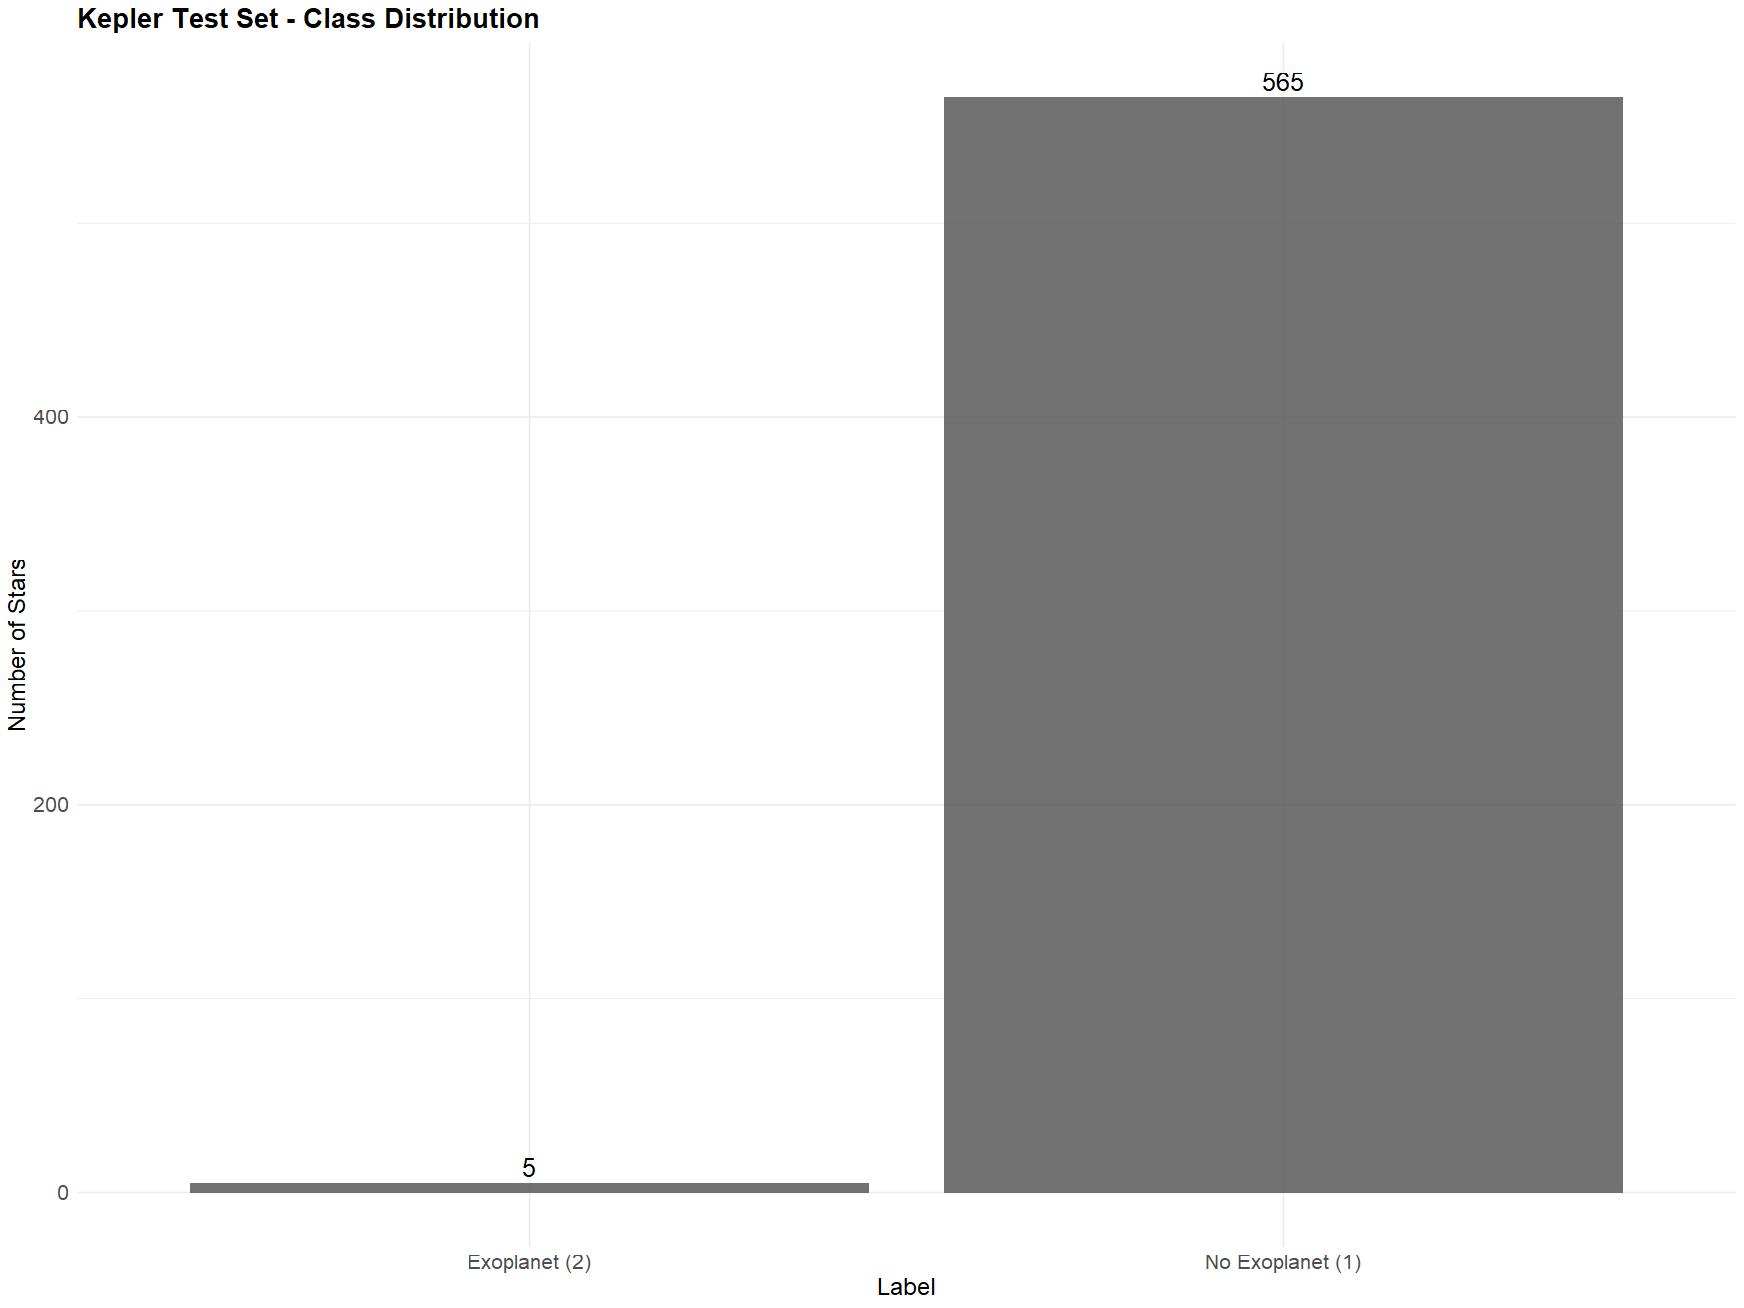

In [3]:
df_dist <- data.frame(
  Label = c("No Exoplanet (1)", "Exoplanet (2)"),
  Count = as.vector(table(exoTest$LABEL))
)
p_dist <- ggplot(df_dist, aes(x = Label, y = Count)) +
  geom_col(alpha = 0.85) +
  geom_text(aes(label = Count), vjust = -0.3, size = 6) +
  labs(
    title = "Kepler Test Set - Class Distribution",
    x = "Label", y = "Number of Stars"
  ) +
  theme_minimal() +
  theme(
  plot.title = element_text(size = 18, face = "bold"),
  axis.title = element_text(size = 16),
  axis.text.x = element_text(size = 14),
  axis.text.y = element_text(size = 14)
)
print(p_dist)

### **3) Select Target Stars and Convert to Time Series**

In a matched case-control design, I chose two confirmed exoplanet hosts (LABEL = 2) and two non-hosting controls (LABEL = 1). Each light curve is converted to an R time series object, and flux values are stored so every downstream figure traces back to a specific dataset row.

In [4]:
with_exo <- which(exoTest$LABEL == 2)
no_exo <- which(exoTest$LABEL == 1)

# Two with exoplanets, two without
star_ids <- c(with_exo[1:2], no_exo[1:2])
cat("Selected star rows:", star_ids, "\n")

stars <- setNames(
  lapply(star_ids, function(i) ts(as.numeric(exoTest[i, flux_cols]))),
  paste0("\nStar rows ", star_ids)
)

# Validate each series before modeling
for (nm in names(stars)) {
  s <- stars[[nm]]
  stopifnot(length(s) == length(flux_cols), all(is.finite(s)))
  cat(nm, "| length:", length(s),
      "| mean flux:", round(mean(s), 2),
      "| sd:", round(sd(s), 2), "\n")
}

Selected star rows: 1 2 6 7 

Star rows 1 | length: 3197 | mean flux: 0.73 | sd: 29.82 

Star rows 2 | length: 3197 | mean flux: 95.41 | sd: 1645.02 

Star rows 6 | length: 3197 | mean flux: 0.58 | sd: 7.45 

Star rows 7 | length: 3197 | mean flux: 5.96 | sd: 54.07 


[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **4) Define Analysis Functions**

Two complementary pipelines are applied to each light curve:

| Pipeline | Method | What it captures |
|----------|--------|------------------|
| **A. ARIMA** | Rolling-mean detrending, log transform, ADF/KPSS stationarity testing, auto.arima, Ljung-Box diagnostics | Stochastic autocorrelation structure and forecast uncertainty |
| **B. Fourier** | Spectral period estimation, AIC-selected harmonics, harmonic regression on scaled detrended flux | Long-period deterministic oscillations (stellar variability) |

##### **Design decisions I want to flag honestly:**

- **Detrending trade-off:** a 25-point rolling mean partially absorbs short transits, so dip detection runs on the *raw* flux while ARIMA operates on detrended log-flux. The two analyses deliberately see different versions of the signal.

- **Robust dip threshold:** I use median−4.5·MAD rather than the classic mean−3·SD, because the deep negative outliers of genuine transits inflate the SD and push the threshold away from the very events being hunted.

- **Ljung-Box correction:** residual diagnostics adjust degrees of freedom for the fitted ARMA orders, avoiding the anticonservative p-values that raw-residual Box tests produce.

In [5]:
# ---------- A.0 Robust local dip detection ----------
detect_dips_rolling <- function(flux, window = 151, nsigma = 4, min_run = 3) {
  flux <- as.numeric(flux)

  # Local robust baseline: rolling median
  base <- zoo::rollmedian(flux, k = window, fill = "extend")
  resid <- flux - base
  qlo <- quantile(resid, 0.01, na.rm = TRUE)
  qhi <- quantile(resid, 0.99, na.rm = TRUE)
  resid_core <- pmin(pmax(resid, qlo), qhi)
  scale_val <- 1.4826 * mad(resid_core, na.rm = TRUE)
  thresh <- -nsigma * scale_val

  # Points far below their LOCAL median
  dips <- which(resid < thresh)
  if (length(dips) == 0) {
    return(list(indices = integer(0),
                events = data.frame(start = integer(), end = integer(),
                                    mid = integer(), depth = numeric()),
                resid = resid, thresh = thresh))
  }


  segments <- split(dips, cumsum(c(TRUE, diff(dips) > 1)))
  keep <- segments[vapply(segments, length, integer(1)) >= min_run]
  
  if (length(keep) == 0) {
    return(list(indices = integer(0),
                events = data.frame(start = integer(), end = integer(),
                                    mid = integer(), depth = numeric()),
                resid = resid, thresh = thresh))
  }

  # Keep events as spans with depth
  events <- do.call(rbind, lapply(keep, function(seg) {
    data.frame(start = min(seg), end = max(seg),
               mid = round(mean(seg)),
              depth = min(resid[seg]))
  }))
  list(indices = unlist(keep, use.names = FALSE),
       events = events, resid = resid, thresh = thresh)
}

# ---------- A. ARIMA Analysis ----------
analyze_star_arima <- function(ts_data, star_name, has_exoplanet, row_id) {
  cat("\n=============================================================\n")
  cat("ARIMA Analysis for", star_name, " ( Row", row_id, ")\n")
  cat("Exoplanet Present:", has_exoplanet, "\n")
  cat("=============================================================\n")

  # --- 1. Raw light curve ---
  p_raw <- autoplot(ts_data) +
    ggtitle(paste(star_name, "- Original Light Curve")) +
    xlab("Observational Index") +
    ylab("Flux") +
    theme_minimal(base_size = 16)
  print(p_raw)

  # --- 2. Detrend and stabilize ---
  trend <- zoo::rollmean(ts_data, k = 25, fill = NA)
  detrended <- na.omit(ts_data - trend)
  if (any(detrended <= 0)) detrended <- detrended - min(detrended) + 1
  log_ts <- log(detrended)

  # --- 3. Stationary testing (both tests must agree) ---
  adf_p <- adfTest(log_ts, type = "ct")@test$p.value
  kpss_p <- kpss.test(log_ts, null = "Level")$p.value
  cat(sprintf("ADF p-value: %.4f | KPSS p-value: %.4f\n", adf_p, kpss_p))
  log_final <- if (!(adf_p < 0.05 && kpss_p > 0.05)) diff(log_ts) else log_ts
  cat("Differencing applied:", (adf_p < 0.05 && kpss_p > 0.05) == FALSE, "\n")

  # --- 4. Correlation structure guides expectations before auto.arima ---
  Acf(log_final, main = paste(star_name, "- ACF"))
  Pacf(log_final, main = paste(star_name, "- PACF"))

  # --- 5. Fit, coefficient test, diagnostics with corrected Ljung-Box df ---
  fit <- auto.arima(log_final)
  order <- arimaorder(fit)
  fitdf <- sum(order[c("p", "q")])
  cat("Select ARIMA:", paste(unlist(order[c("p", "d", "q")]), collapse = ","),"\n")
  print(coeftest(fit))
  
  p_res <- autoplot(fit$residuals) +
    ggtitle(paste(star_name, "- Residuals")) +
    xlab("Time") +
    ylab("Residual") +
    theme_minimal(base_size = 16)
  print(p_res)

  Acf(fit$residuals, main = paste(star_name, "- Residual ACF"))
  lb_p <- Box.test(fit$residuals, lag = 20, type = "Ljung", fitdf = fitdf)$p.value
  cat(sprintf("Ljung-Box p-value (lag 20, fitdf=%d): %.4f\n", fitdf, lb_p))

  # --- 6. Forecast with honest uncertainty band ---
  fc <- forecast(fit, h = 50)
  print(autoplot(fc) + ggtitle(paste(star_name, "- Forecasted Flux")))

  # --- 7. Robust LOCAL dip detection on RAW flux ---
  dip_res <- detect_dips_rolling(as.numeric(ts_data), window = 301, nsigma = 3, min_run = 2)
  cat("Flagged points:", length(dip_res$indices), "| Events:", nrow(dip_res$events), "\n")

  
  # Edge guard: events beginning/ending within half of detection window of
  # the series boundary have edge-extended baselines and are unreliable.
  N <- length(as.numeric(ts_data))
  edge_half <- 151
  dip_res$events <- subset(dip_res$events, start > edge_half & end < (N - edge_half))
  cat("Events after edge guard:", nrow(dip_res$events), "\n")

  # Relative flux (normalized to median) for readable, comparable plots
  flux_num <- as.numeric(ts_data)
  flux_scale <- 1.4826 * mad(flux_num, na.rm = TRUE)
  if (!is.finite(flux_scale) || flux_scale < 1e-9) flux_scale <- sd(flux_num, na.rum = TRUE)
  rel_flux <- flux_num / flux_scale
  
  smooth_disp <- suppressWarnings(zoo::rollmedian(rel_flux, k = 5, fill = "extend"))

  df <- data.frame(time = seq_along(ts_data), 
                   resid = as.numeric(dip_res$resid),
                   rel = rel_flux,
                   smooth = smooth_disp)

  # Y-limits that include the threshold and deepest point
  y_lo <- min(c(df$resid, dip_res$thresh), na.rm = TRUE) * 1.08
  
  p_dip <- ggplot(df, aes(x = time, y = resid)) +
    geom_rect(data = dip_res$events, inherit.aes = FALSE,
              aes(xmin = start, xmax = end, ymin = -Inf, ymax = Inf),
              alpha = 0.15, fill = "red") +
    geom_line(color = "grey65", linewidth = 0.25) +
    geom_hline(yintercept = dip_res$thresh, linetype = "dashed", color = "#6d4aff") +
    geom_point(data = dip_res$events, inherit.aes = FALSE,
               aes(x = mid, y = depth), color = "red", size = 3) +
    coord_cartesian(ylim = c(y_lo, quantile(df$resid, 0.98, na.rm = TRUE))) +
    ggtitle(paste(star_name, "- Detected Transits (rolling median + MAD)")) +
    xlab("Time") +
    ylab("Residual flux (local median removed)") +
    theme_minimal(base_size = 16)
  print(p_dip)

  p_ctx <- ggplot(df, aes(x = time, y = rel)) +
    geom_line(color = "grey85", linewidth = 0.3) +
    geom_line(aes(y = smooth), color = "#6d4aff", linewidth = 0.5) +
    geom_rect(data = dip_res$events, inherit.aes = FALSE,
              aes(xmin = start, xmax = end, ymin = -Inf, ymax = Inf),
              alpha = 0.15, fill = "red") +
    coord_cartesian(ylim = quantile(df$smooth, c(0.001, 0.999), na.rm = TRUE)) +
    ggtitle(paste(star_name, "- Relative Flux (5-point median smoothed, event locations)")) +
    xlab("Time") + ylab("Relative Flux") +
    theme_minimal(base_size = 16)
  print(p_ctx)

  invisible(list(fit = fit, dip_count = nrow(dip_res$events), ljung_box_p = lb_p))
}

#### **4.1) Fourier Harmonic Regression - Helper Functions**

I estimate the dominant period from a smoothed spectrum restricted to a plausible orbital window, then select the number of harmonics K by minimizing AIC across candidate fits — returning the full AIC vector so the model-selection curve can be plotted rather than only asserted.

In [6]:
estimate_period <- function(x, min_period = 100, max_period = 5000) {
  sp <- spectrum(x, plot = FALSE, spans = c(5, 5))
  if (length(sp$freq) == 0) return(NA_real_)
  periods <- 1 / sp$freq
  valid <- which(periods >= min_period & periods <= max_period)
  if (length(valid) == 0) return(NA_real_)
  best <- valid[which.max(sp$spec[valid])]
  periods[best]
}

choose_K <- function(ts_obj, Kmax = 6) {
  aic_vals <- vapply(seq_len(Kmax), function(kk) {
    fr <- as.data.frame(forecast::fourier(ts_obj, K = kk))
    names(fr) <- paste0("h", seq_along(fr))
    fr$y <- as.numeric(ts_obj)
    AIC(lm(y ~., data = fr))
  }, numeric(1))
  cat("AIC values by K:", round(aic_vals, 2), "\n")
  list(best_K = which.min(aic_vals), aic = aic_vals)
}

#### **4.2) Fourier Analysis - Main Function**

At the estimated frequency, the detrended, standardized flux is represented as a sum of Fourier harmonic terms. The single canonical implementation is the improved version with per-star diagnostics, residual spectra, and returned metadata, which supersedes the earlier draft.

In [7]:
# ---------- B. Fourier Analysis ----------
analyze_star_fourier <- function(ts_data, star_name, row_id, 
                                 has_exoplanet = "Unknown",
                                 roll_k = 25, kmax = 6) {
  cat("\n=====================================================\n")
  cat("Fourier Analysis of", star_name, " ( Row", row_id, ")\n")
  cat("Exoplanet Present:", has_exoplanet, "\n")
  cat("=====================================================\n")

  # --- Detrend using moving average ---
  trend <- zoo::rollmean(ts_data, k = roll_k, fill = "extend")
  detrended <- ts_data - trend
  if (length(detrended) < 50) stop("Too few points after detrending.")

  # Scale for numerical stability
  detrended_scaled <- scale(detrended)
  s_mean <- attr(detrended_scaled, "scaled:center")
  s_sd <- attr(detrended_scaled, "scaled:scale")

  # --- Estimate period and harmonics ---
  period_est <- estimate_period(detrended_scaled)
  if (is.na(period_est) || !is.finite(period_est)) period_est <- 200
  m <- max(2, round(period_est))
  x_ts <- ts(as.numeric(detrended_scaled), frequency = m)
  k_res <- choose_K(x_ts, Kmax = kmax)
  K <- k_res$best_K
  cat("Estimated Period:", round(period_est, 2),
      " | Chosen Harmonics (K):", K, "\n")

  # --- Fit Fourier regression ---
  fr <- as.data.frame(forecast::fourier(x_ts, K = K))
  names(fr) <- paste0("h", seq_along(fr))
  fr$y <- as.numeric(x_ts)
  fit_fourier <- lm(y ~ ., data = fr)
  fitted_vals <- fitted(fit_fourier) * s_sd + s_mean

  # --- Observed vs. fitted ---
  df_fit <- data.frame(
    Time = seq_along(detrended),
    Detrended = as.numeric(detrended),
    Fitted = as.numeric(fitted_vals)
  )

  p_fit <- ggplot(df_fit, aes(x = Time)) +
    geom_line(aes(y = Detrended), color = "grey60") +
    geom_line(aes(y = Fitted), color = "#6d4aff", linewidth = 1) +
    ggtitle(paste(star_name, "- Fourier Harmonic Fit (K = ", K,")")) +
    xlab("Time") + ylab("Flux (Detrended)") +
    theme_minimal(base_size = 16)
  print(p_fit)

  # --- AIC vs. K model selection curve ---
  df_aic <- data.frame(K = seq_len(kmax), AIC = k_res$aic)
  p_aic <- ggplot(df_aic, aes(x = K, y = AIC)) +
    geom_line() + geom_point() +
    ggtitle(paste(star_name, "- AIC vs. Number of Harmonics")) +
    xlab("Number of Harmonics (K)") +
    ylab("AIC") +
    theme_minimal(base_size = 16)
  print(p_aic)

  # --- Residuals ---
  df_fit$Residuals <- residuals(fit_fourier)
  p_res <- ggplot(df_fit, aes(x = Time, y = Residuals)) +
    geom_line(color = "darkred") +
    coord_cartesian(ylim = quantile(df_fit$Residuals,
                                    c(0.01, 0.99), na.rm = TRUE)) +
    ggtitle(paste(star_name, "- Fourier Residuals")) +
    xlab("Time") +
    ylab("Residuals") +
    theme_minimal(base_size = 16)
  print(p_res)

  # --- Spectrum of residuals ---
  spectrum(df_fit$Residuals, spans = c(3, 3), log = "yes",
           main = paste(star_name, "- Spectrum of Residuals"))

  invisible(list(fit = fit_fourier, period = period_est, K = K,
                 aic = k_res$aic, df = df_fit))
}

[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **5) Run Analyses**

Both pipelines run for each of the four selected stars, with each star given its own section to keep results isolated and eary to review individually. The functions return their fitted objects and summary metrics, so the comparison table in the next section is assembled from actual run output rather than restated in prose.

In [8]:
results <- list()

#### **5.1) Confirmed Exoplanet Host Stars**


ARIMA Analysis for Star 1  ( Row 1 )
Exoplanet Present: Yes 
ADF p-value: 0.0100 | KPSS p-value: 0.1000
Differencing applied: FALSE 


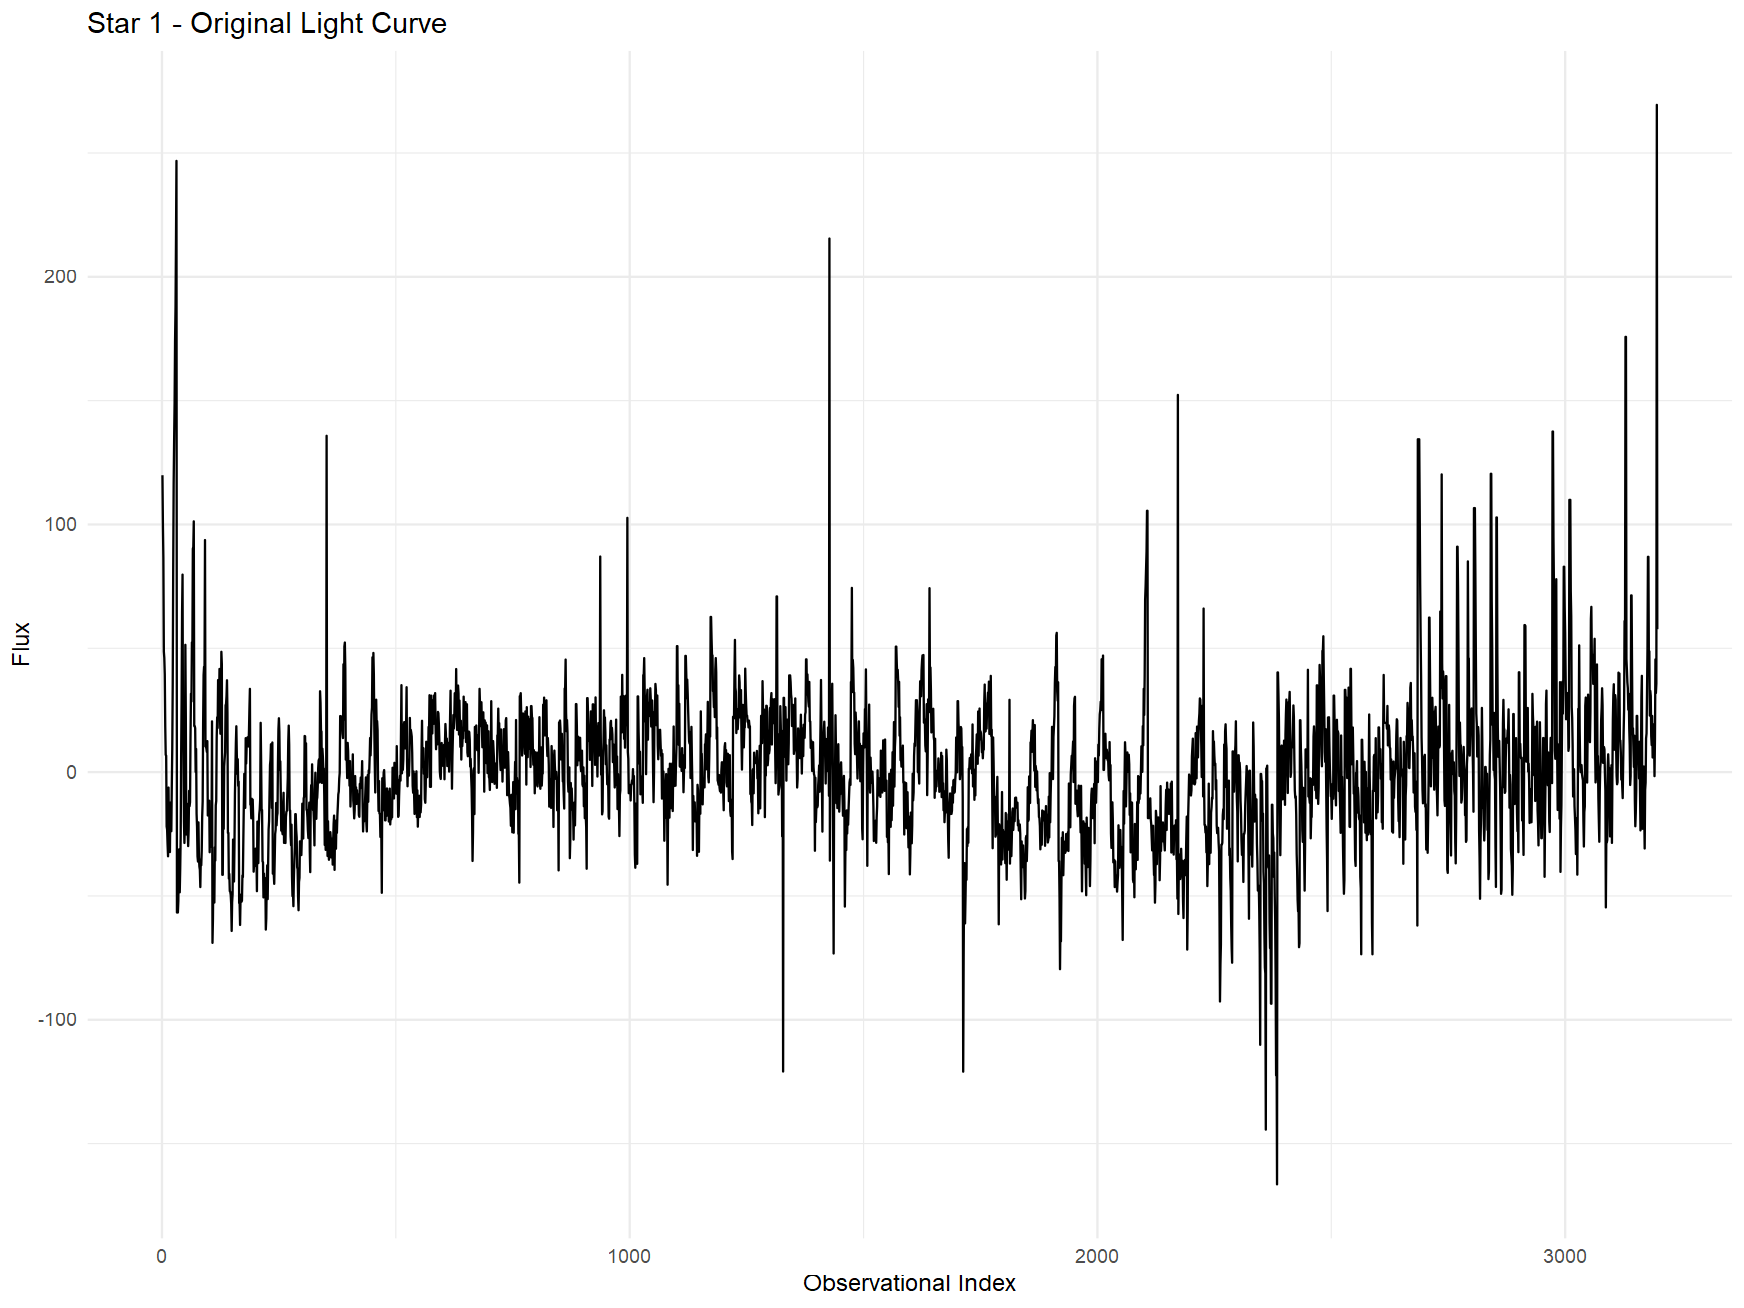

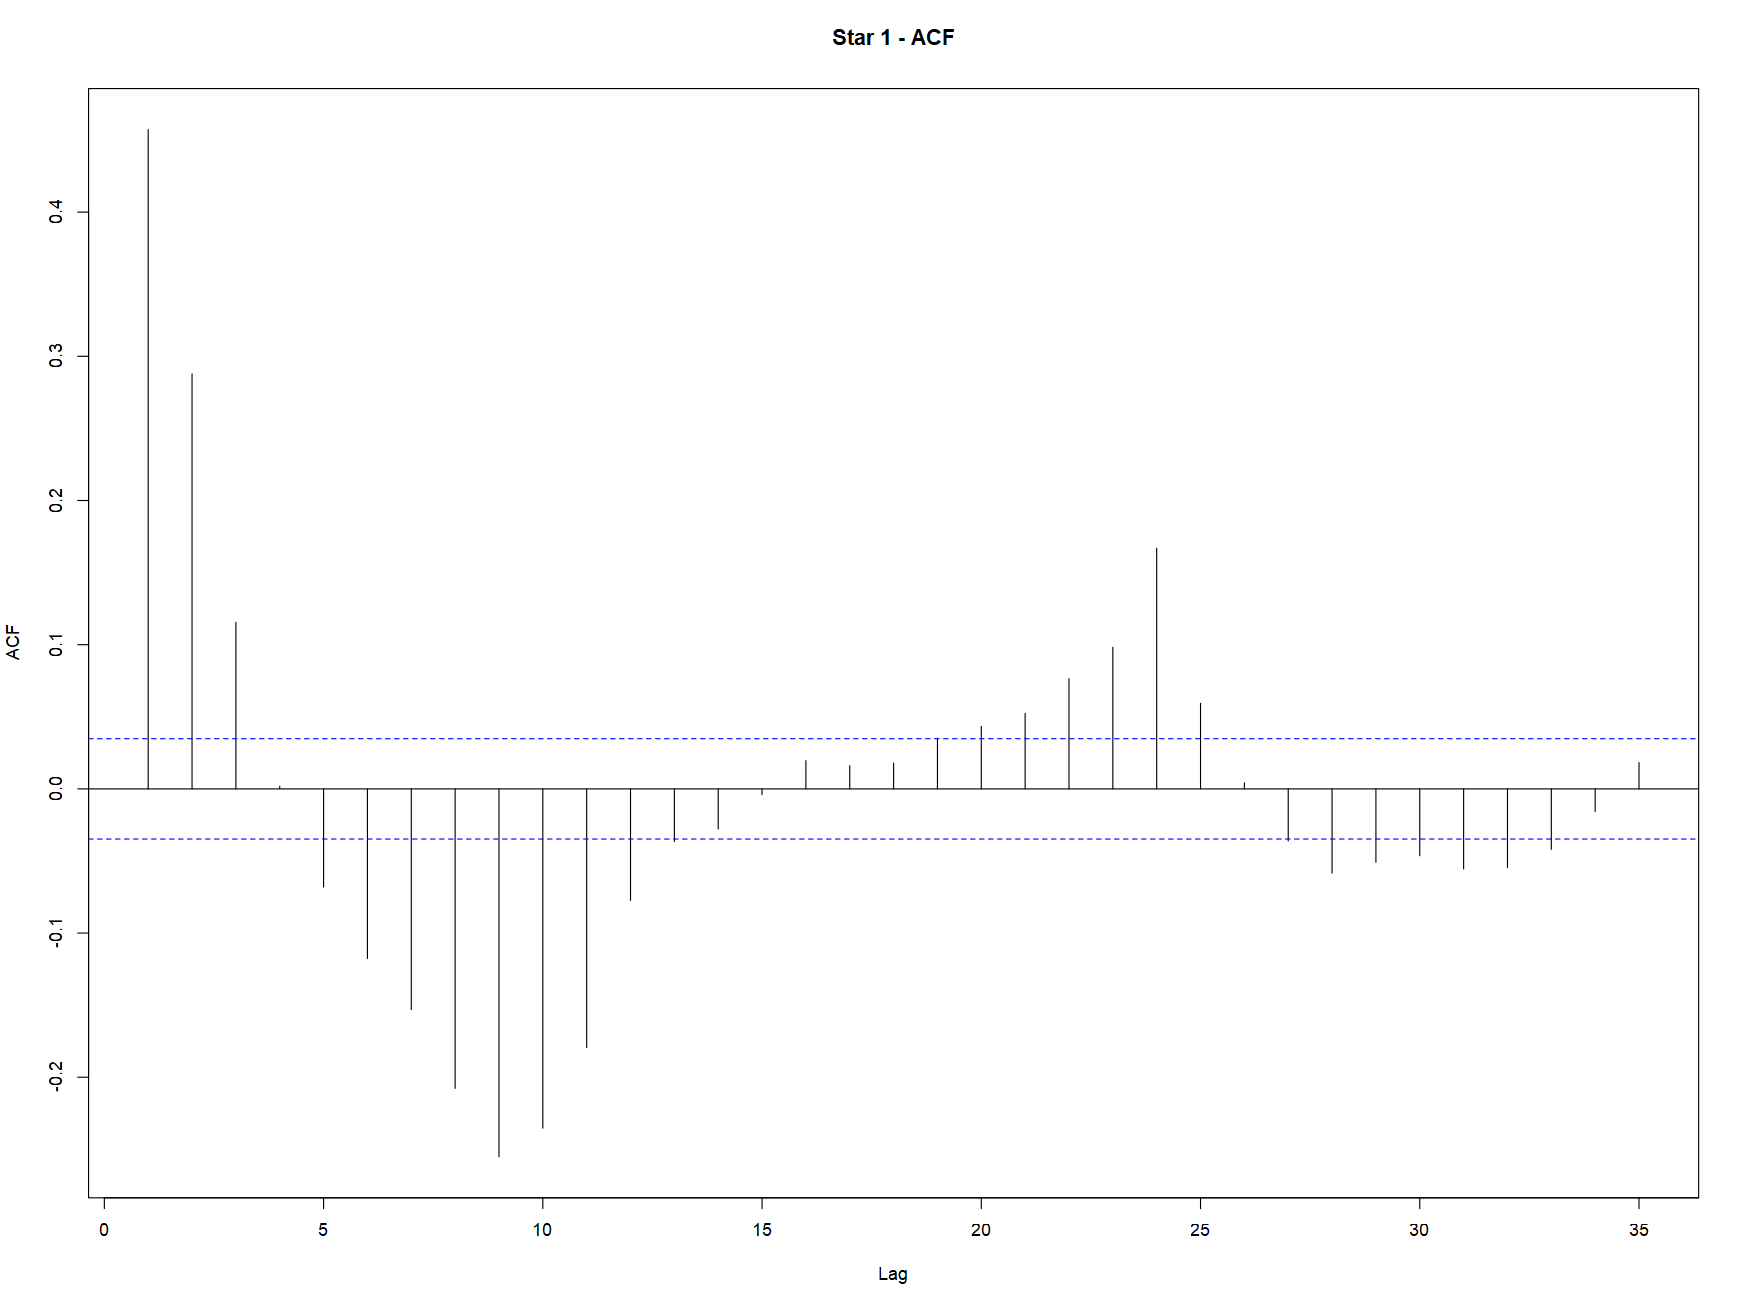

Select ARIMA: 4,0,2 

z test of coefficients:

            Estimate Std. Error   z value  Pr(>|z|)    
ar1        2.0421865  0.0747126   27.3339 < 2.2e-16 ***
ar2       -1.2324596  0.0992213  -12.4213 < 2.2e-16 ***
ar3        0.0640024  0.0426300    1.5013  0.133266    
ar4        0.0796537  0.0272054    2.9279  0.003413 ** 
ma1       -1.6750246  0.0719264  -23.2880 < 2.2e-16 ***
ma2        0.7179690  0.0649465   11.0548 < 2.2e-16 ***
intercept  4.9013043  0.0028055 1747.0537 < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



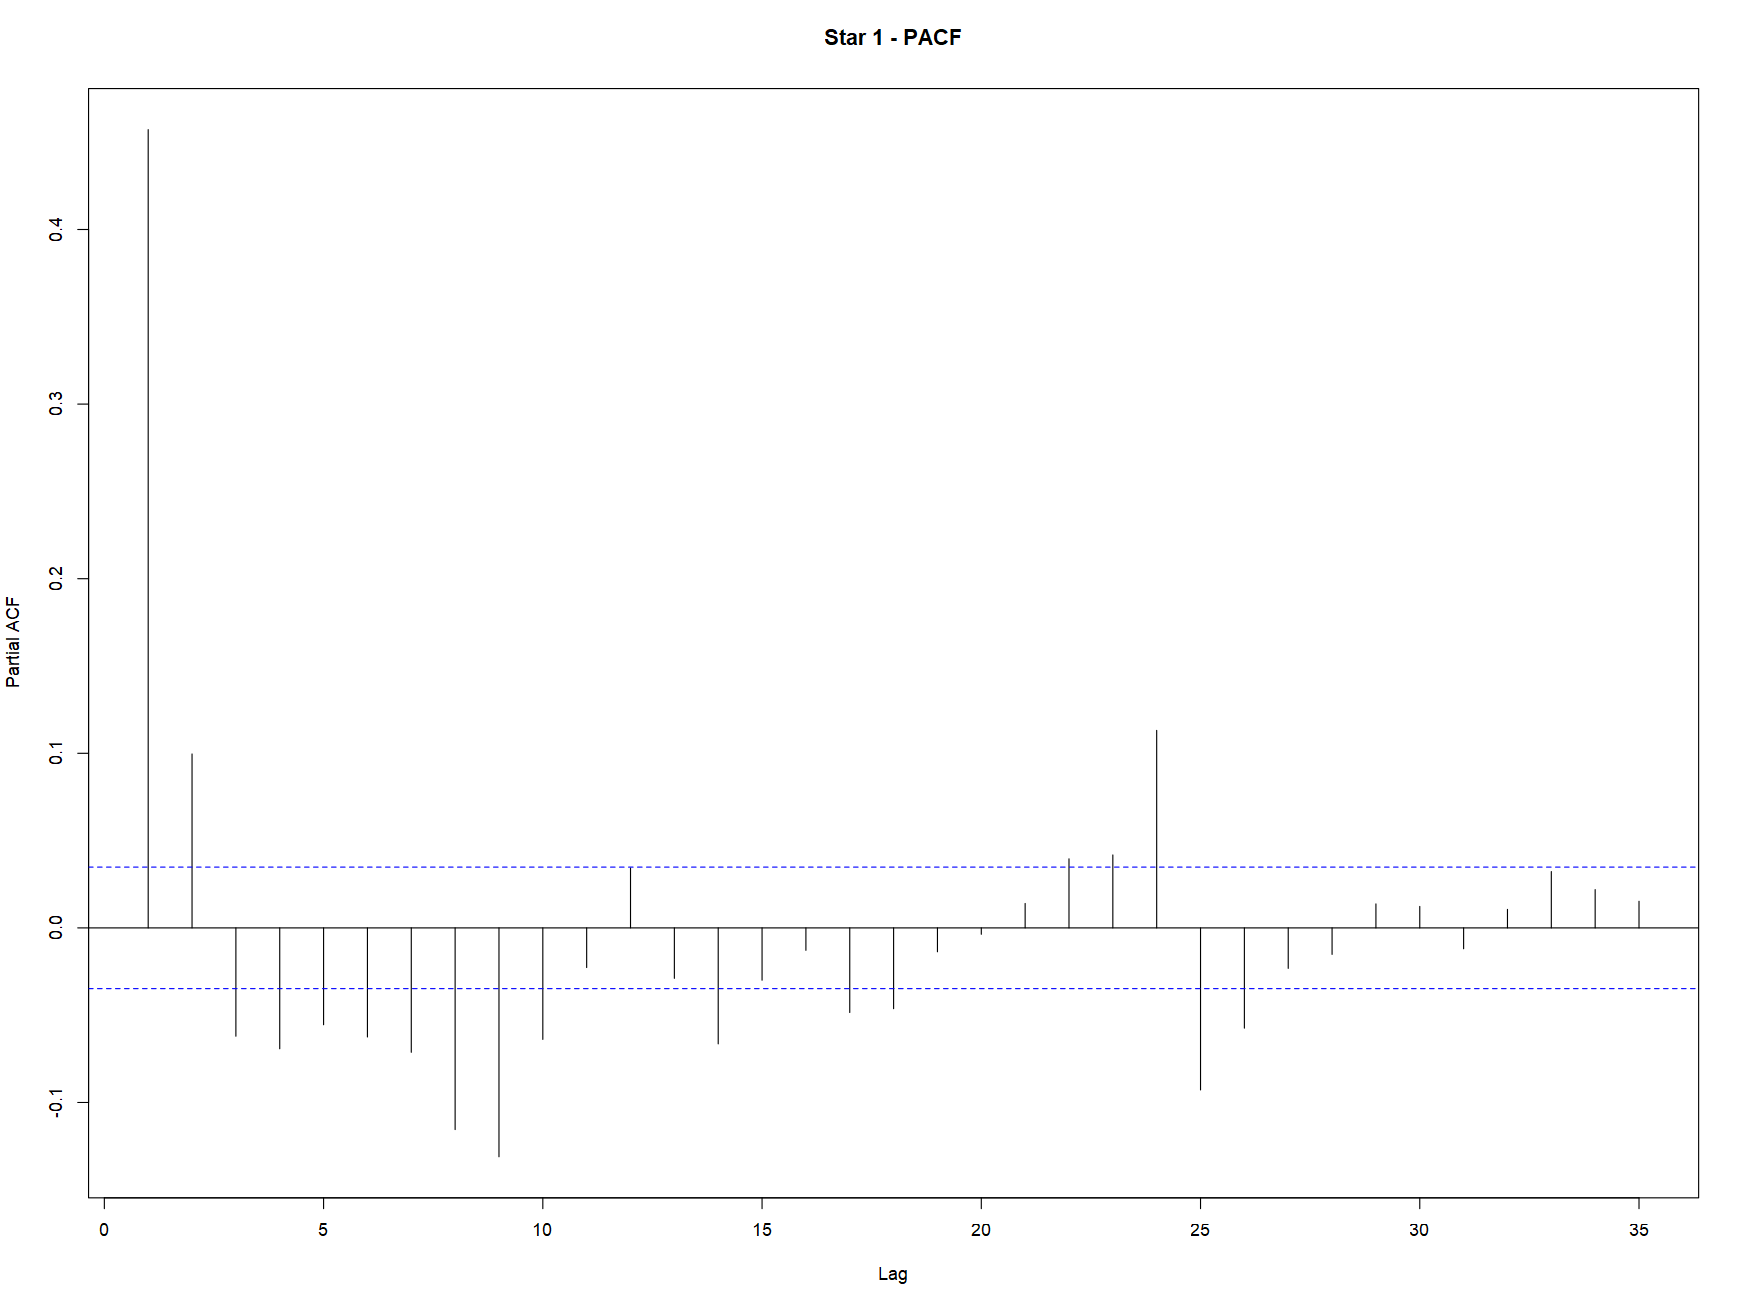

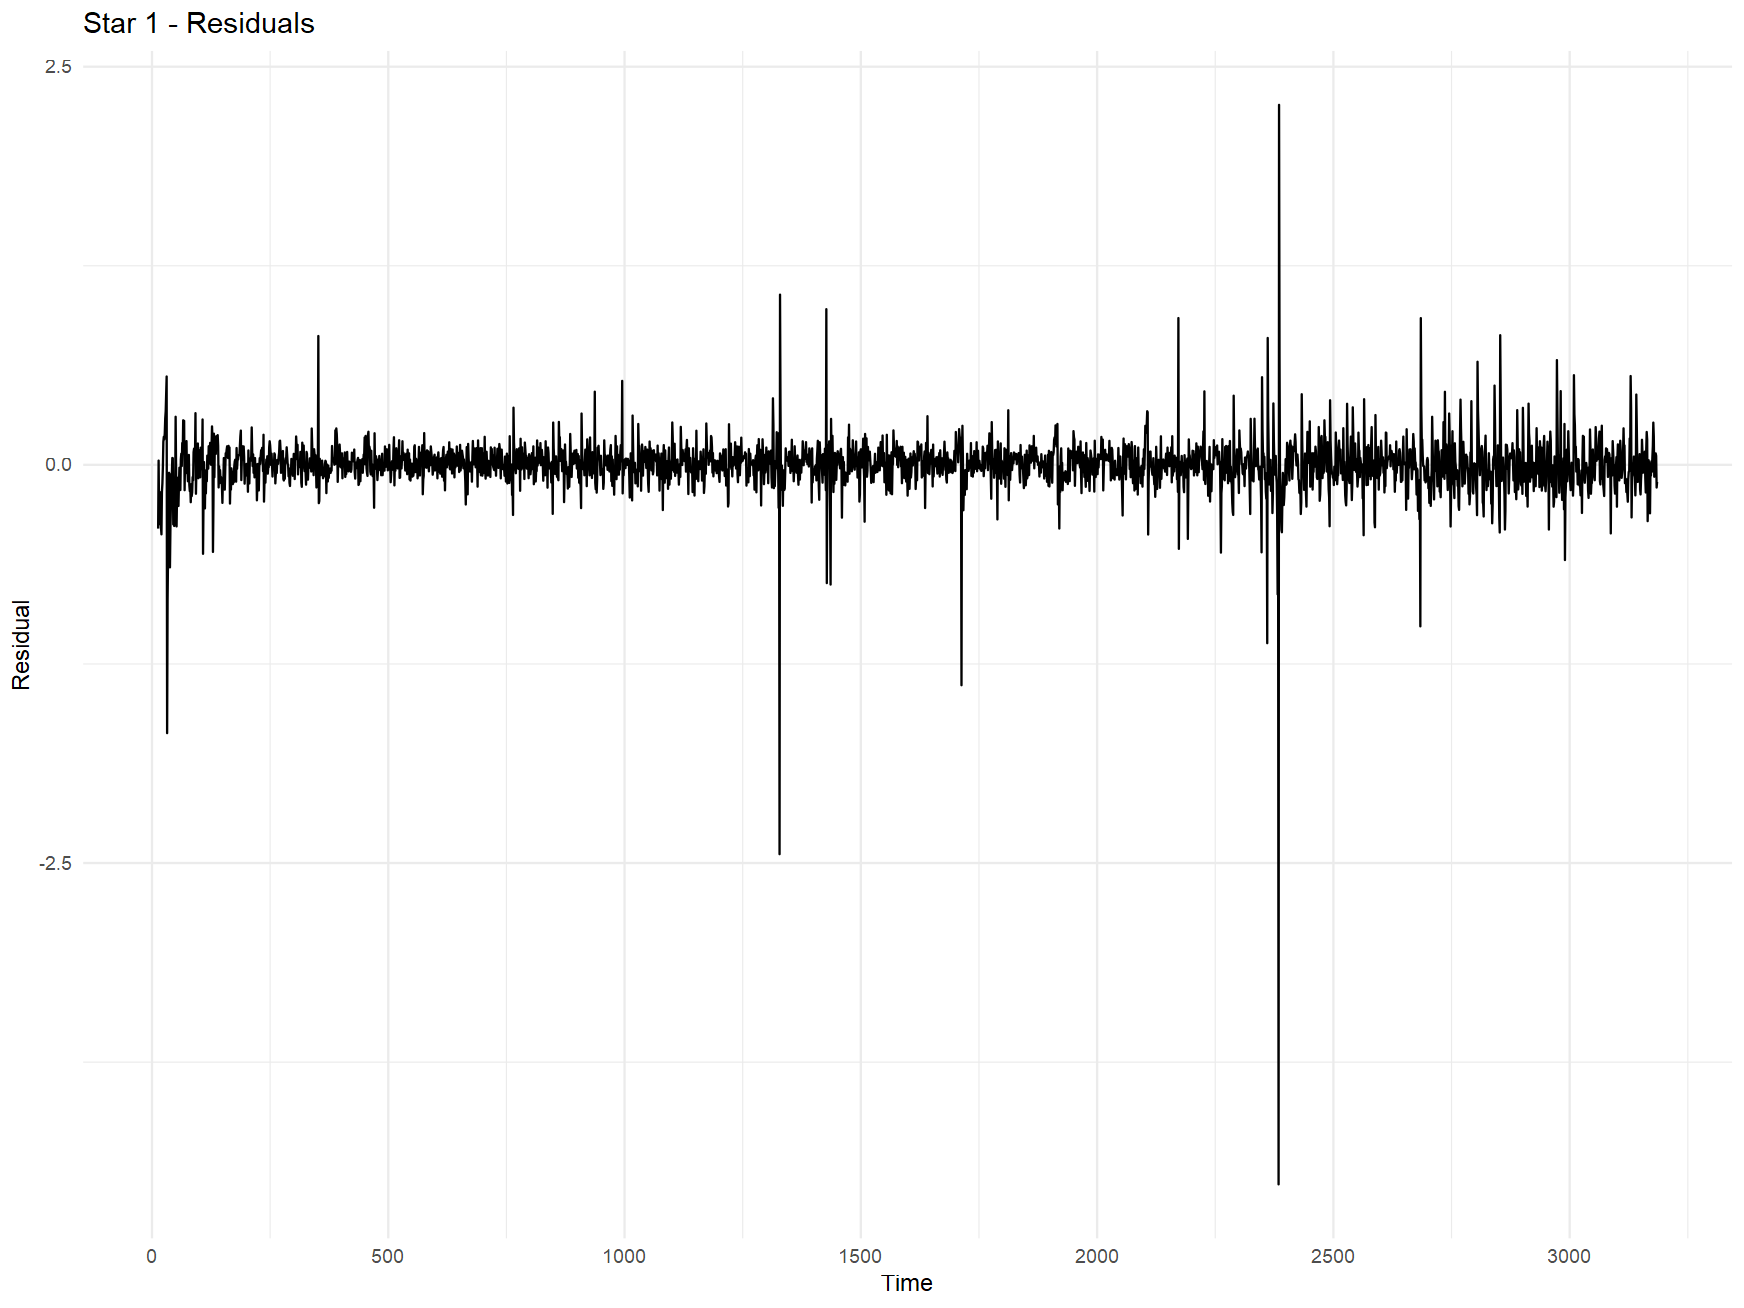

Ljung-Box p-value (lag 20, fitdf=6): 0.0000


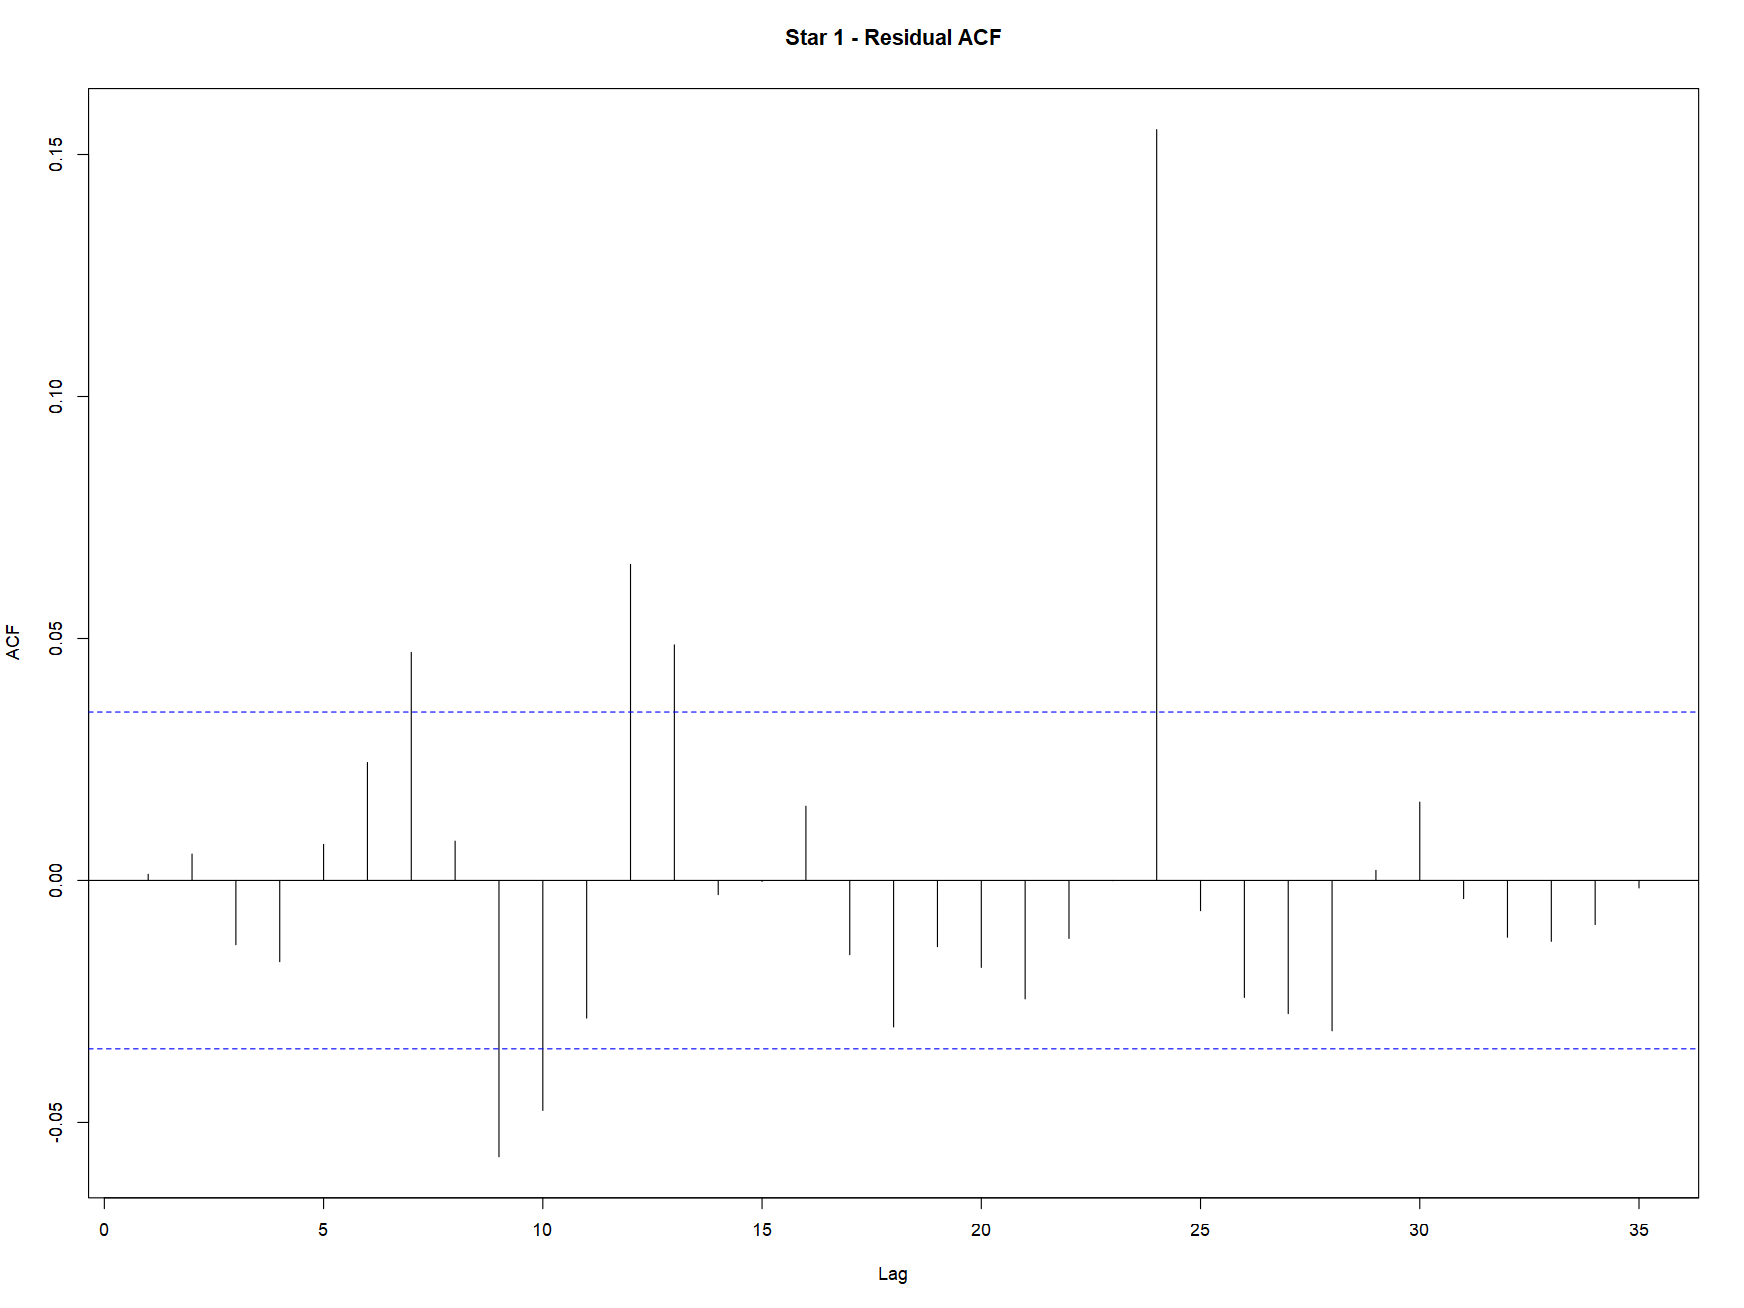

Flagged points: 3 | Events: 1 
Events after edge guard: 1 


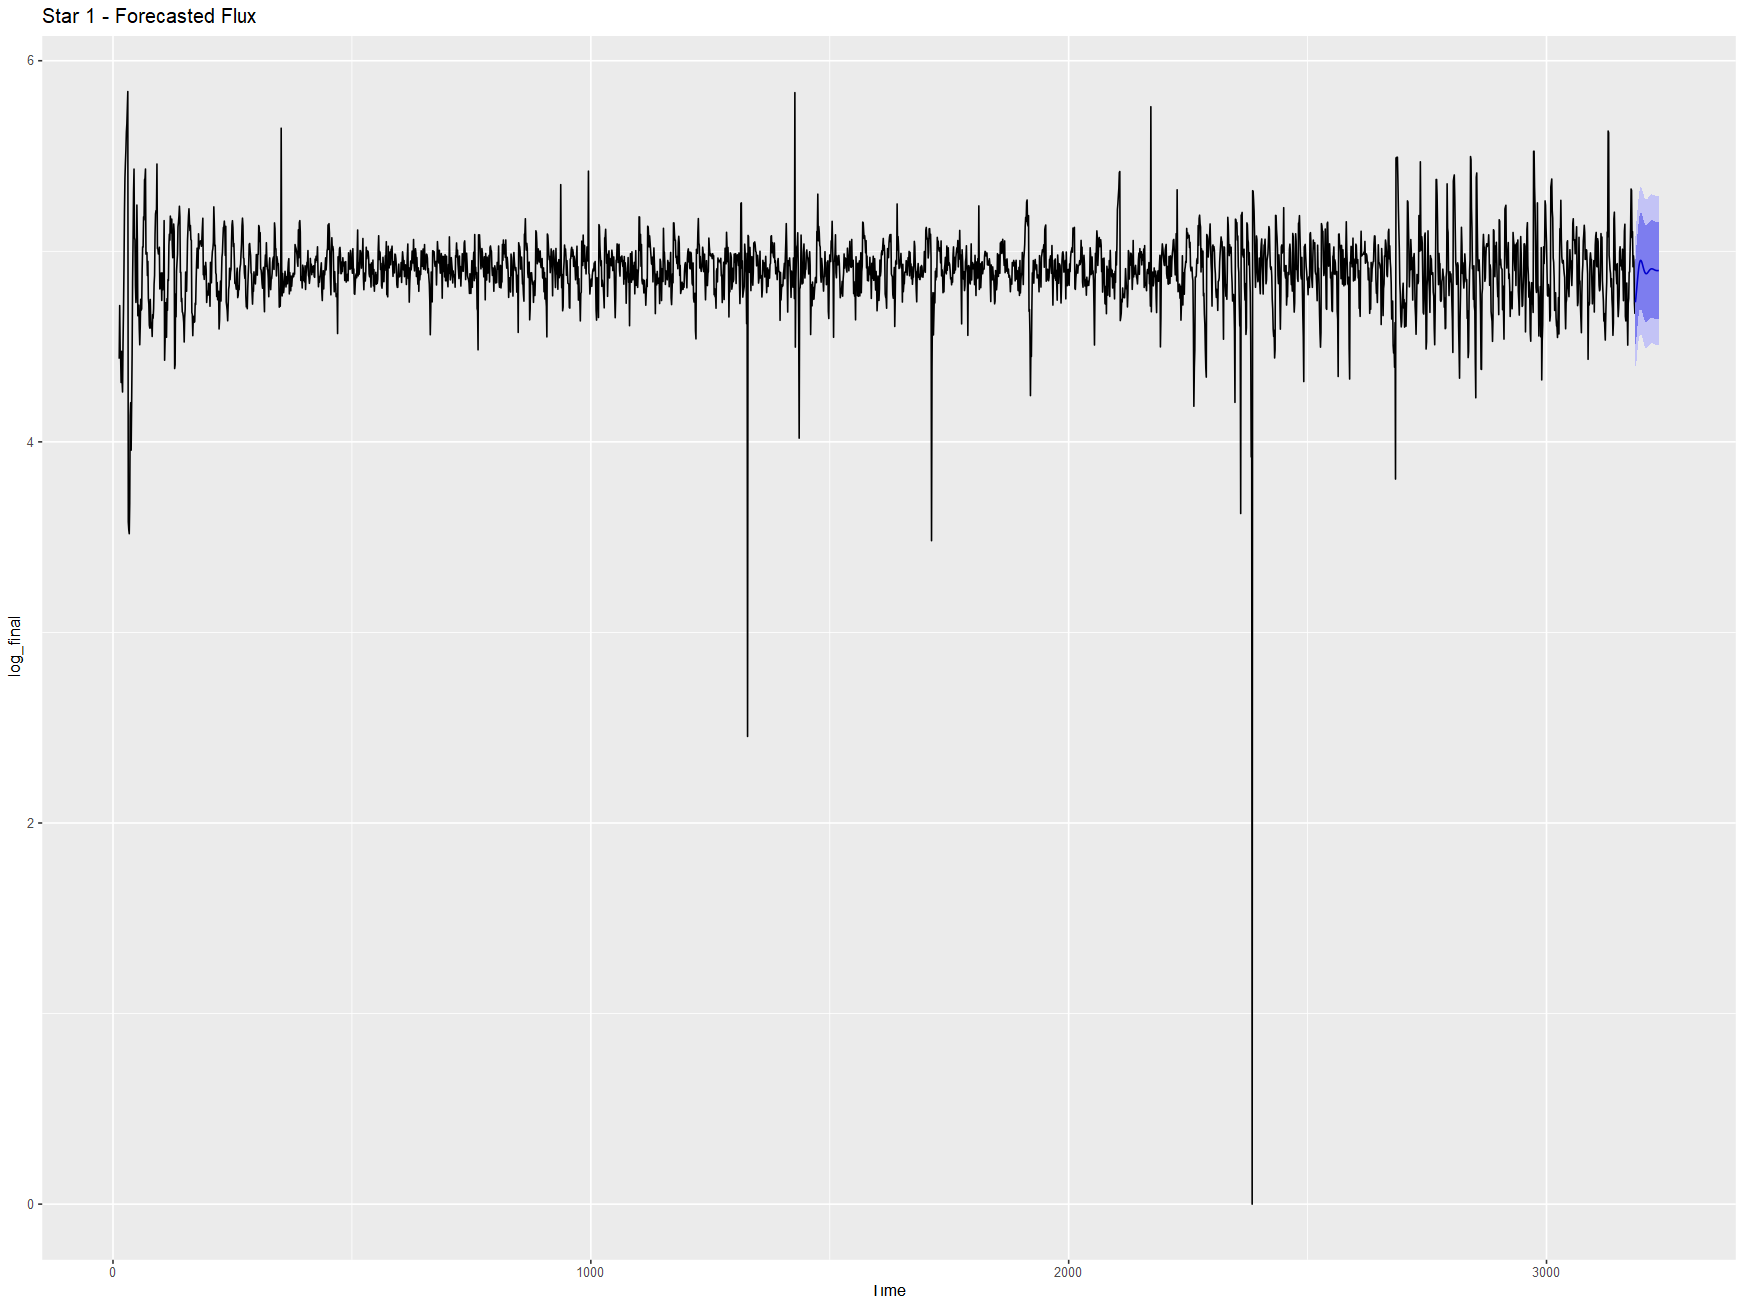

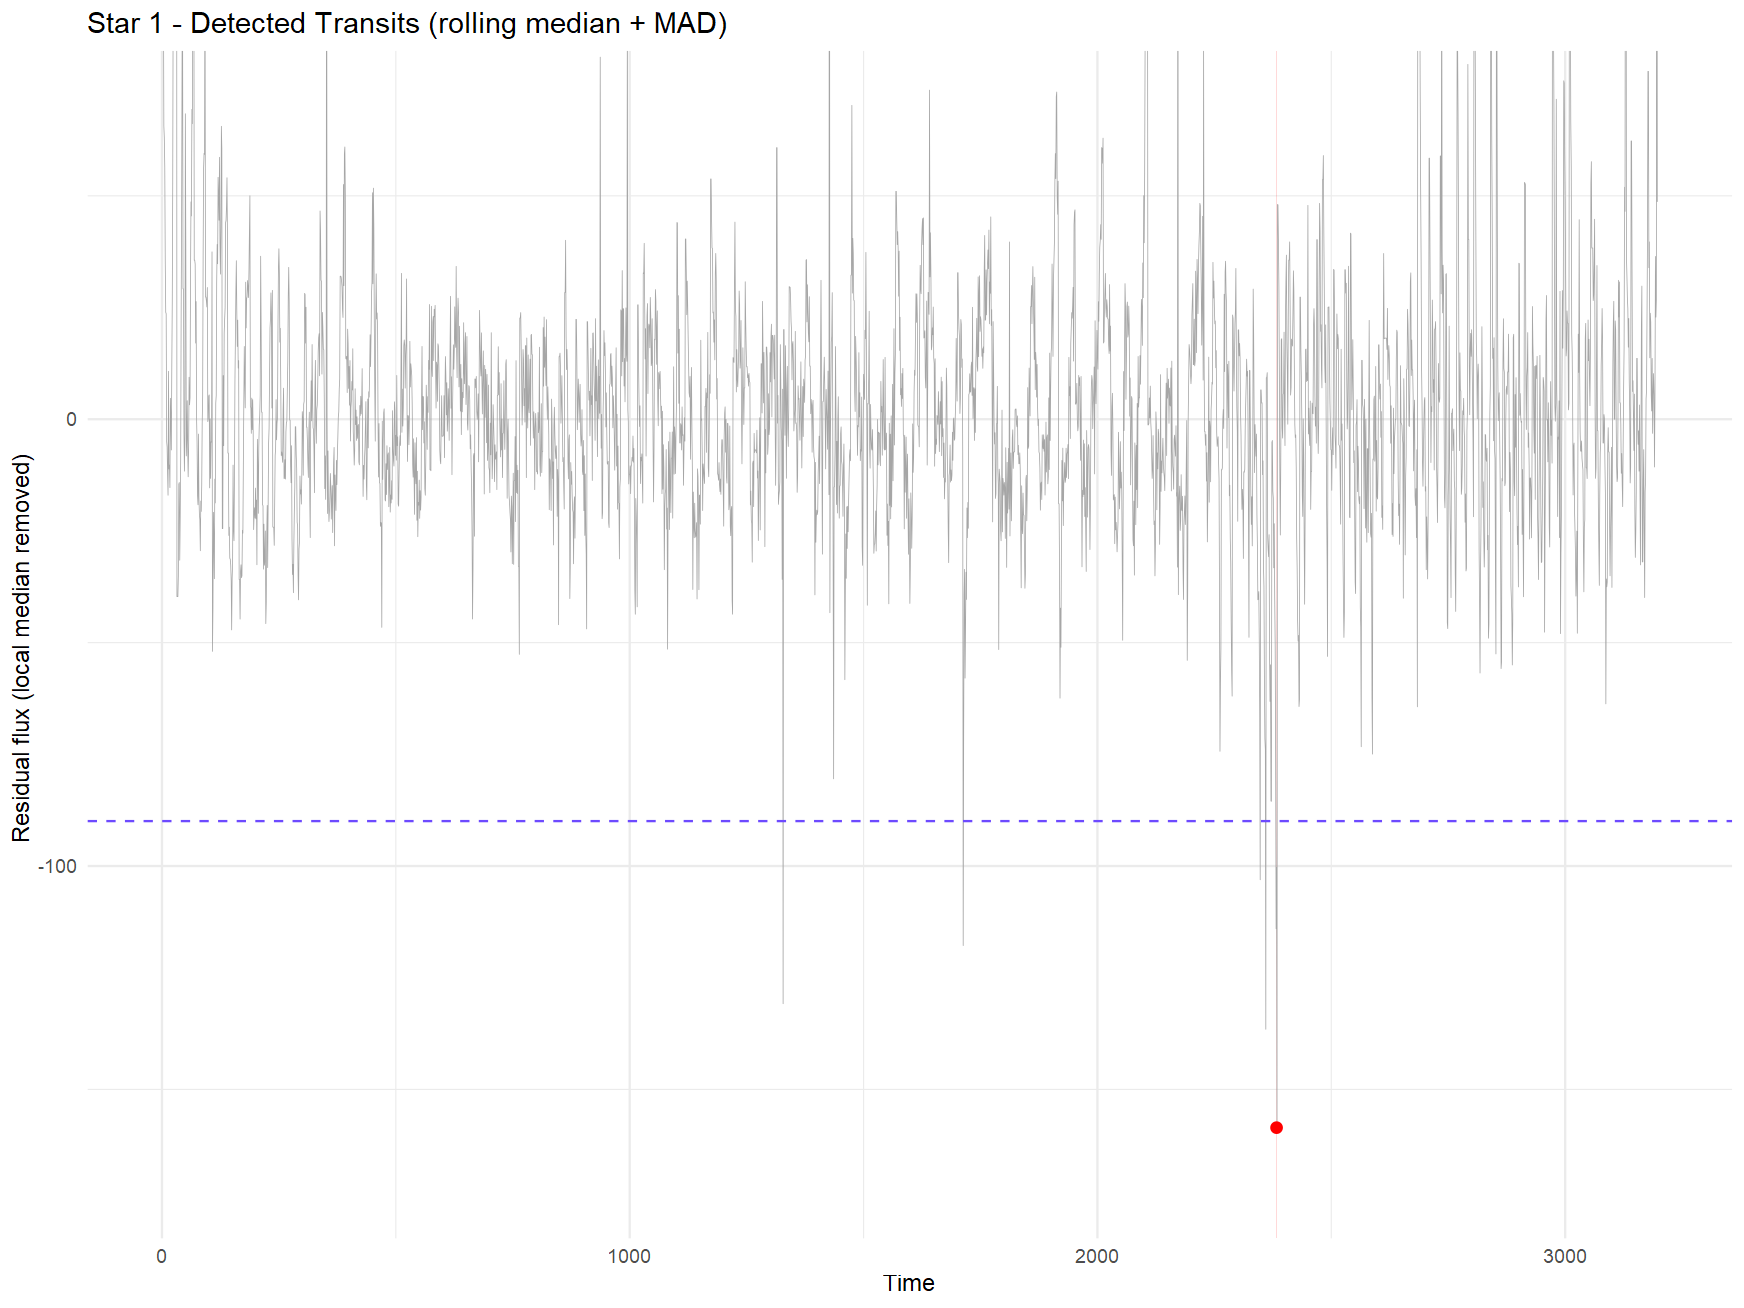


Fourier Analysis of Star 1  ( Row 1 )
Exoplanet Present: Yes 
AIC values by K: 9079.32 9083.27 9082.6 9079.37 9069.14 9067.09 
Estimated Period: 100  | Chosen Harmonics (K): 6 


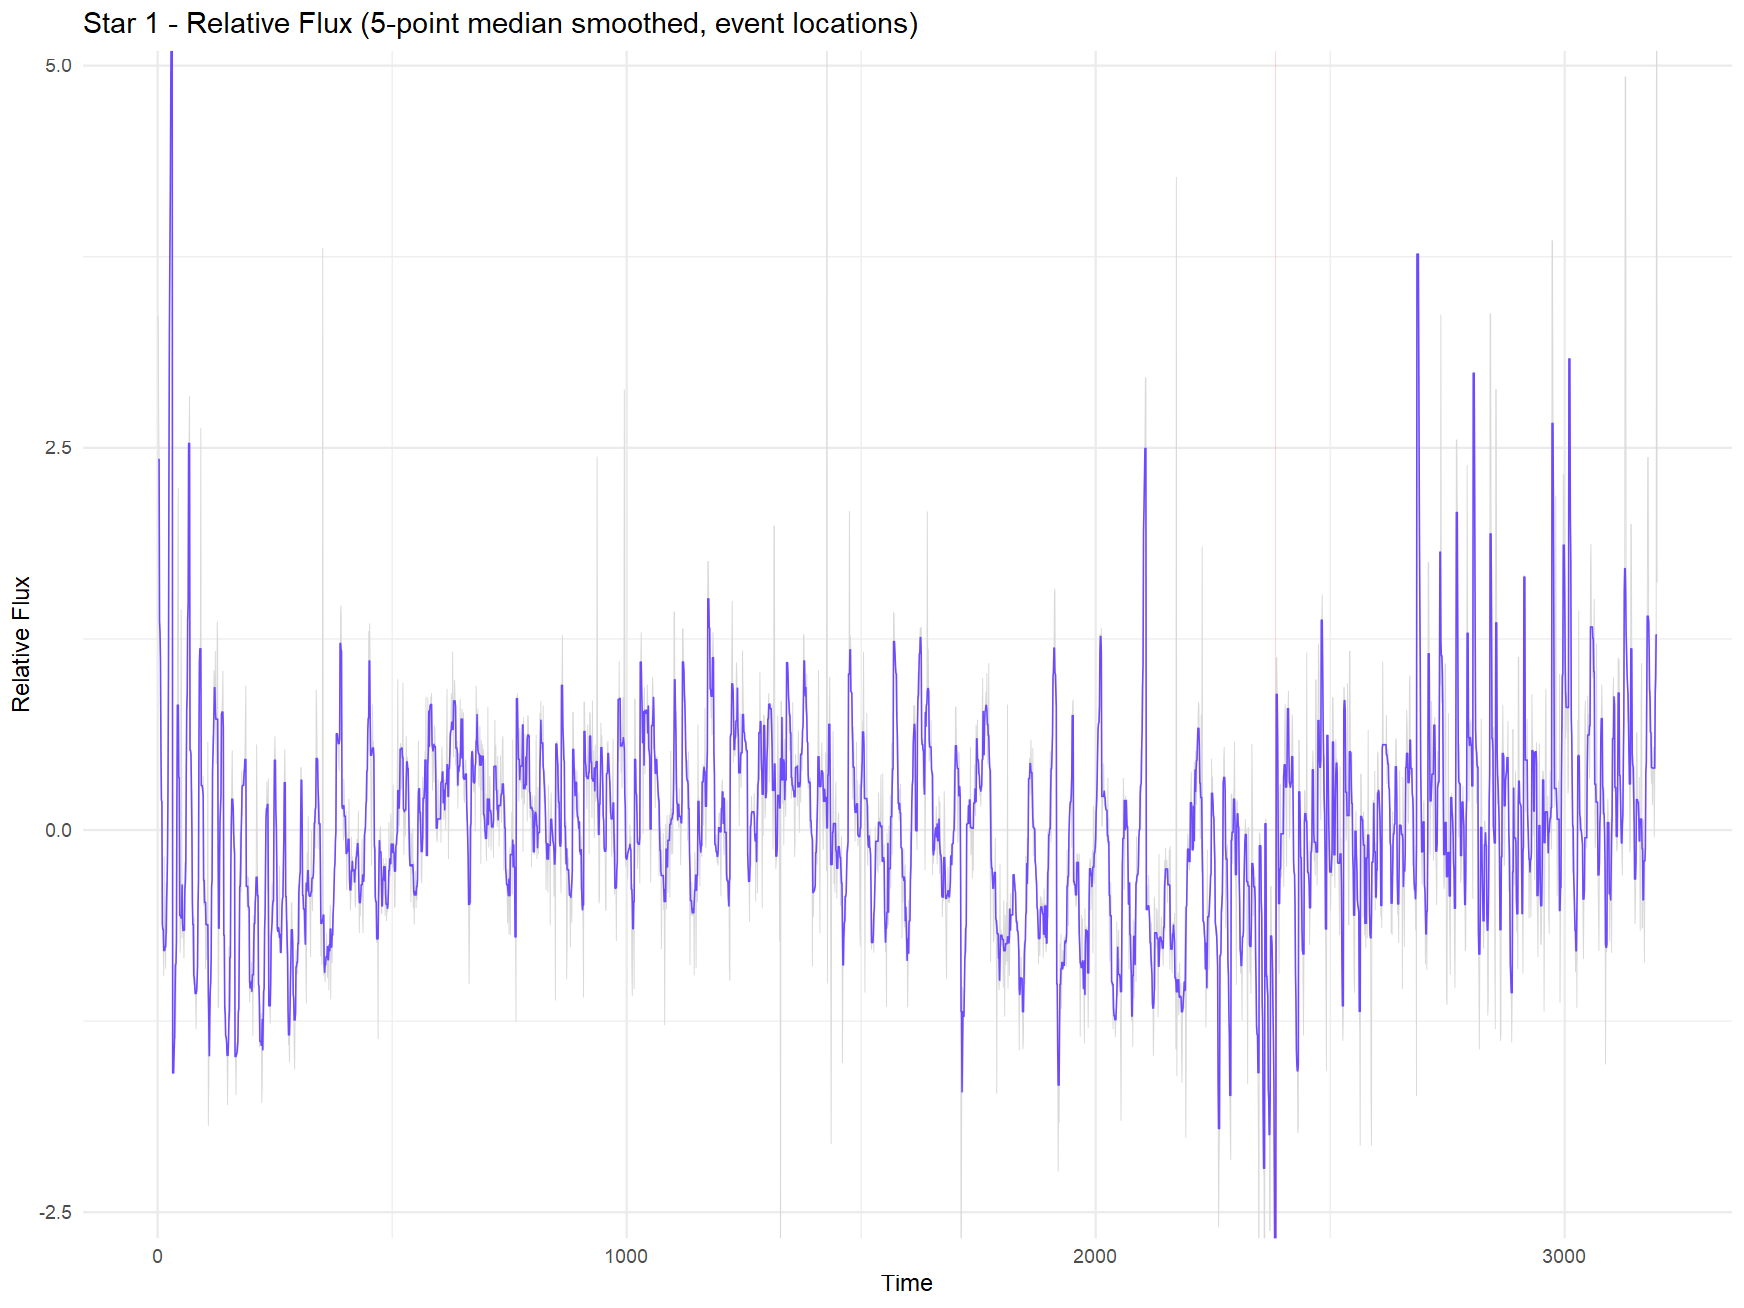

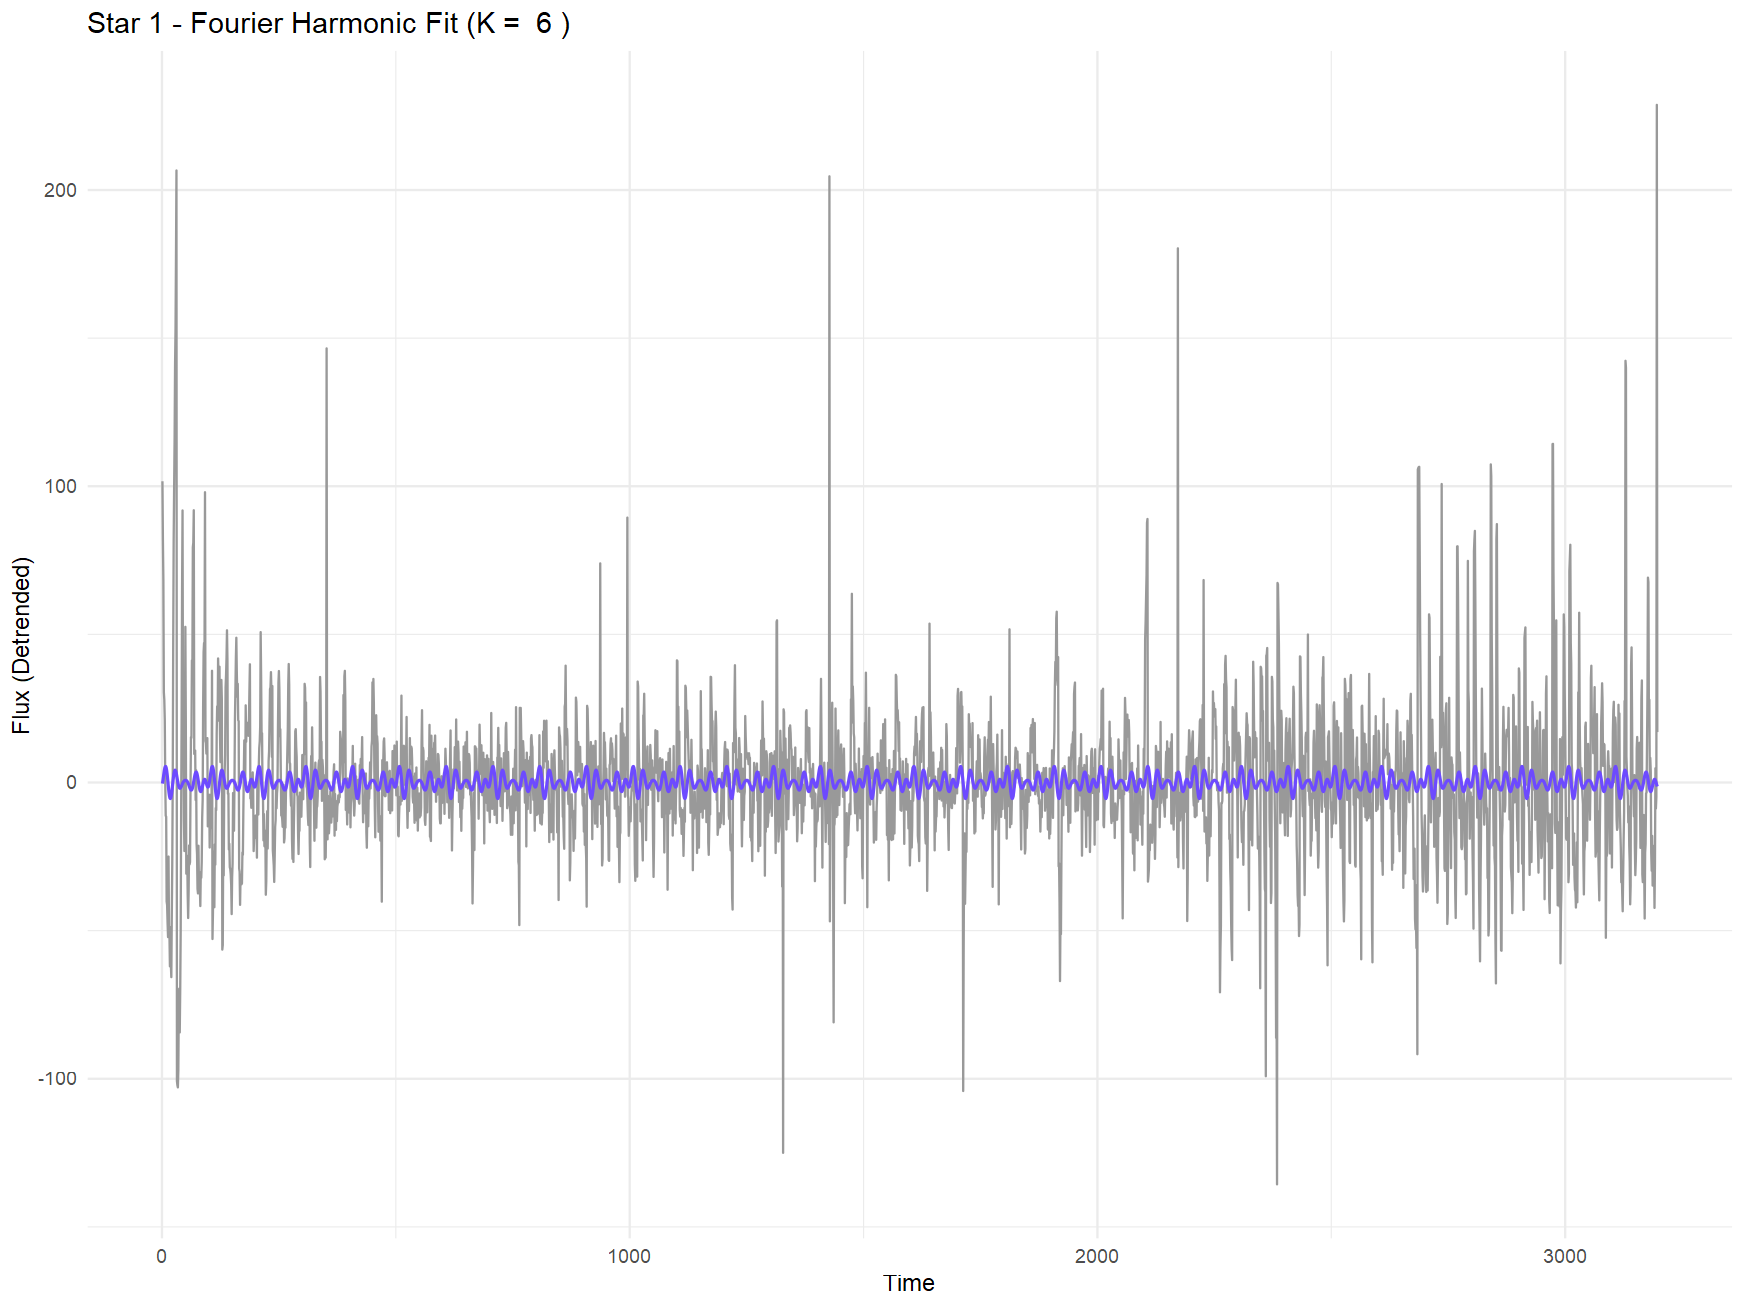

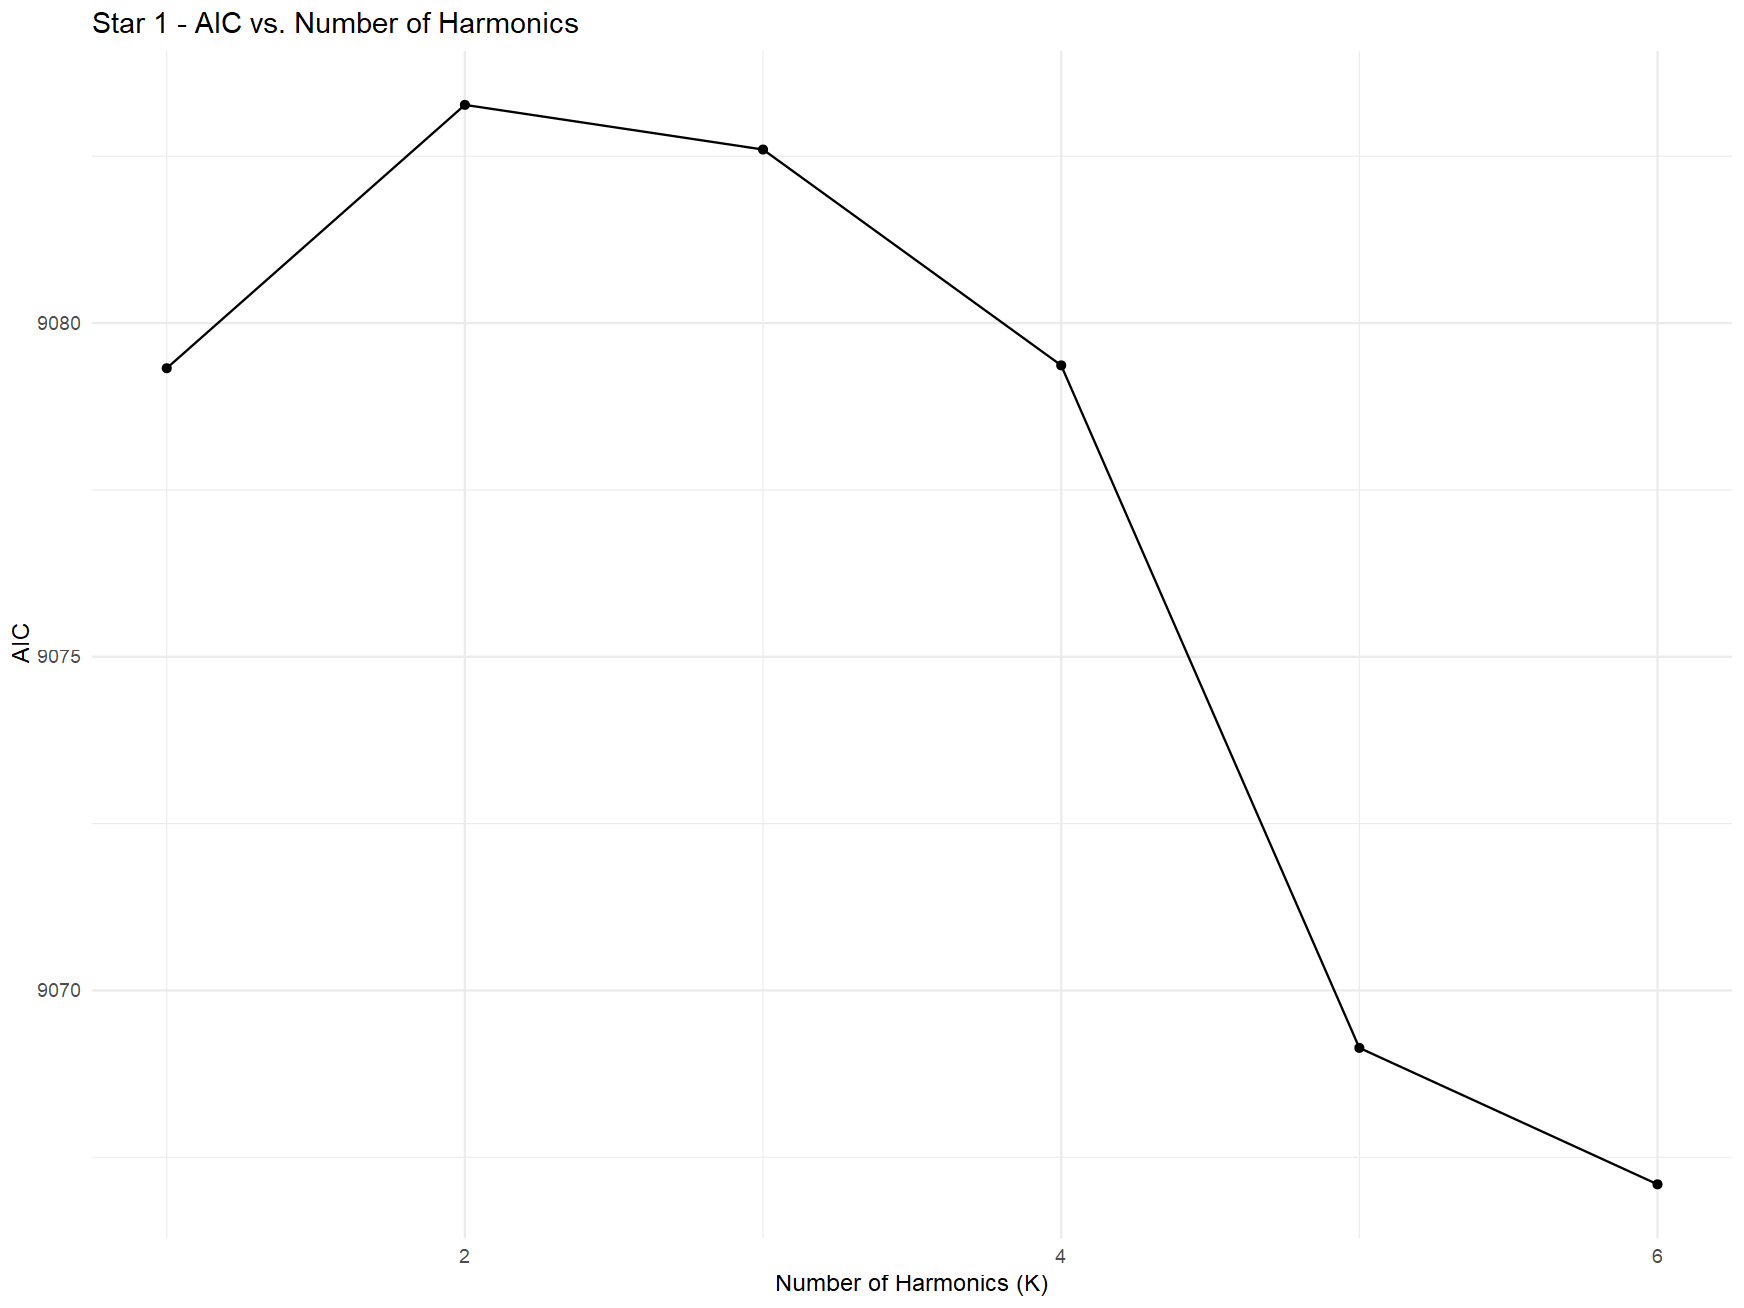

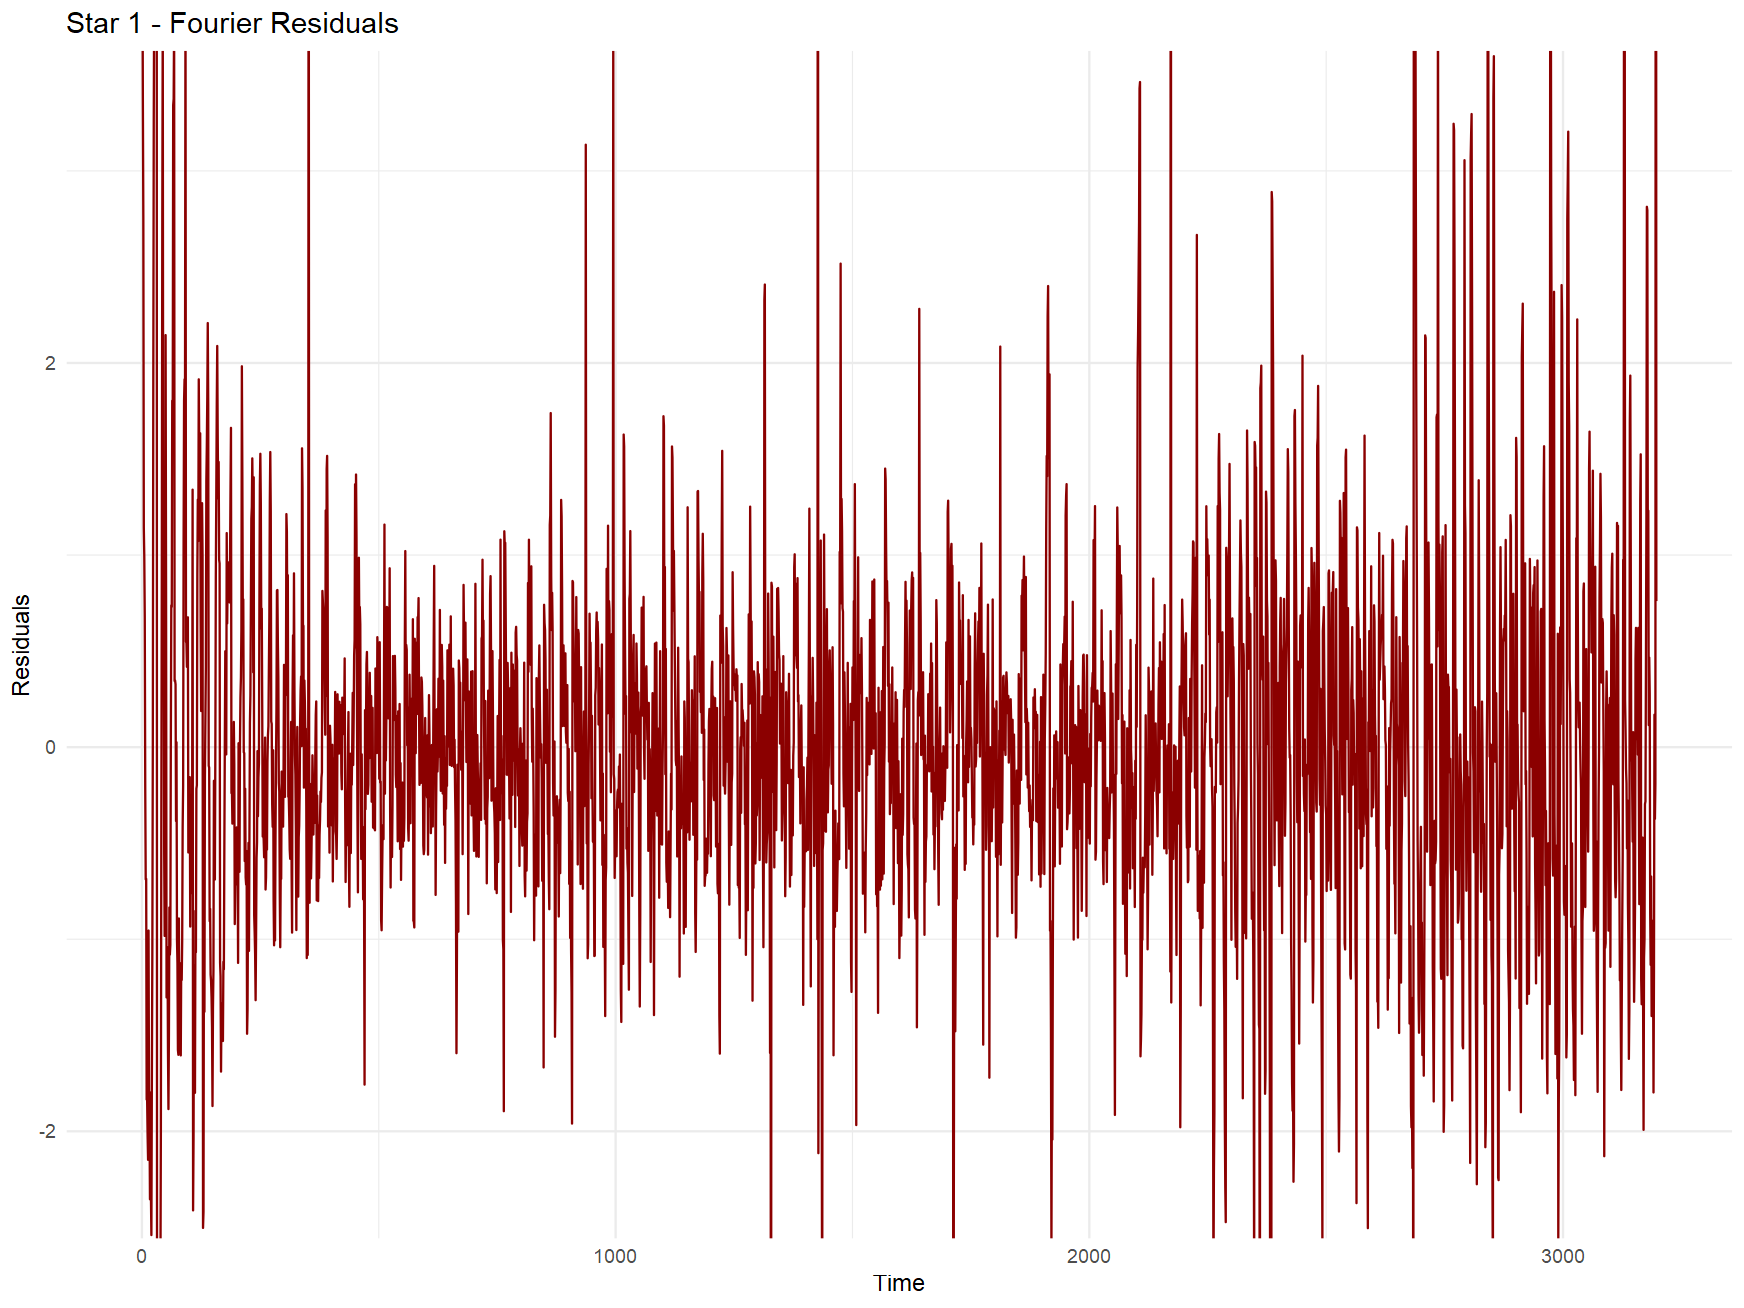

Warning messages:
1: In adfTest(log_ts, type = "ct") : p-value smaller than printed p-value
2: In kpss.test(log_ts, null = "Level") :
  p-value greater than printed p-value


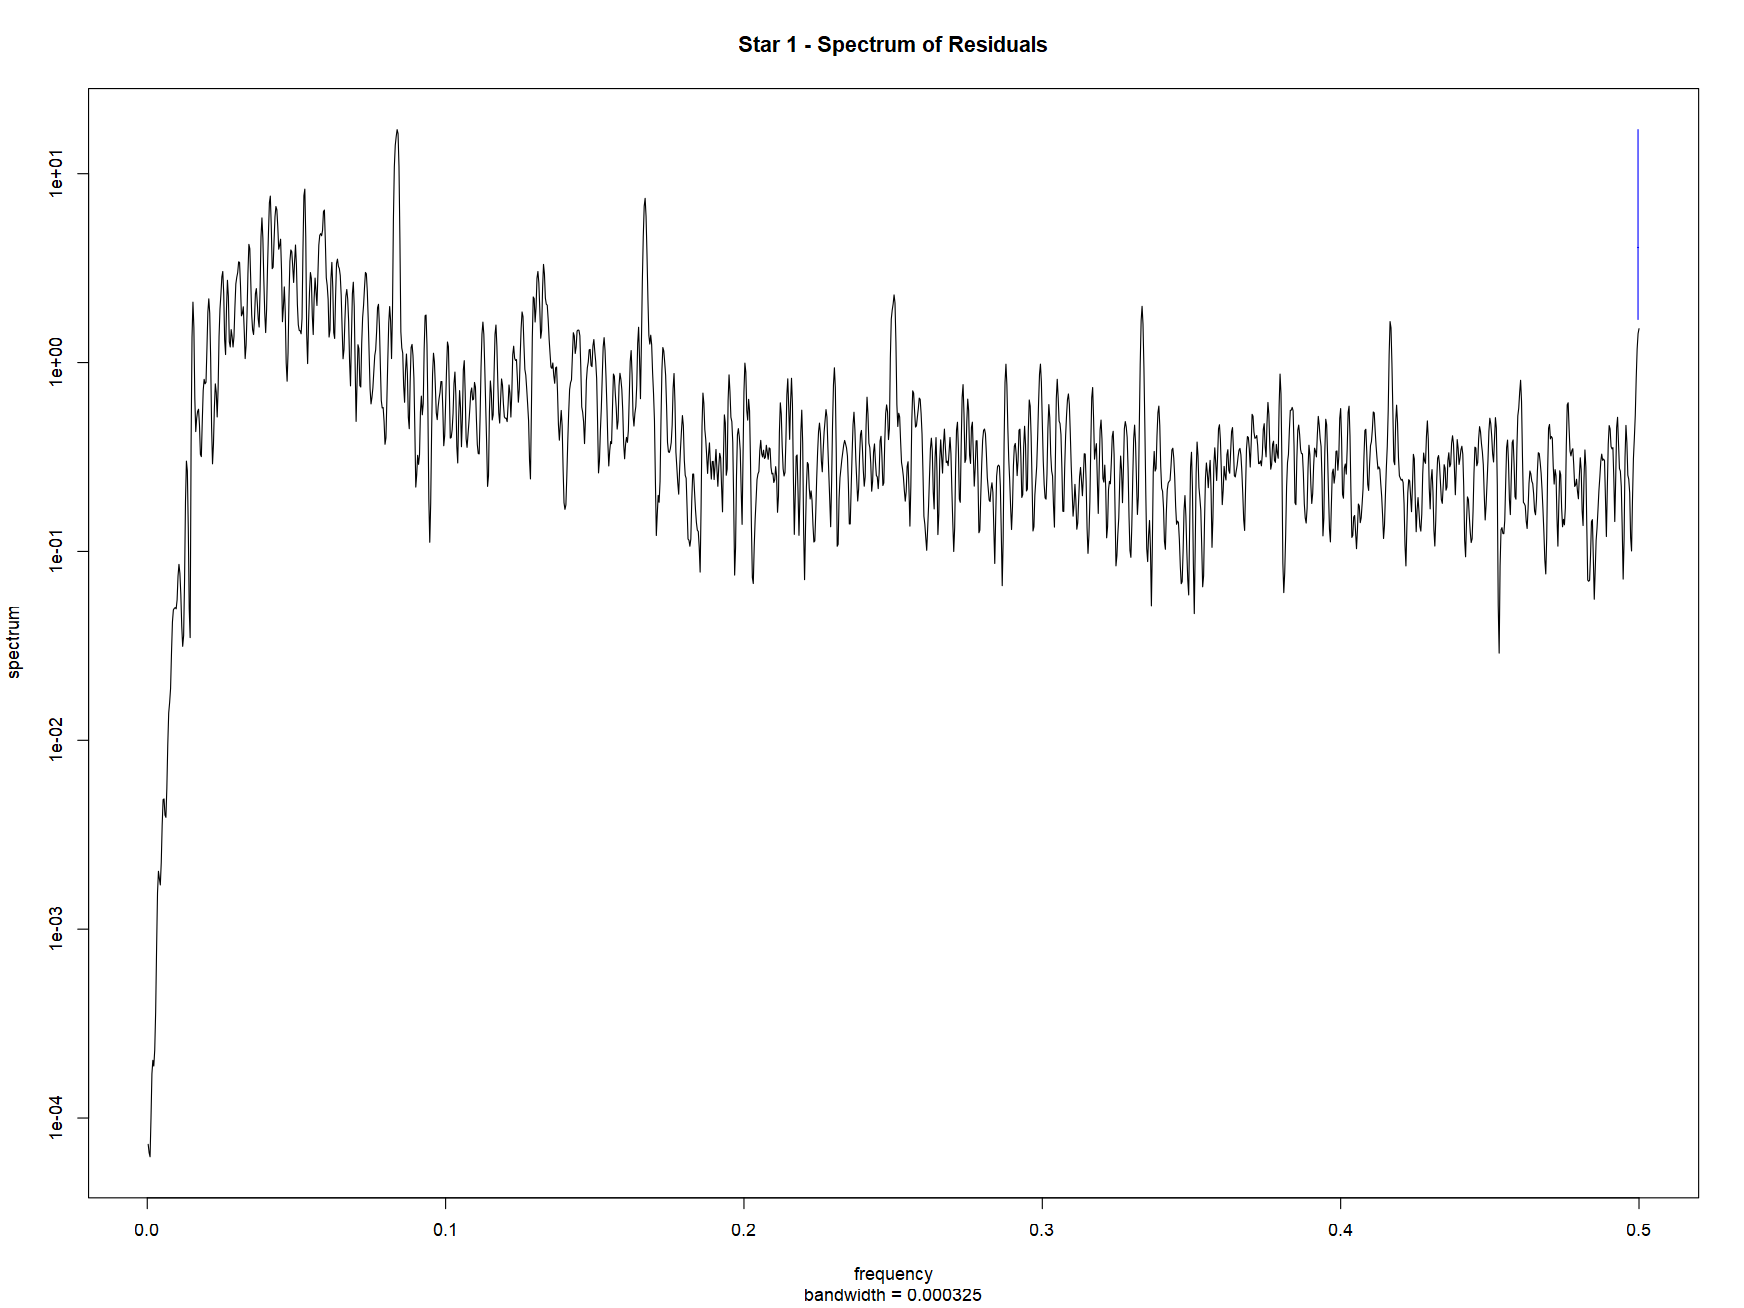

In [9]:
results[[1]] <- list(
  arima = analyze_star_arima(stars[[1]], "Star 1", "Yes", star_ids[1]),
  fourier = analyze_star_fourier(stars[[1]], "Star 1", star_ids[1], "Yes")
)


ARIMA Analysis for Star 2  ( Row 2 )
Exoplanet Present: Yes 
ADF p-value: 0.0100 | KPSS p-value: 0.0415
Differencing applied: TRUE 


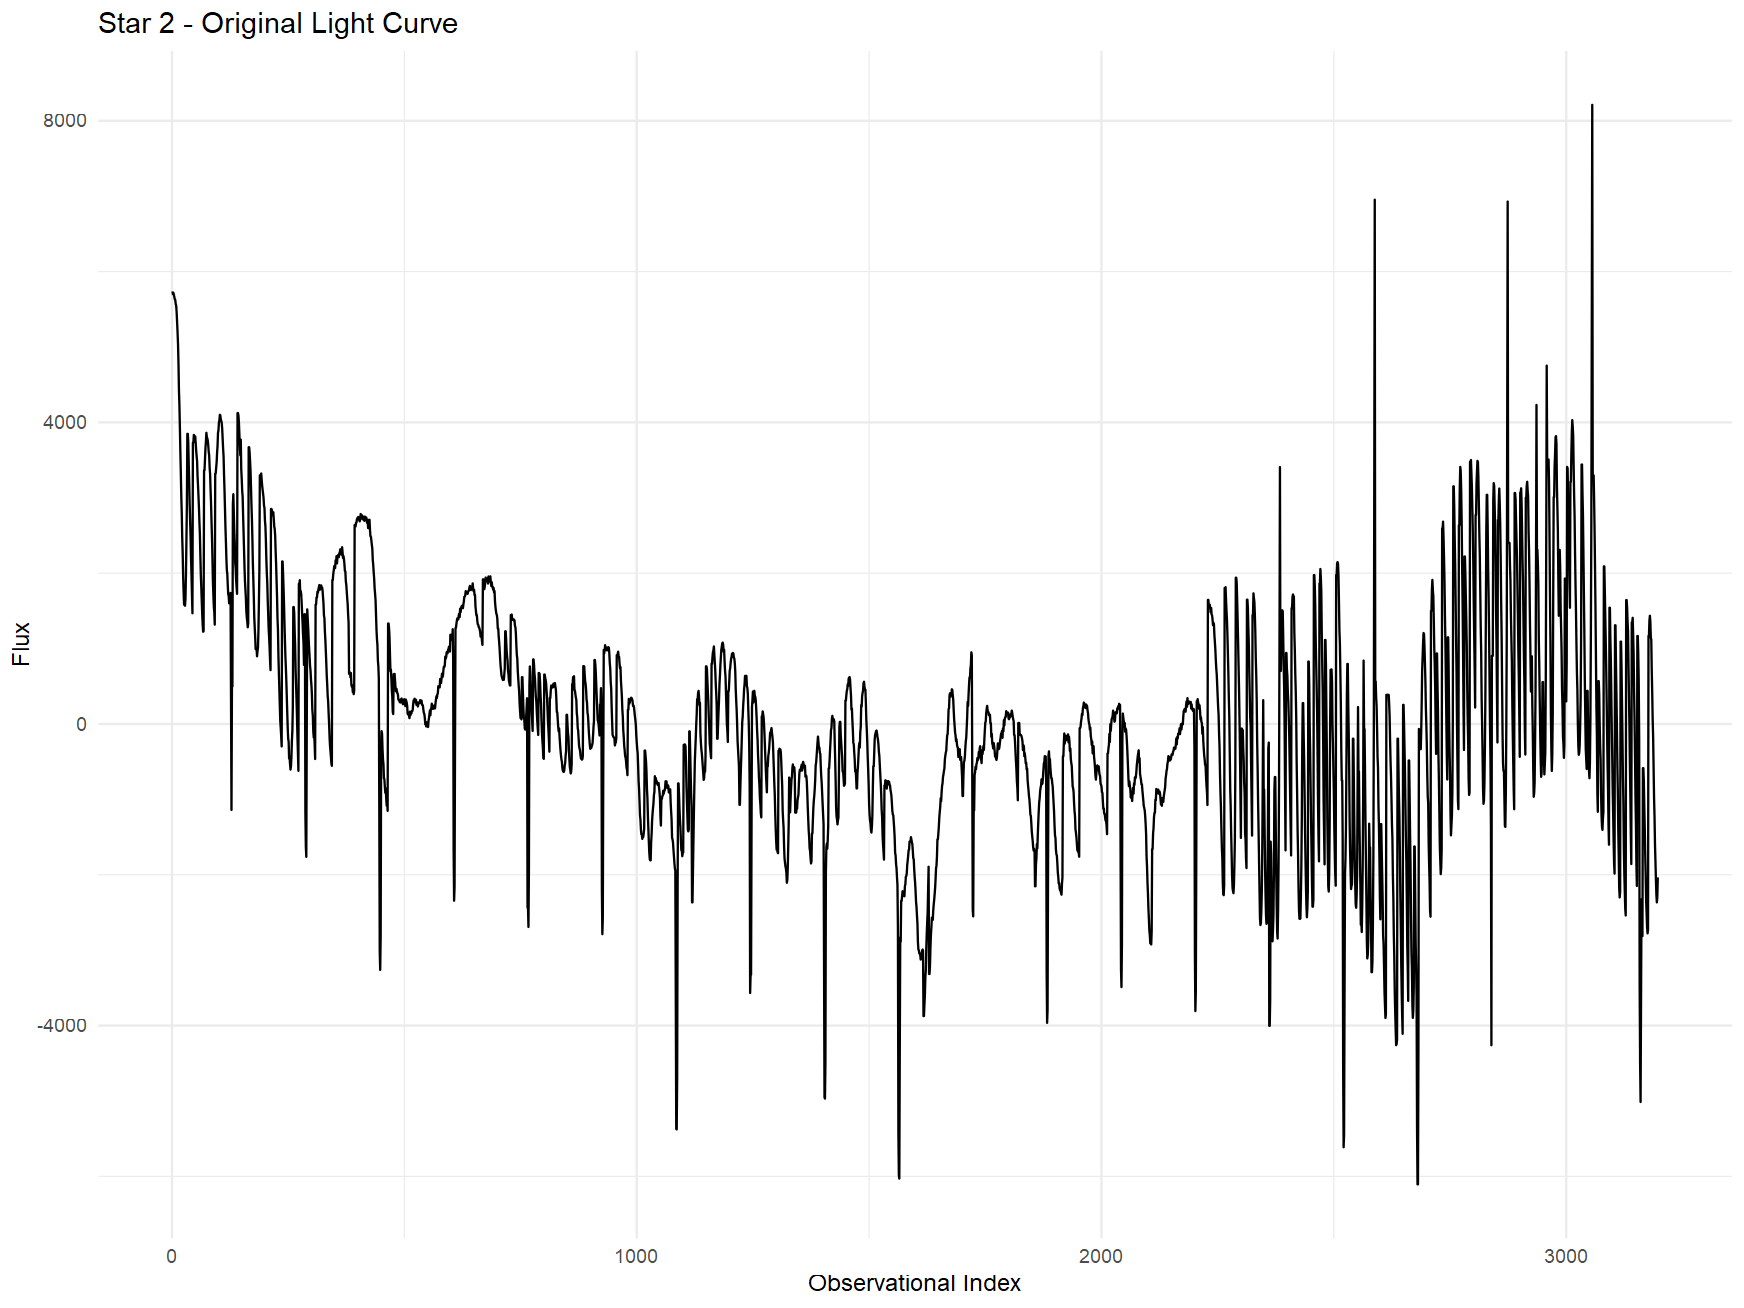

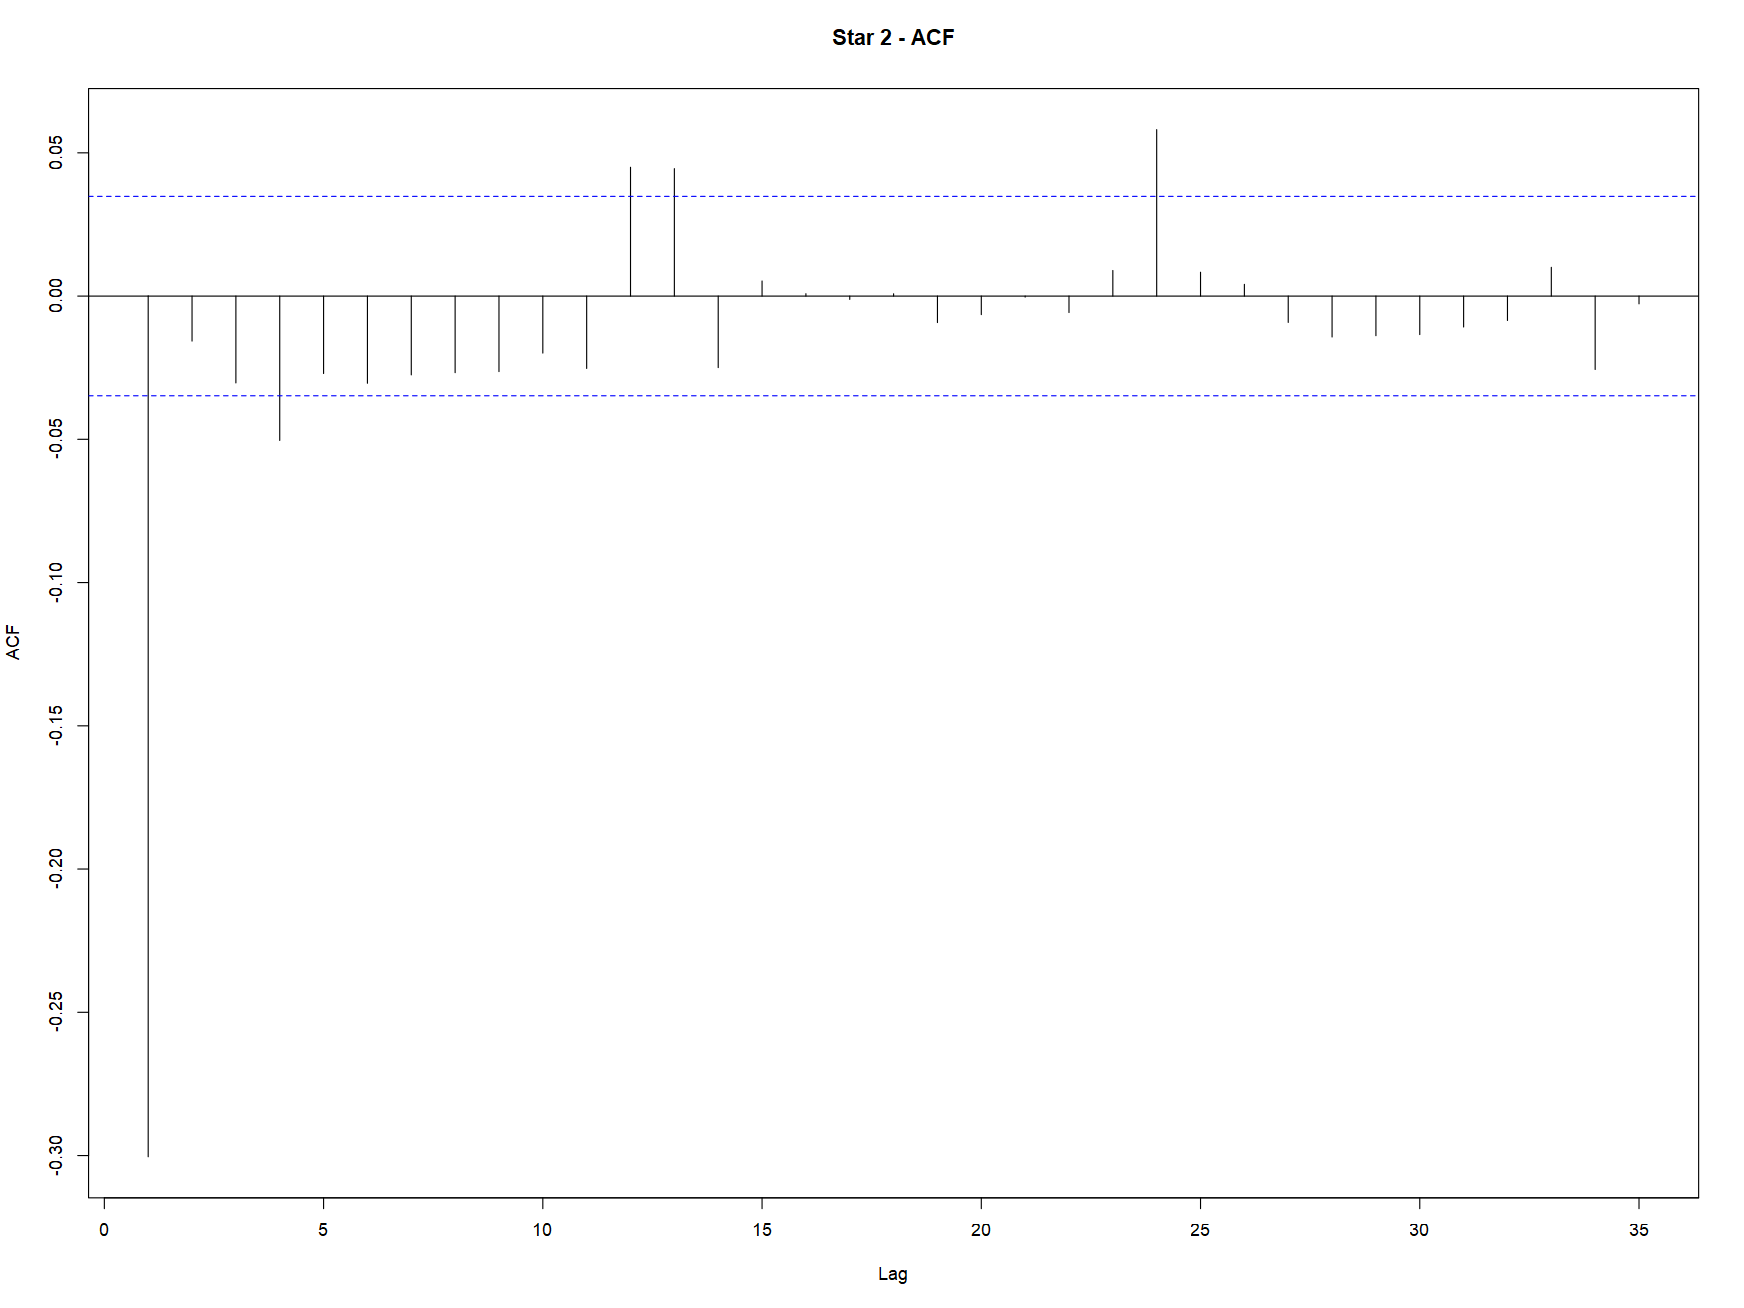

Select ARIMA: 0,0,2 

z test of coefficients:

     Estimate Std. Error  z value  Pr(>|z|)    
ma1 -0.403098   0.020938 -19.2521 < 2.2e-16 ***
ma2 -0.157308   0.030715  -5.1216 3.029e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



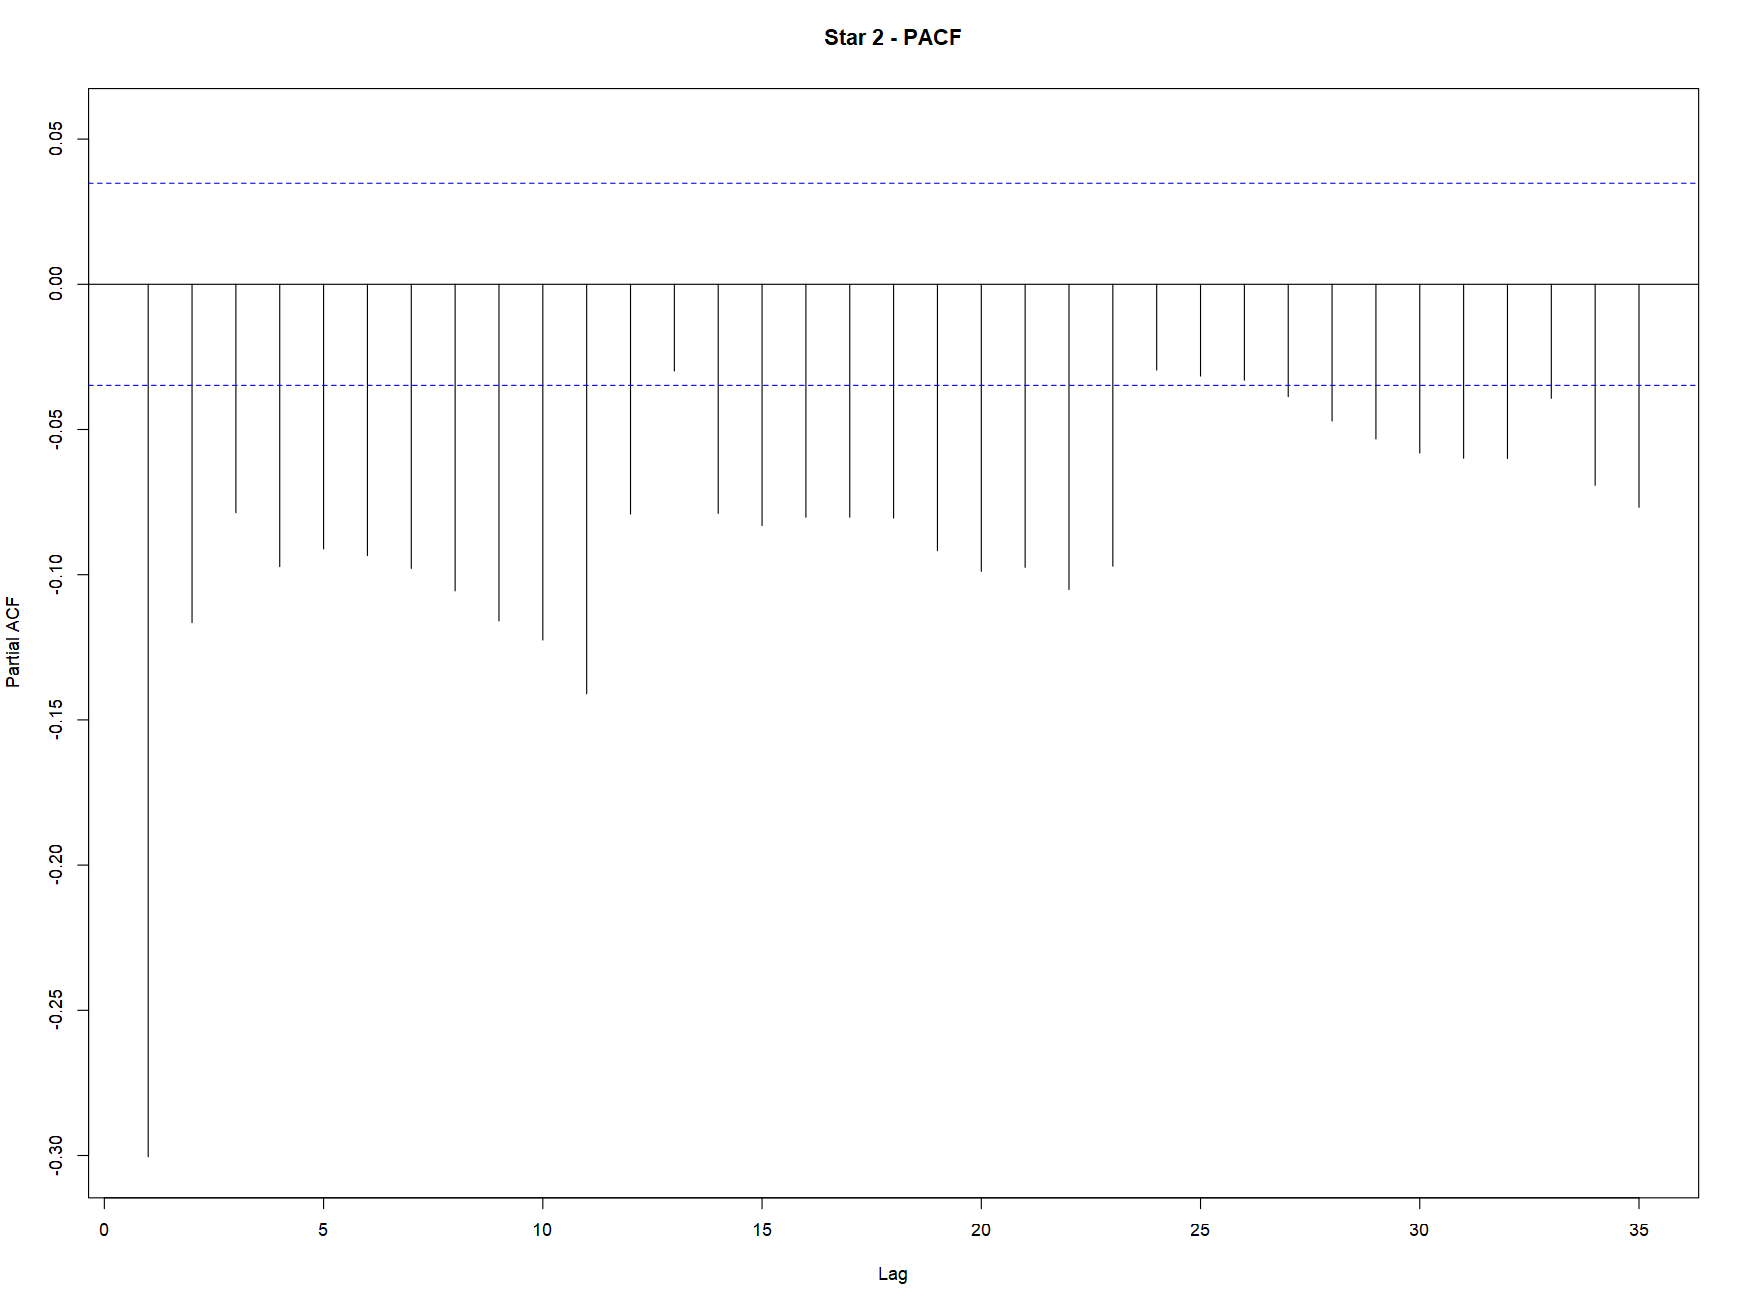

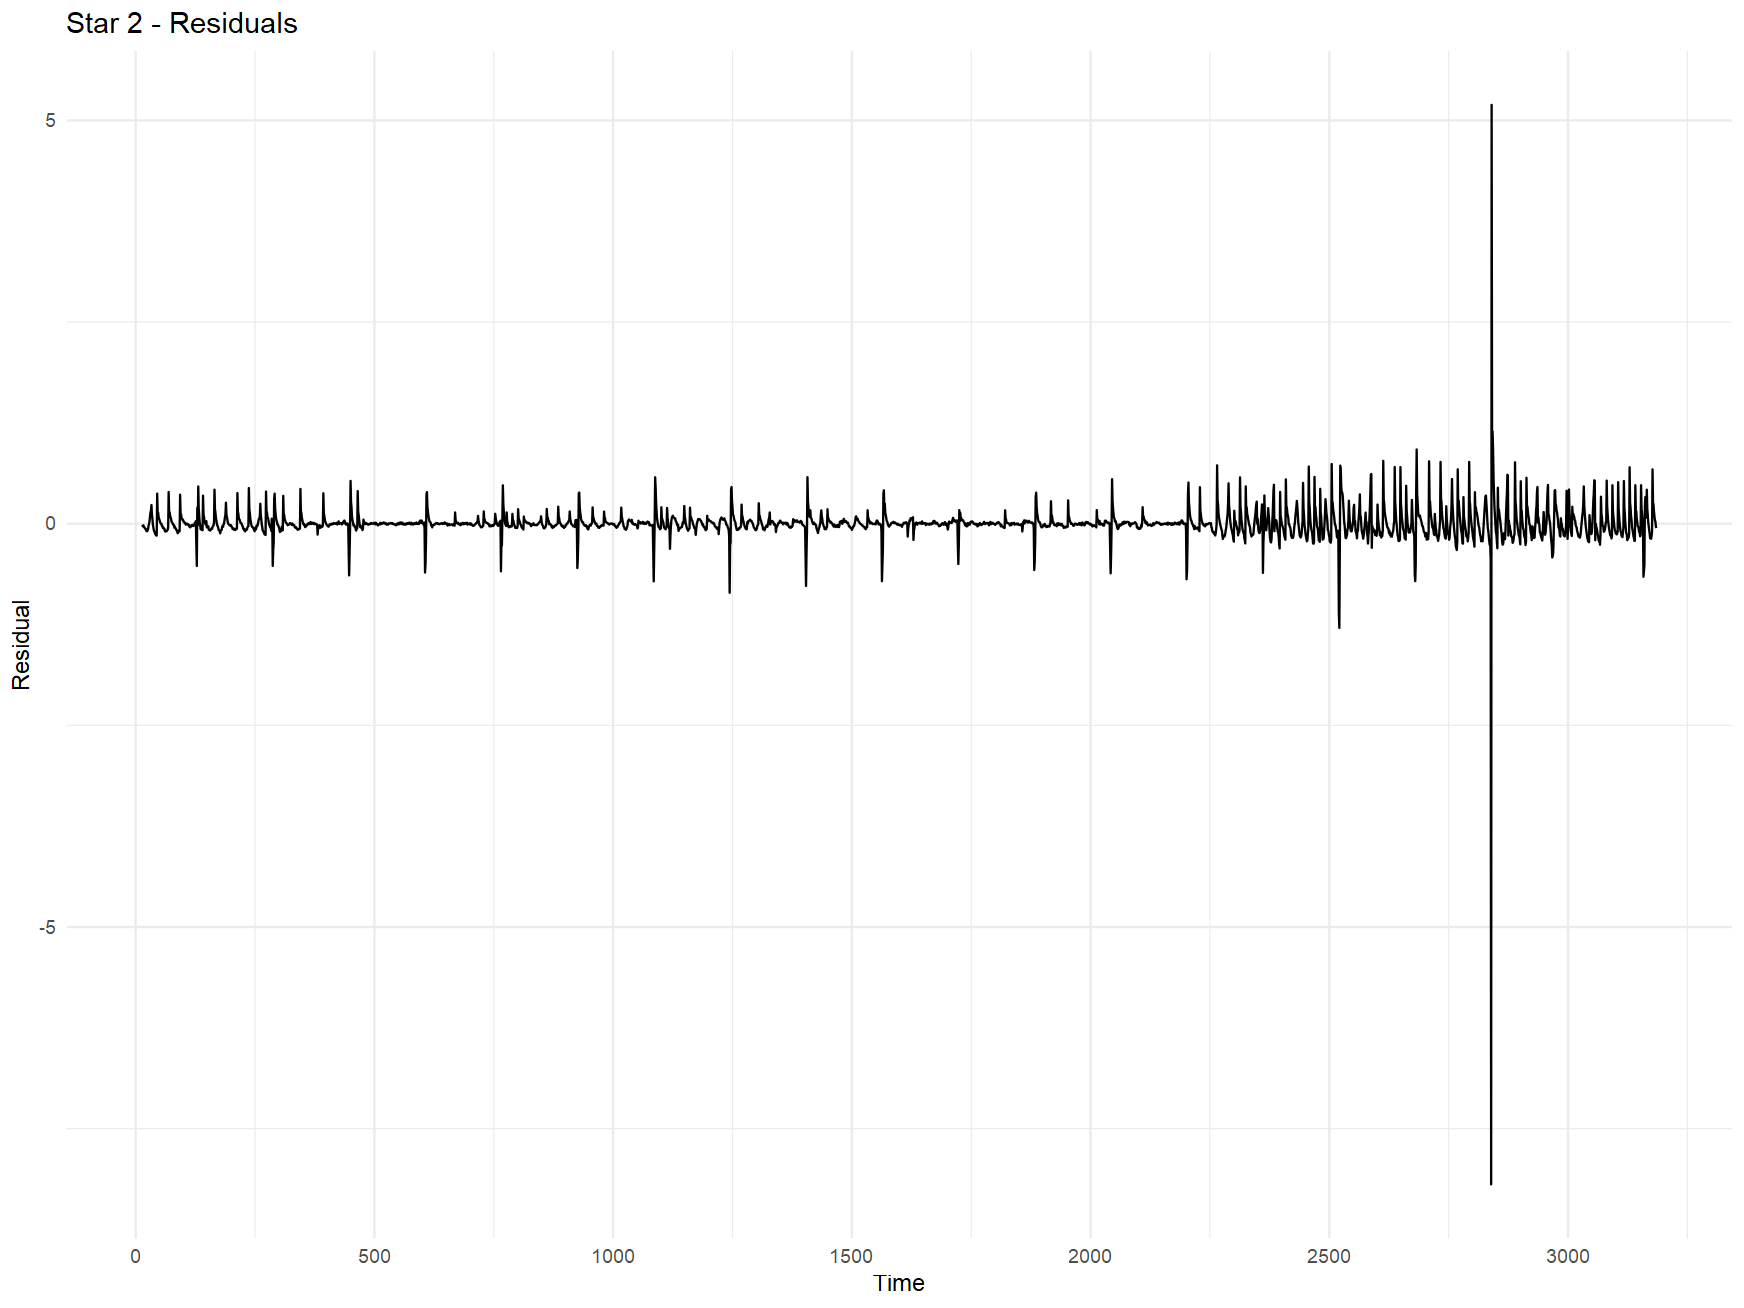

Ljung-Box p-value (lag 20, fitdf=2): 0.0000


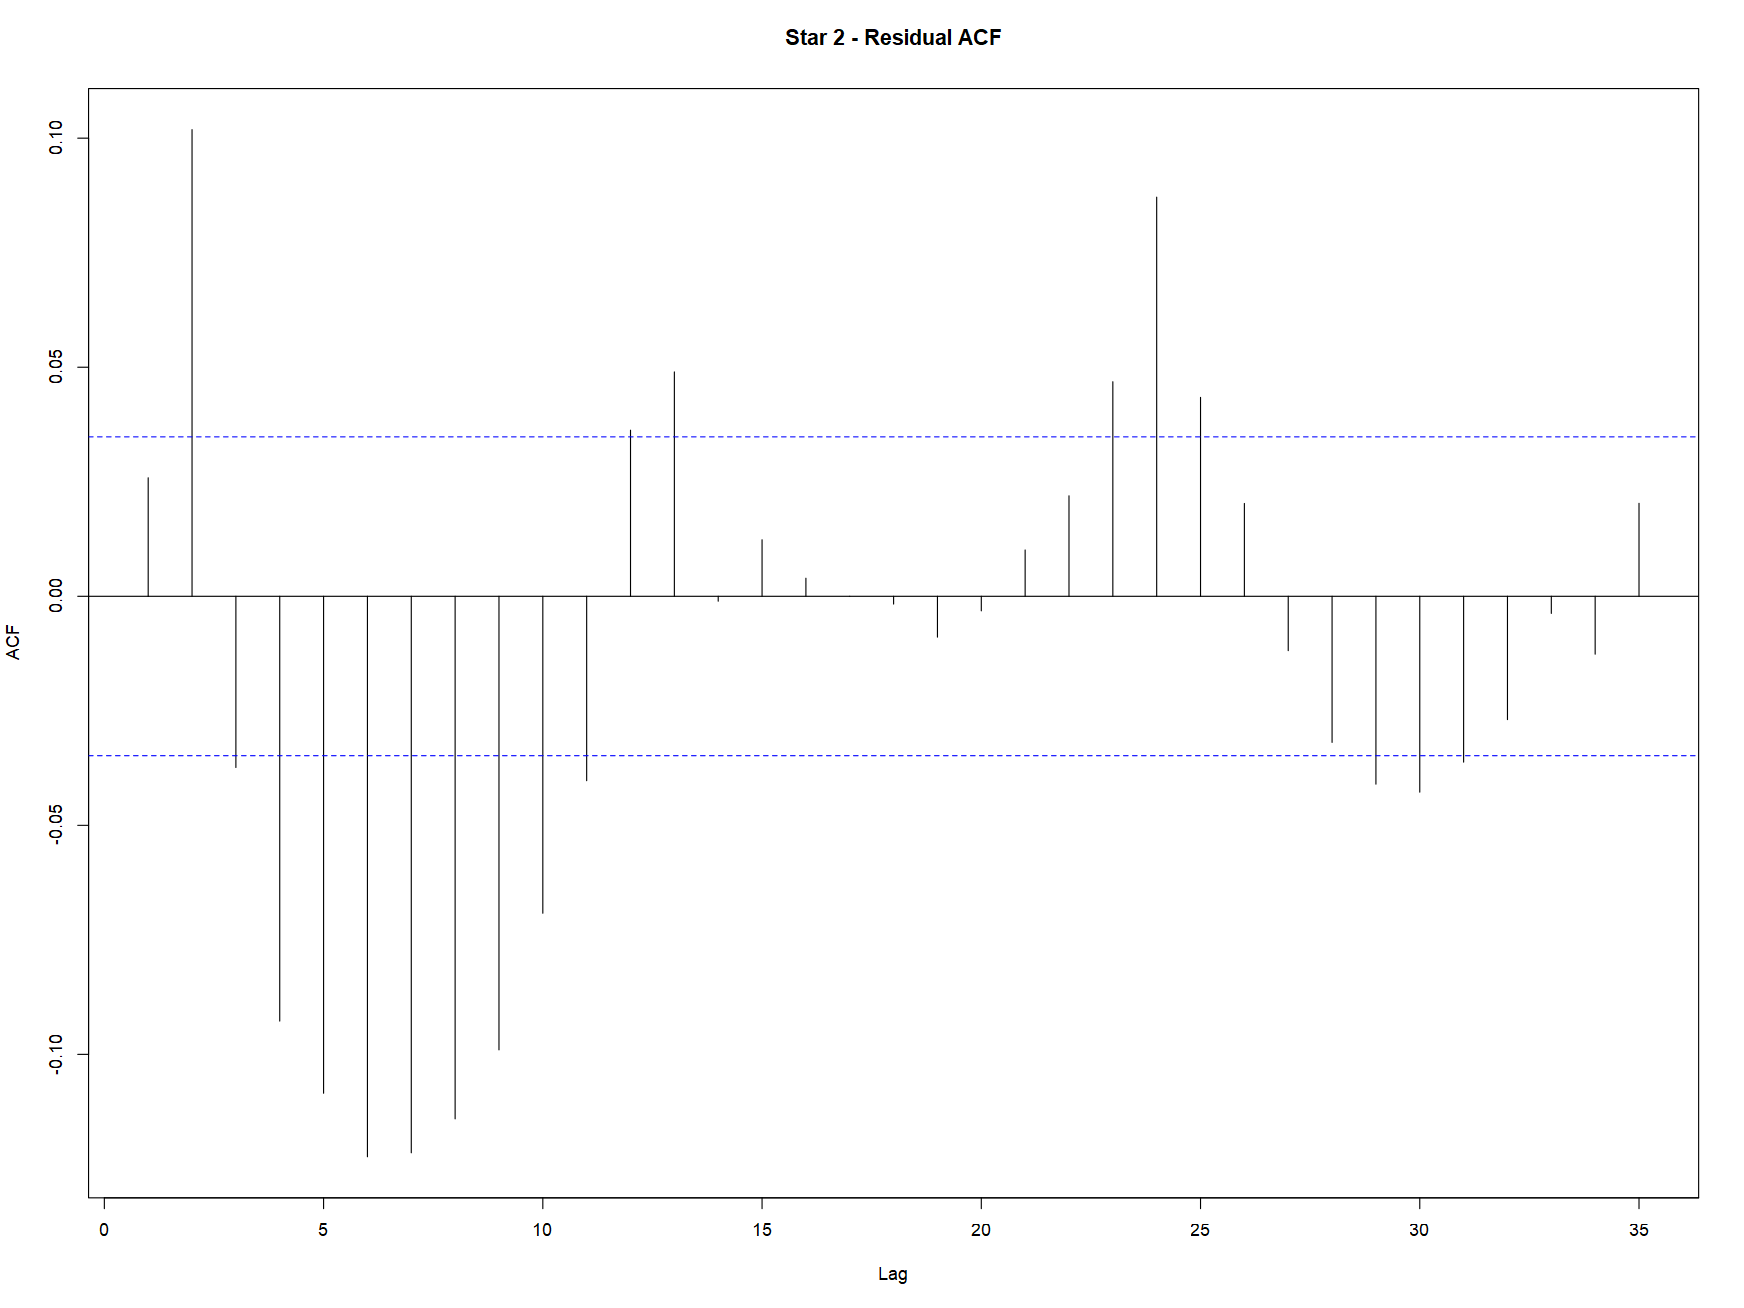

Flagged points: 9 | Events: 4 
Events after edge guard: 3 


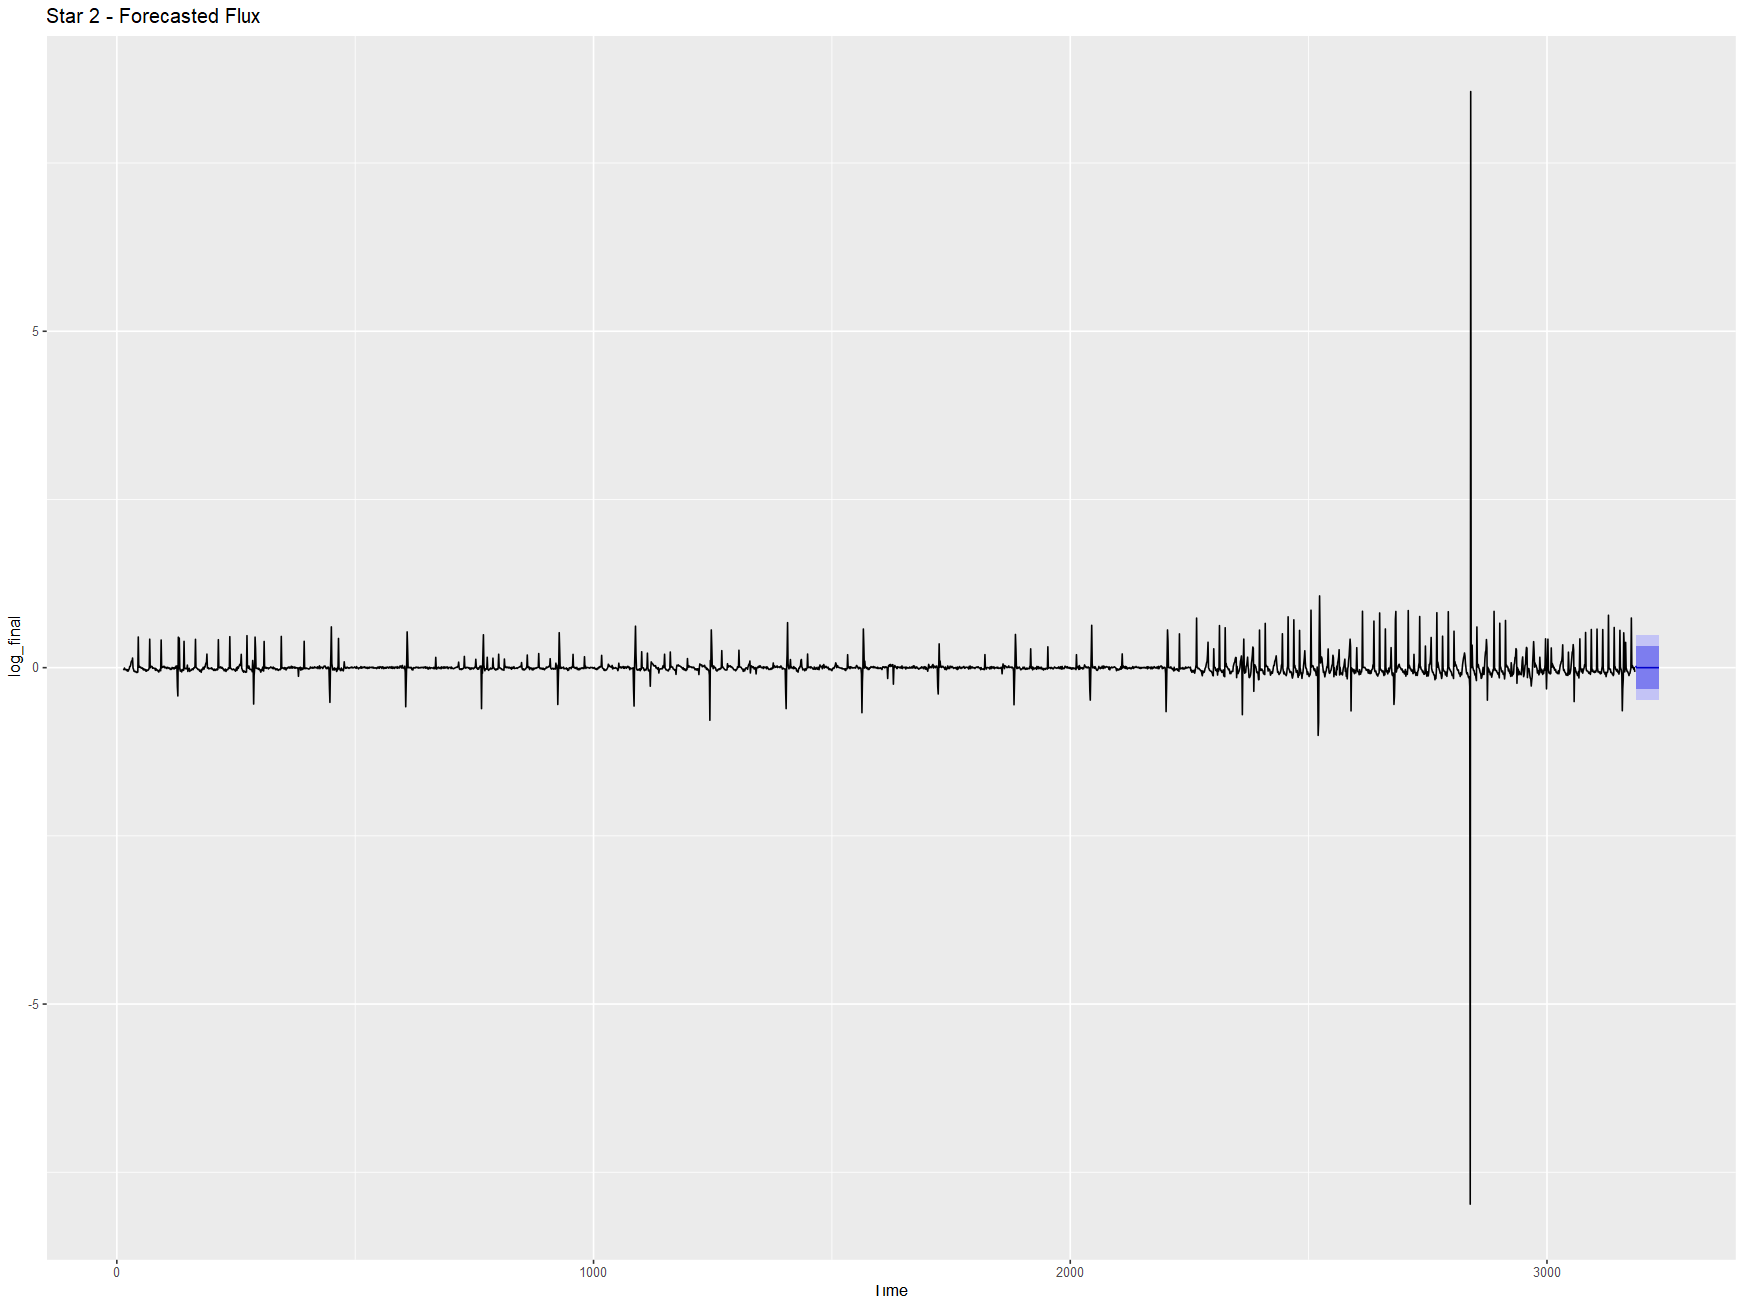

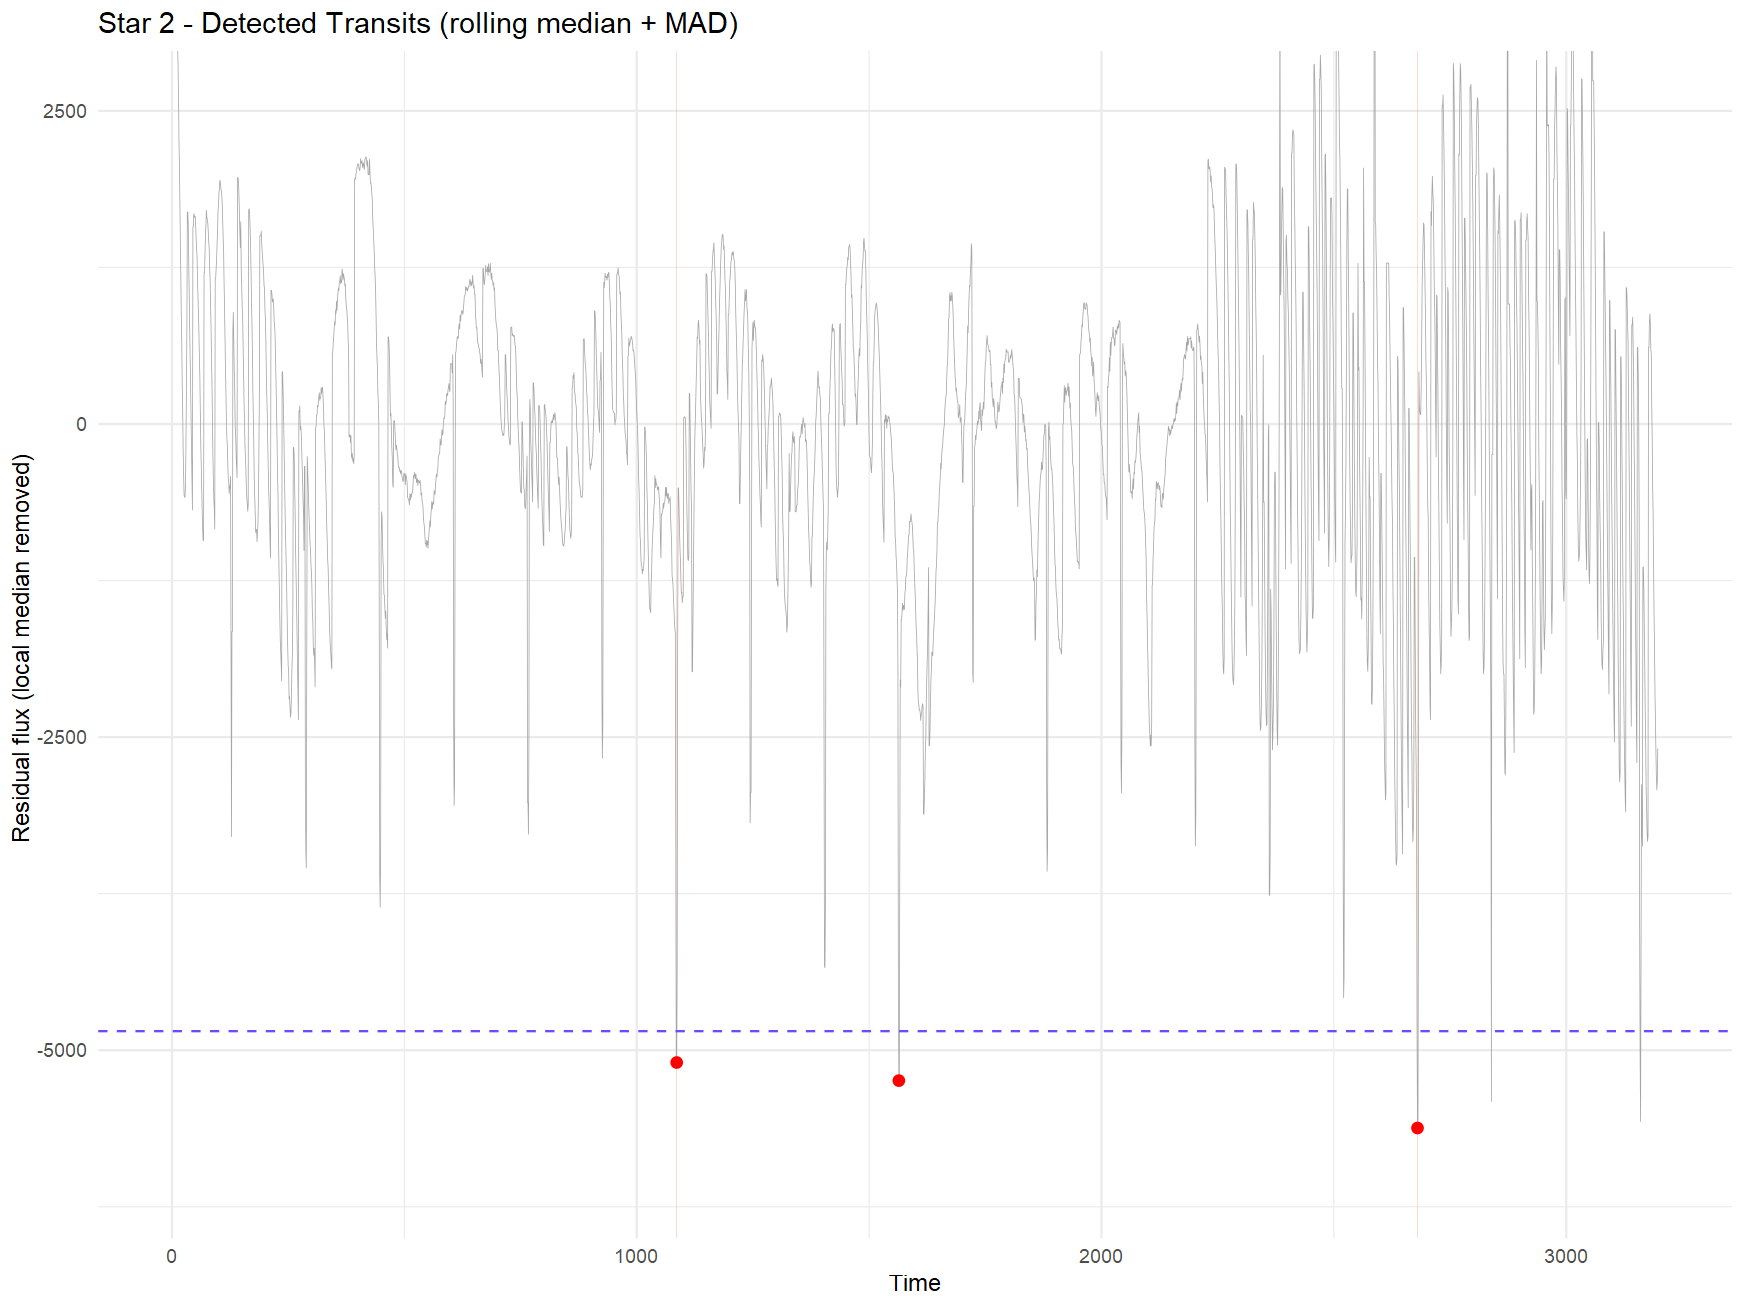


Fourier Analysis of Star 2  ( Row 2 )
Exoplanet Present: Yes 
AIC values by K: 9079.22 9083.12 9085.93 9066.38 8956.31 8959.77 
Estimated Period: 100  | Chosen Harmonics (K): 5 


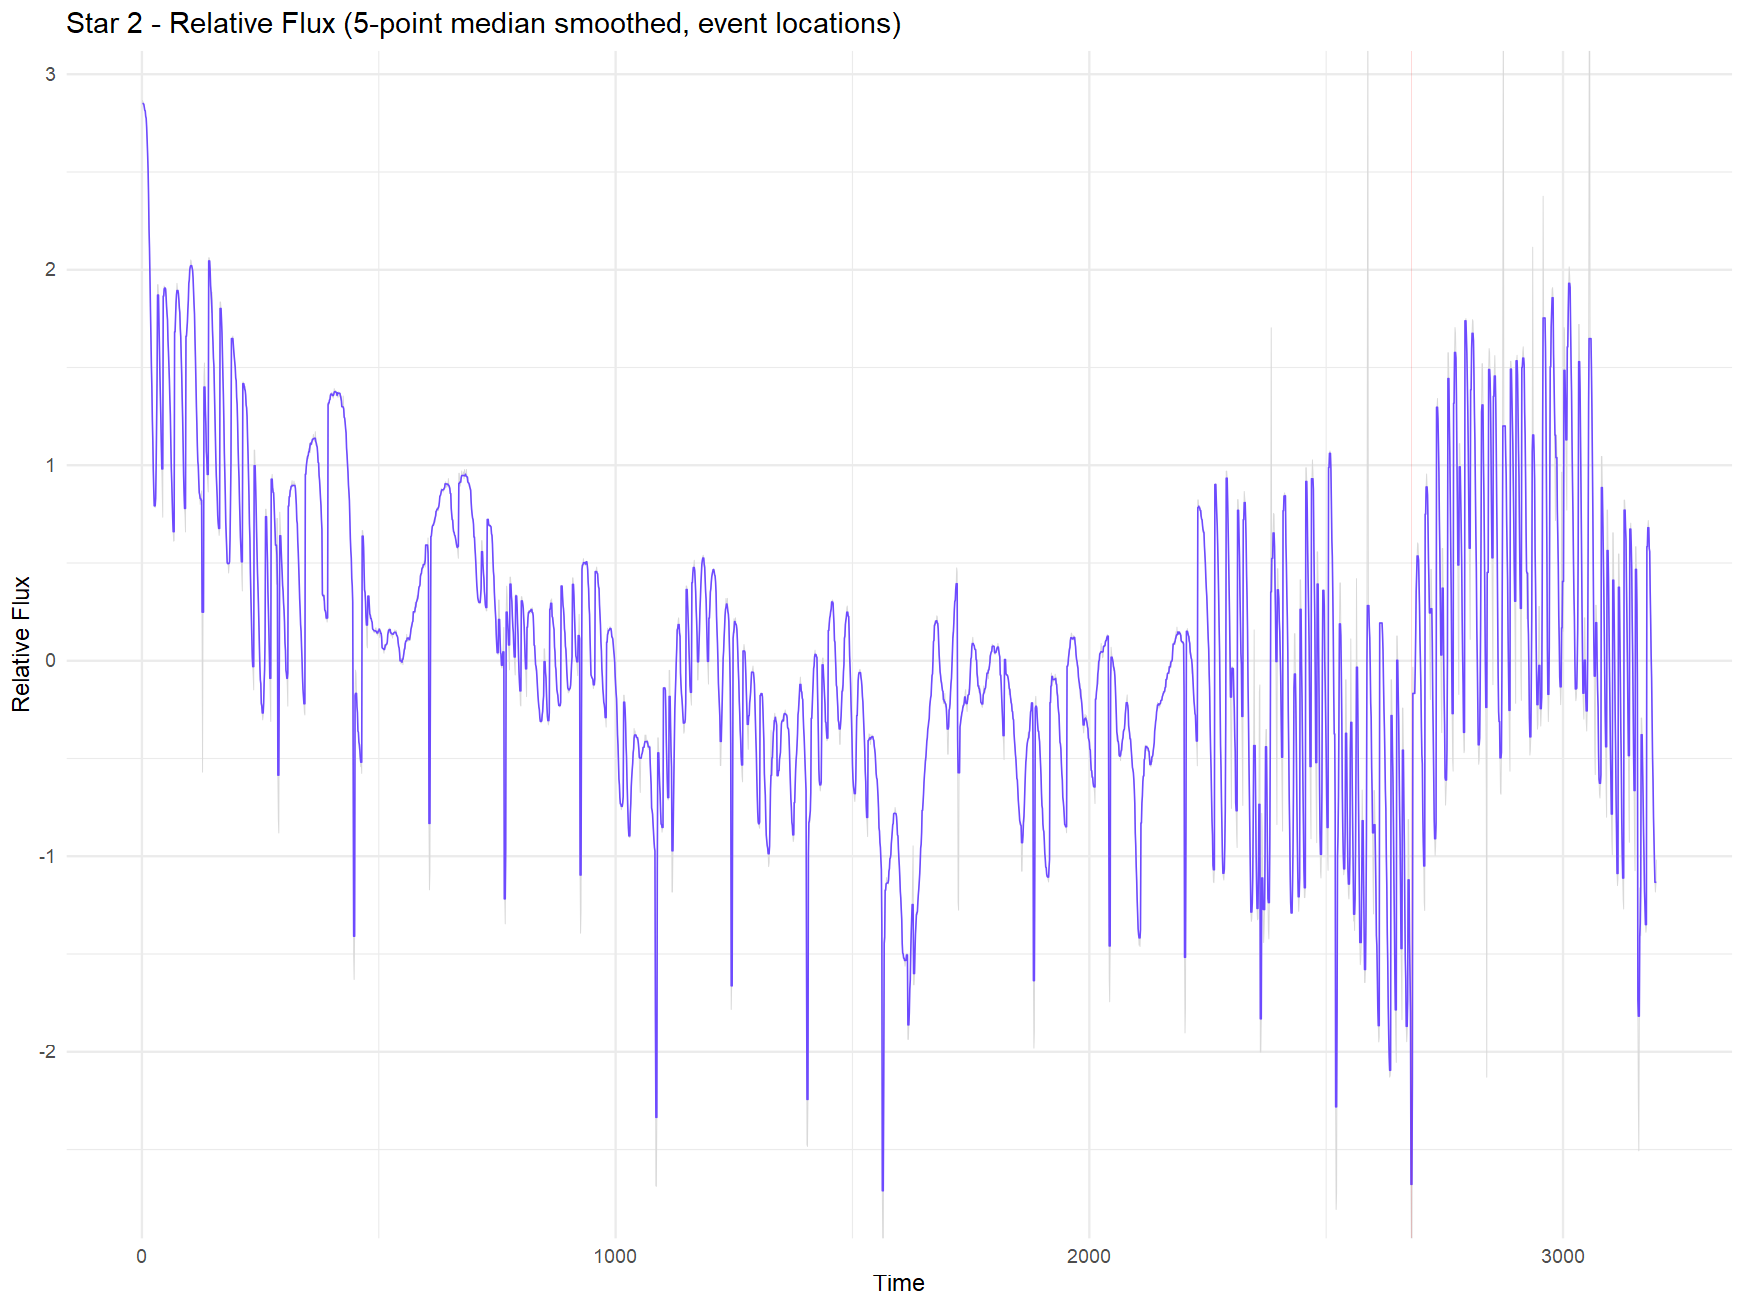

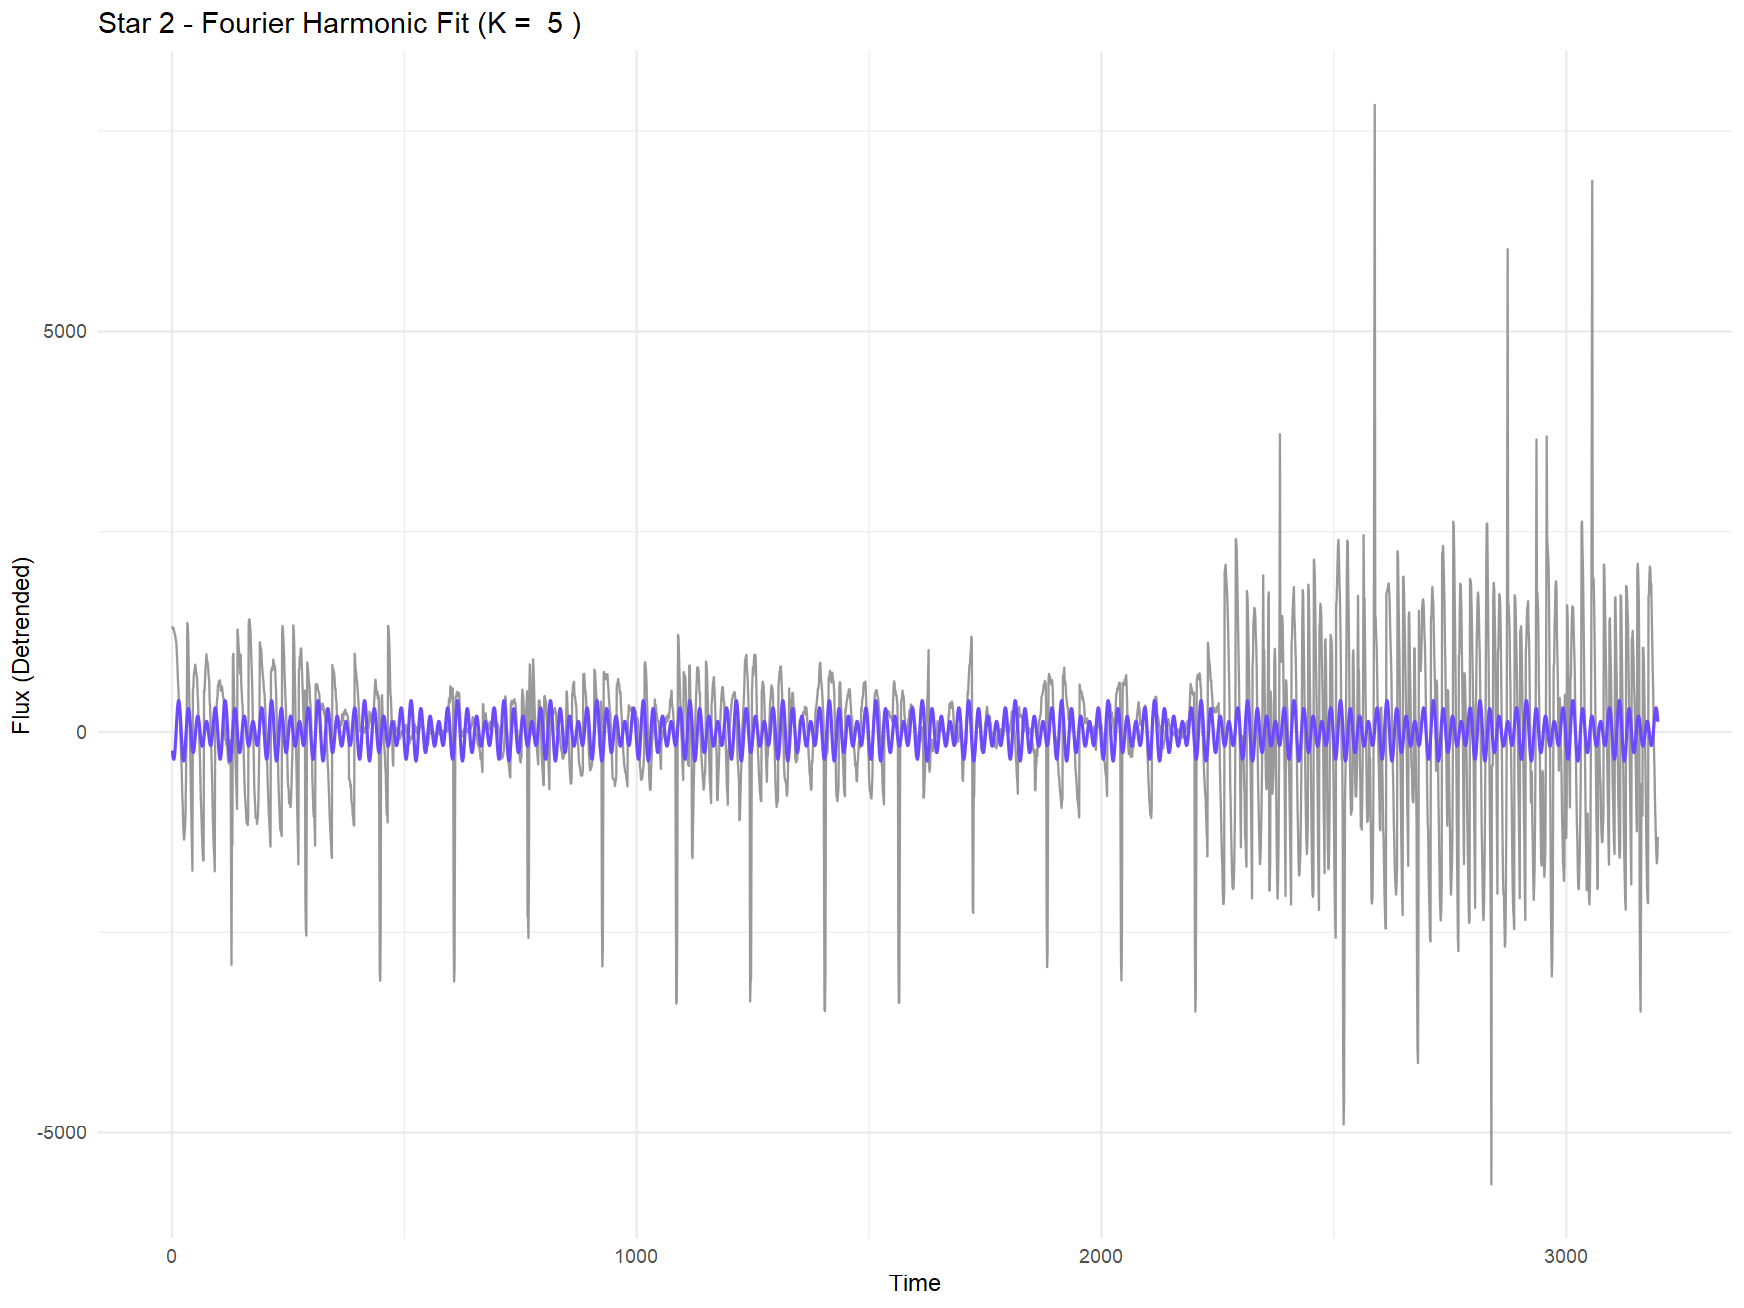

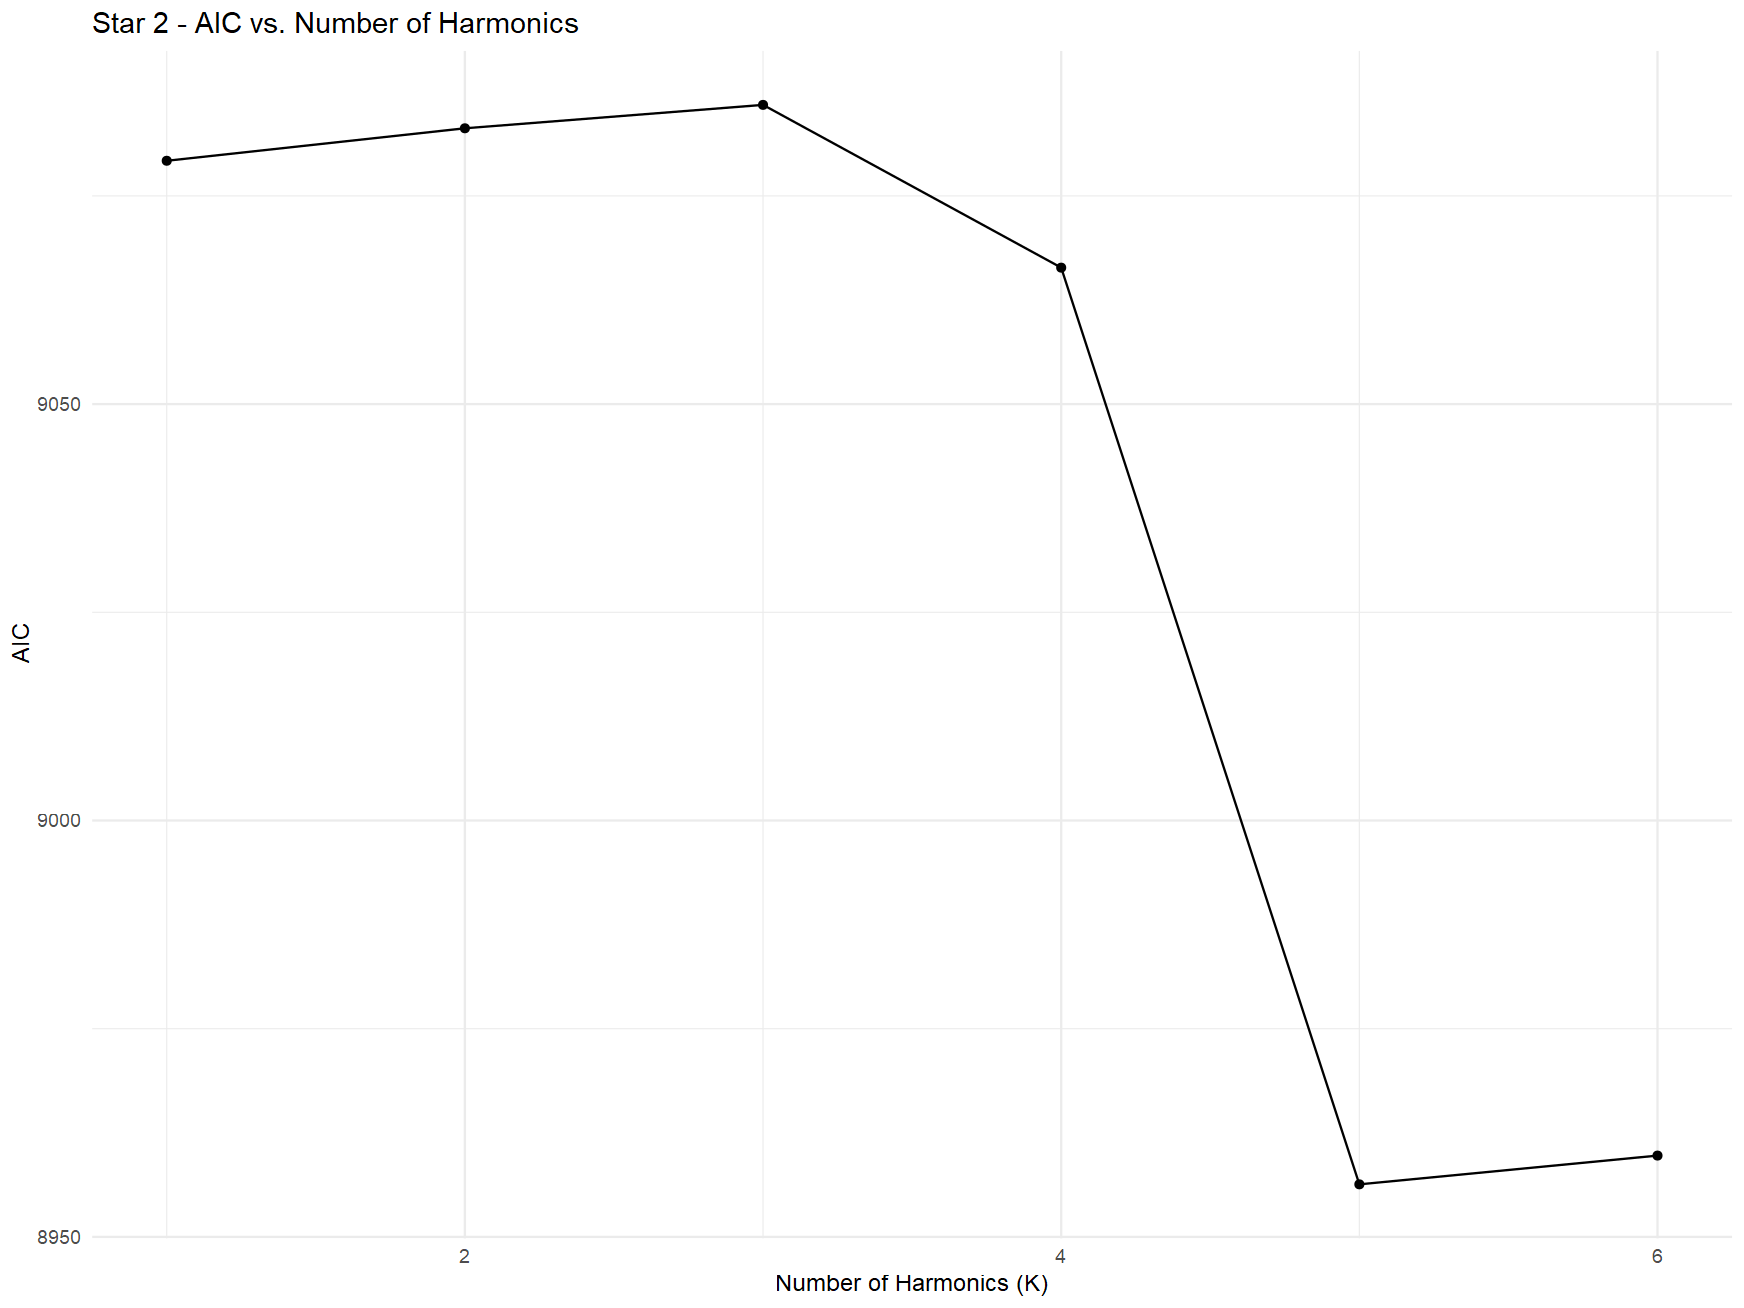

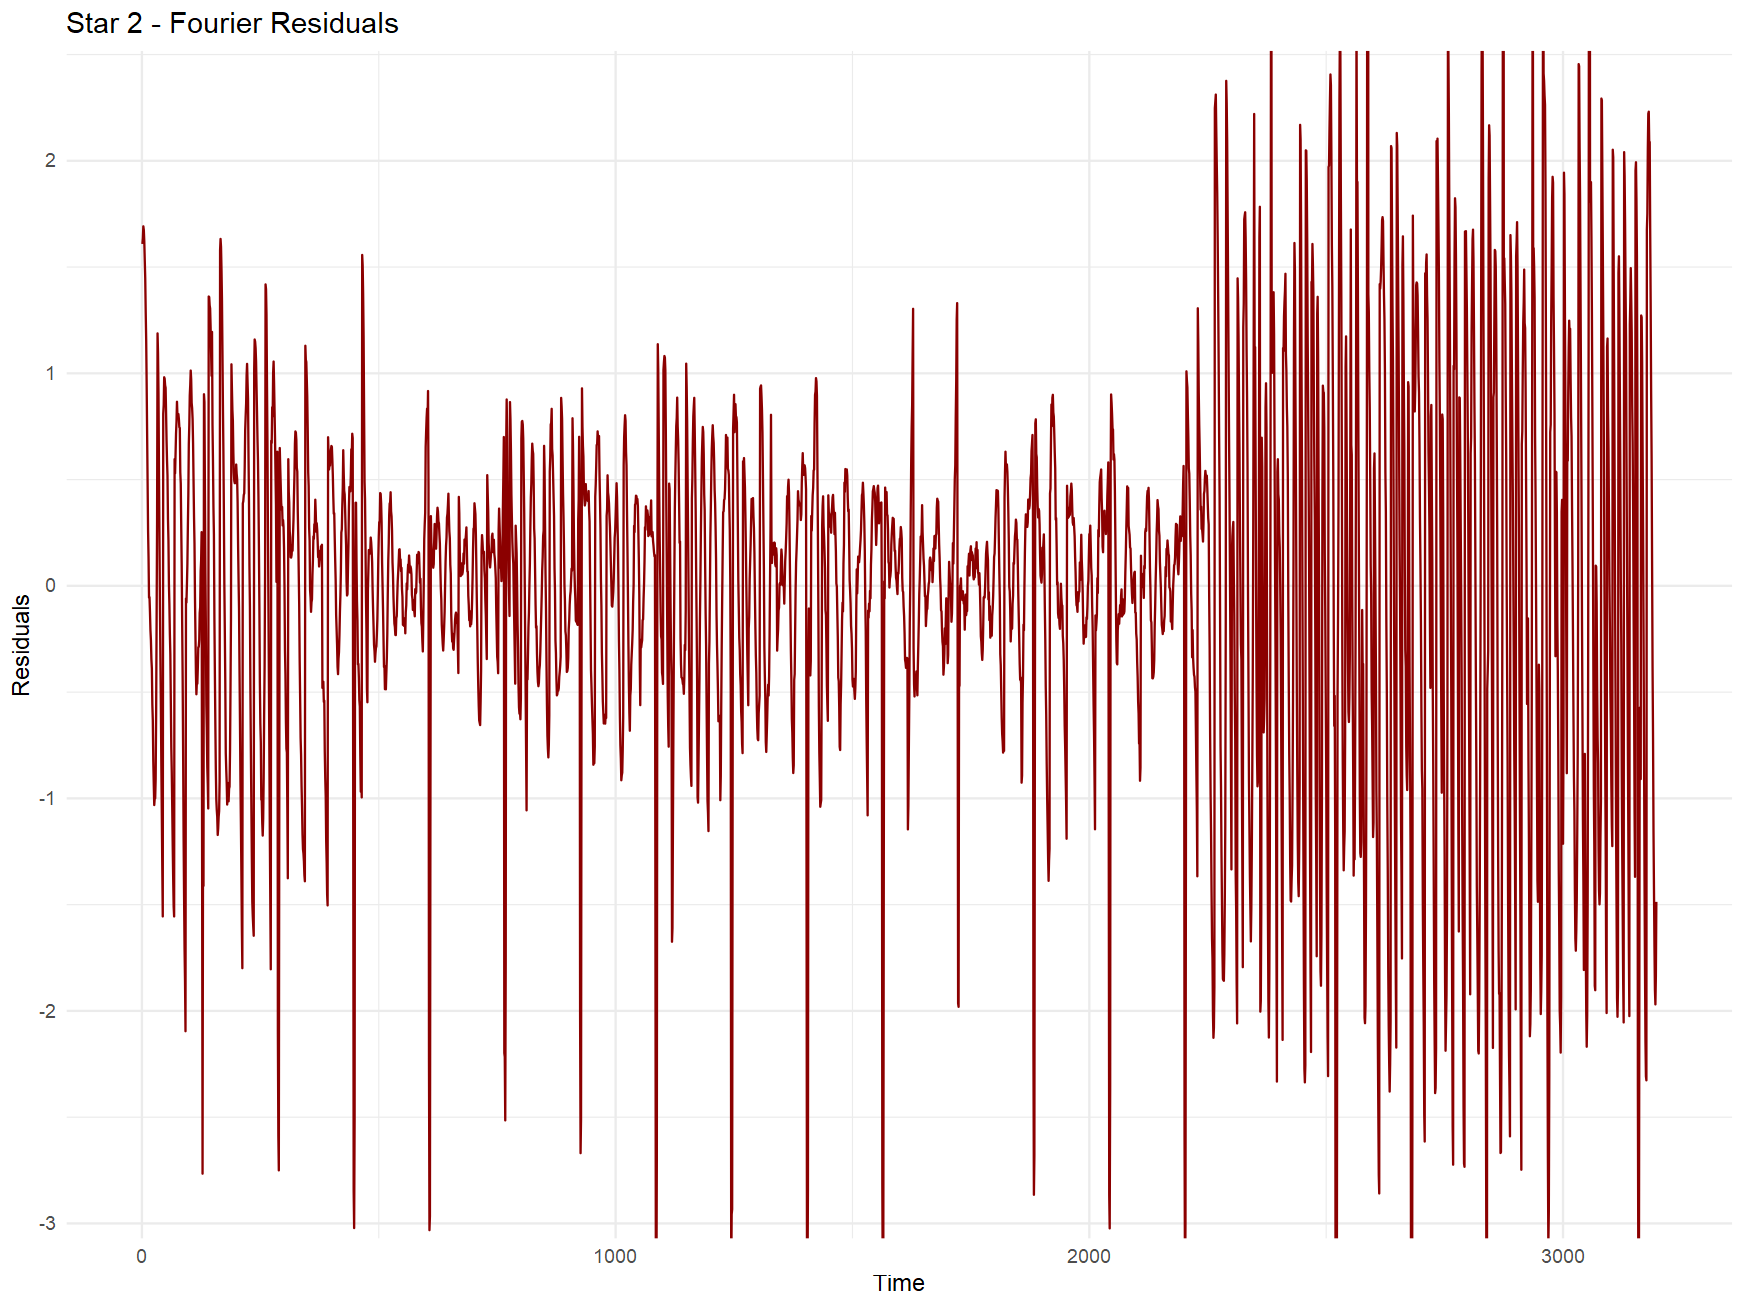

Warning message:
In adfTest(log_ts, type = "ct") : p-value smaller than printed p-value


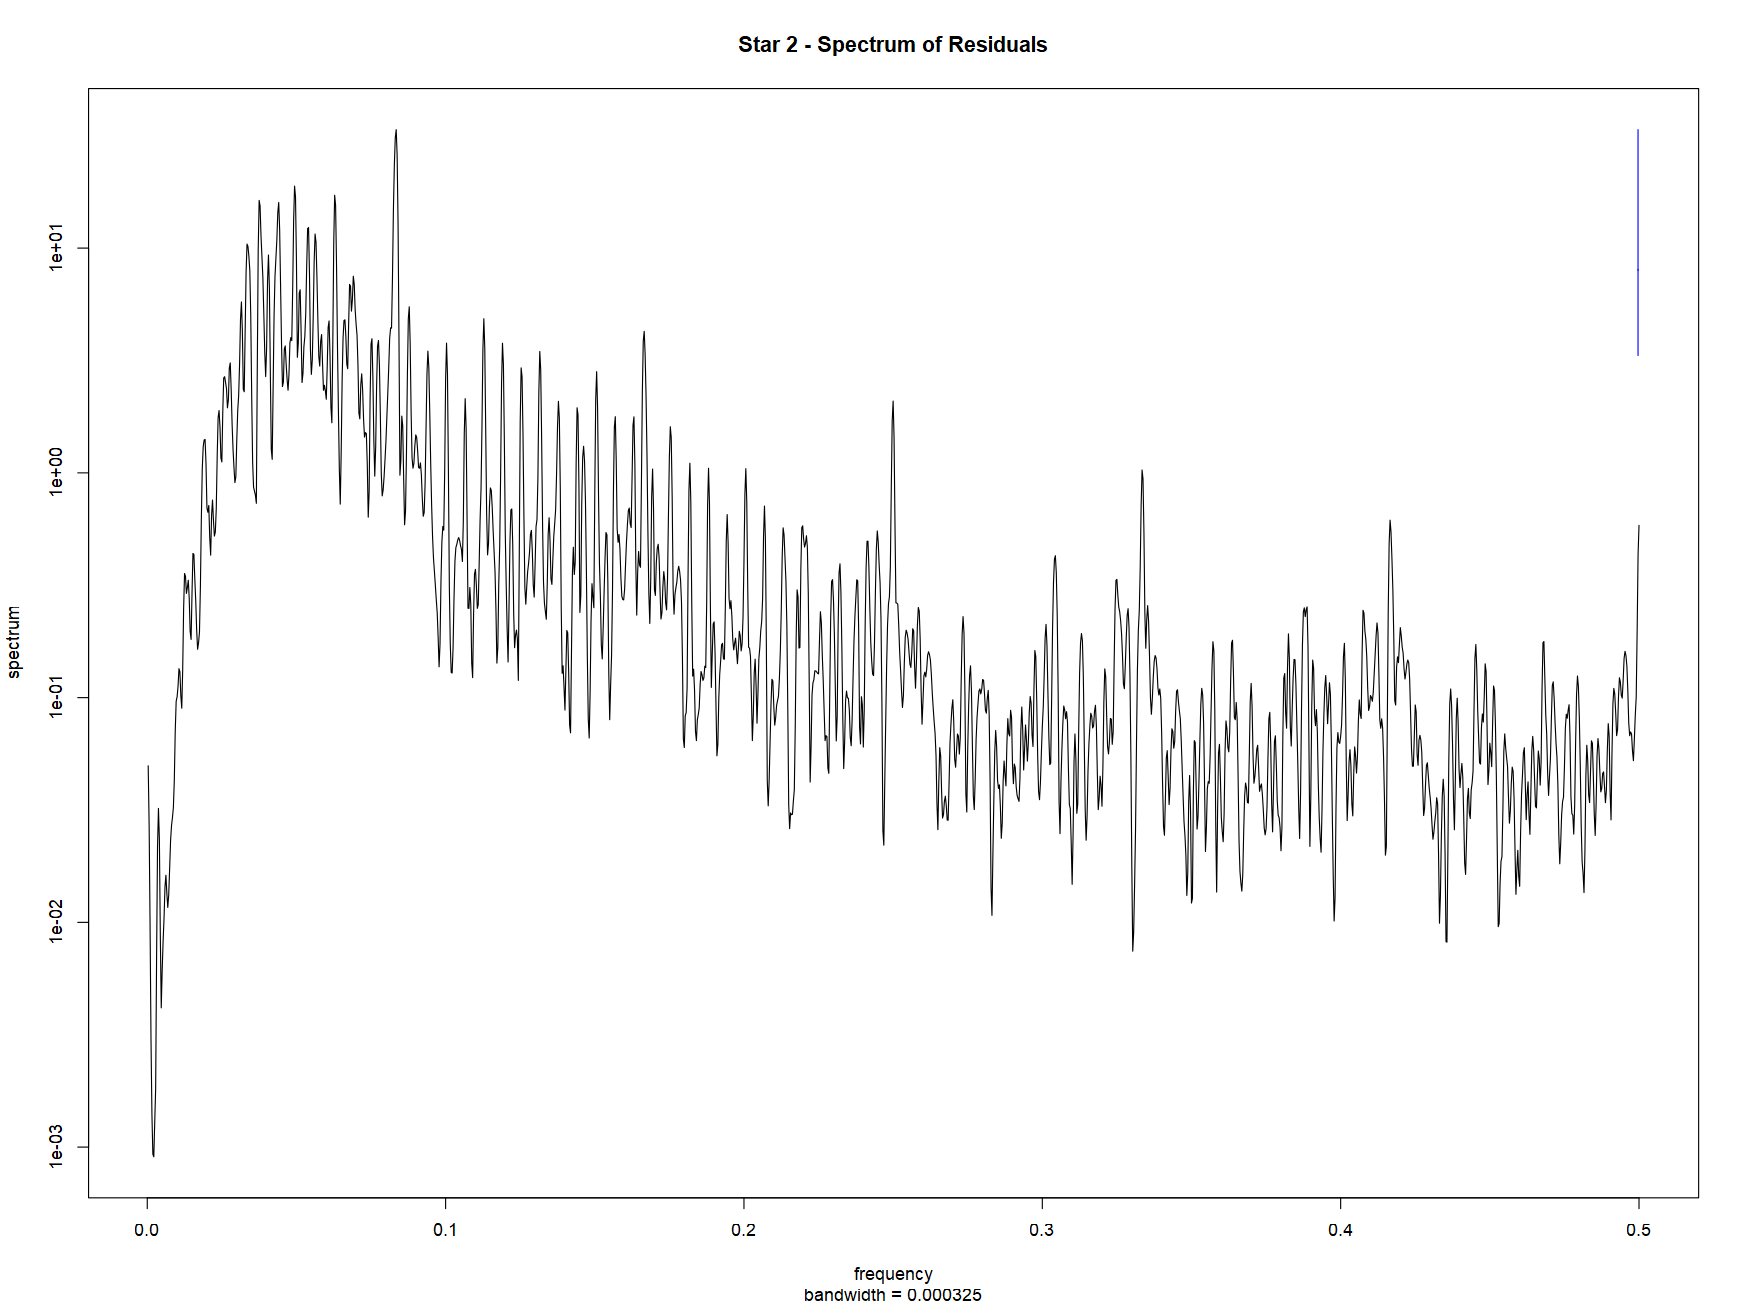

In [10]:
results[[2]] <- list(
  arima = analyze_star_arima(stars[[2]], "Star 2", "Yes", star_ids[2]),
  fourier = analyze_star_fourier(stars[[2]], "Star 2", star_ids[2], "Yes")
)

#### **5.2) Non-Hosting Stars**


ARIMA Analysis for Star 3  ( Row 6 )
Exoplanet Present: No 
ADF p-value: 0.0100 | KPSS p-value: 0.1000
Differencing applied: FALSE 


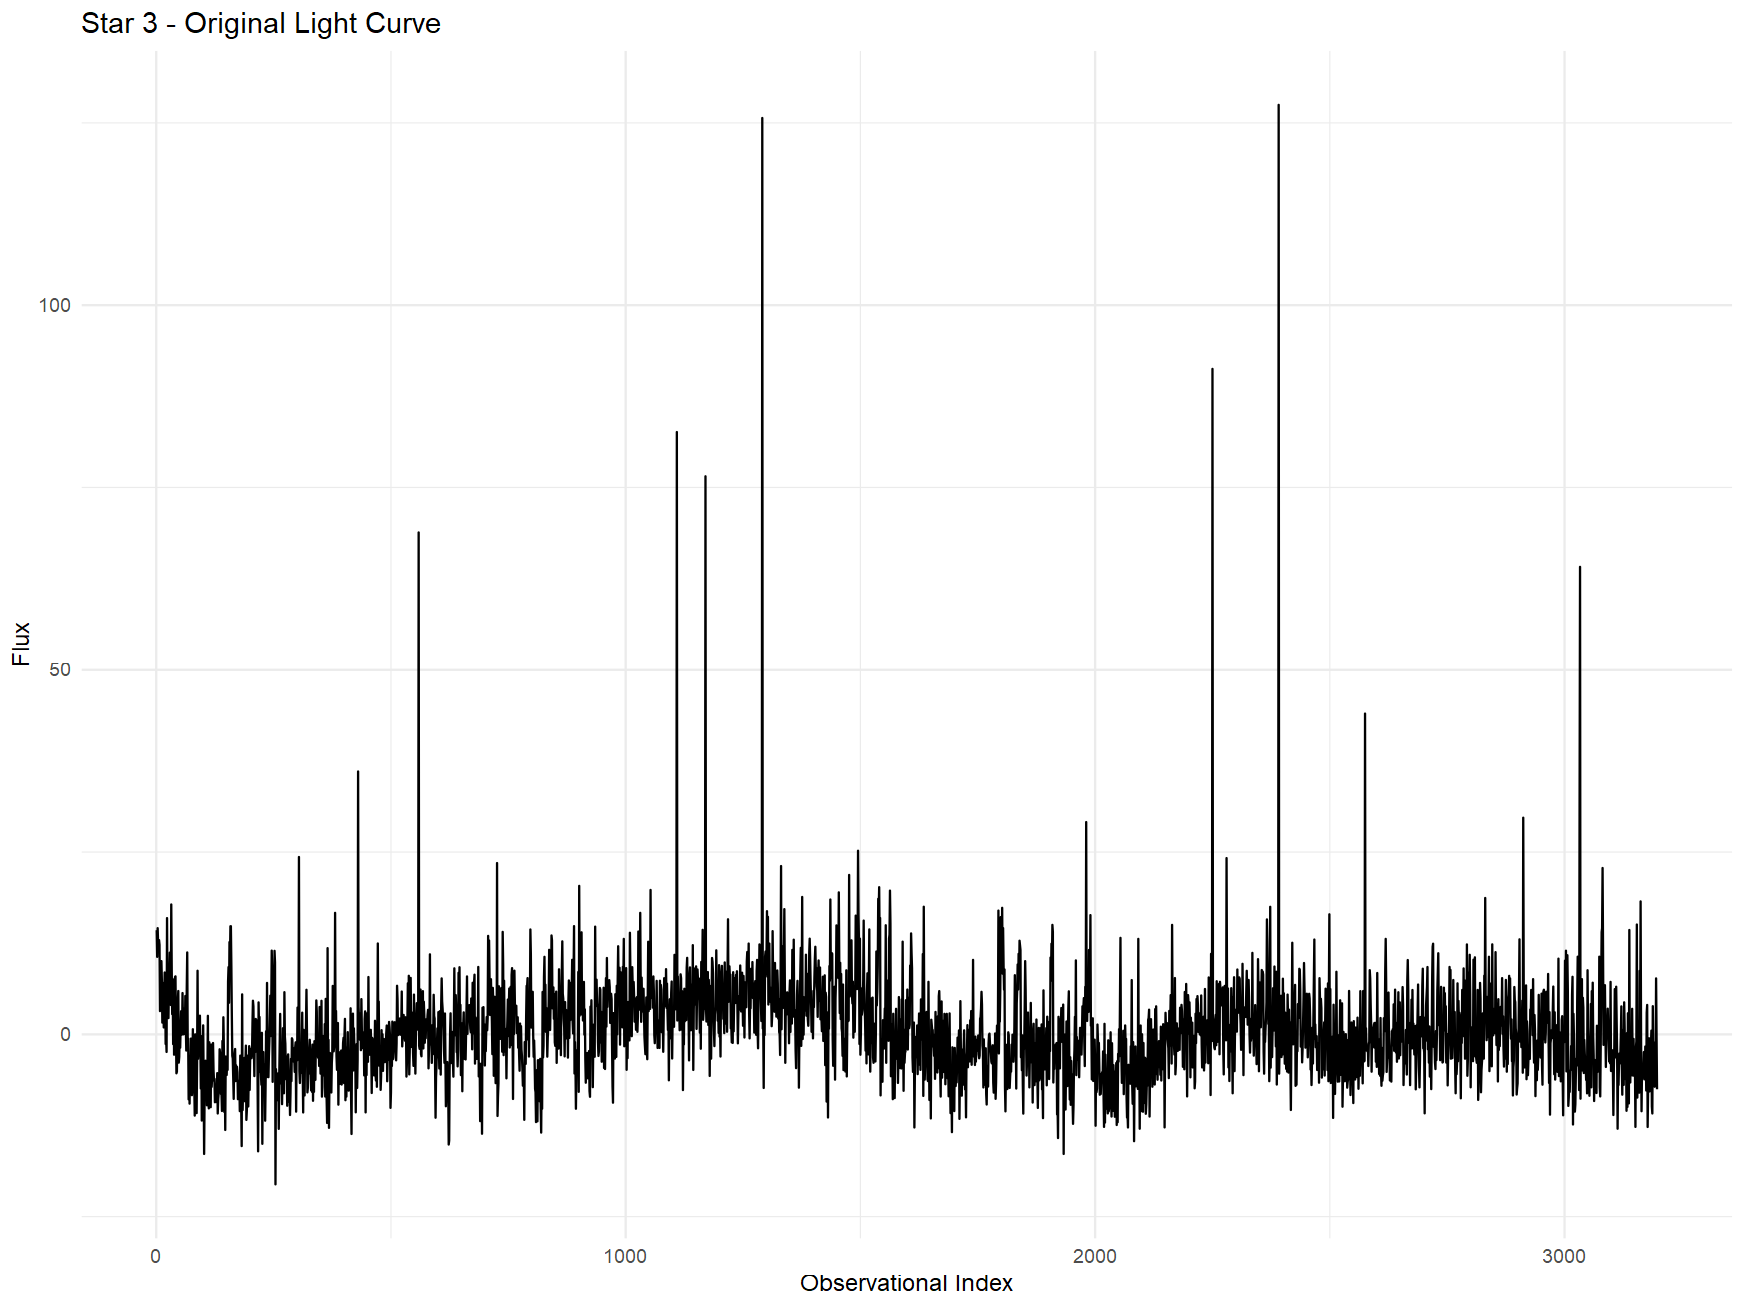

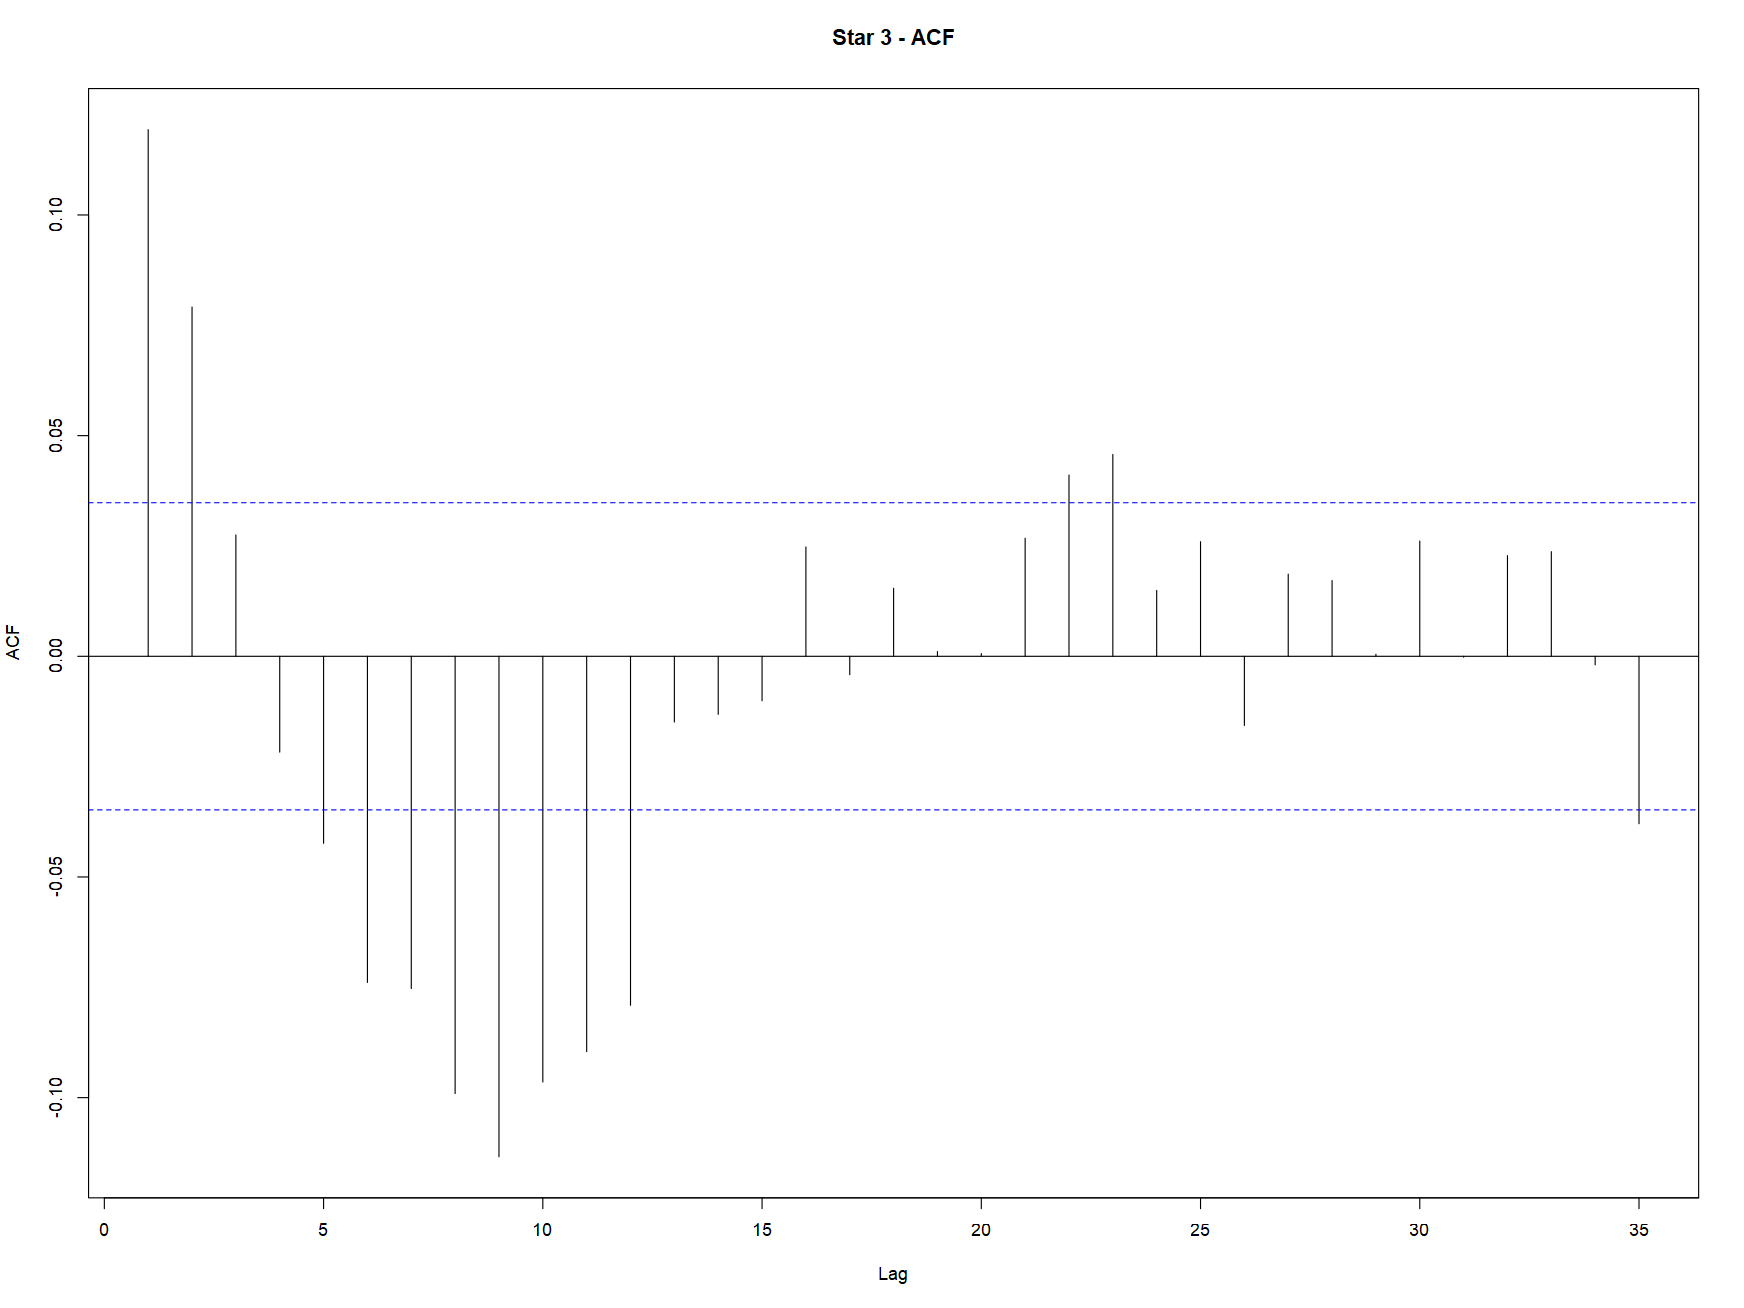

Select ARIMA: 2,0,2 

z test of coefficients:

            Estimate Std. Error  z value  Pr(>|z|)    
ar1        1.7807589  0.0280815   63.414 < 2.2e-16 ***
ar2       -0.8449236  0.0256677  -32.918 < 2.2e-16 ***
ma1       -1.7084590  0.0363438  -47.008 < 2.2e-16 ***
ma2        0.7458205  0.0348386   21.408 < 2.2e-16 ***
intercept  2.9841512  0.0027457 1086.841 < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



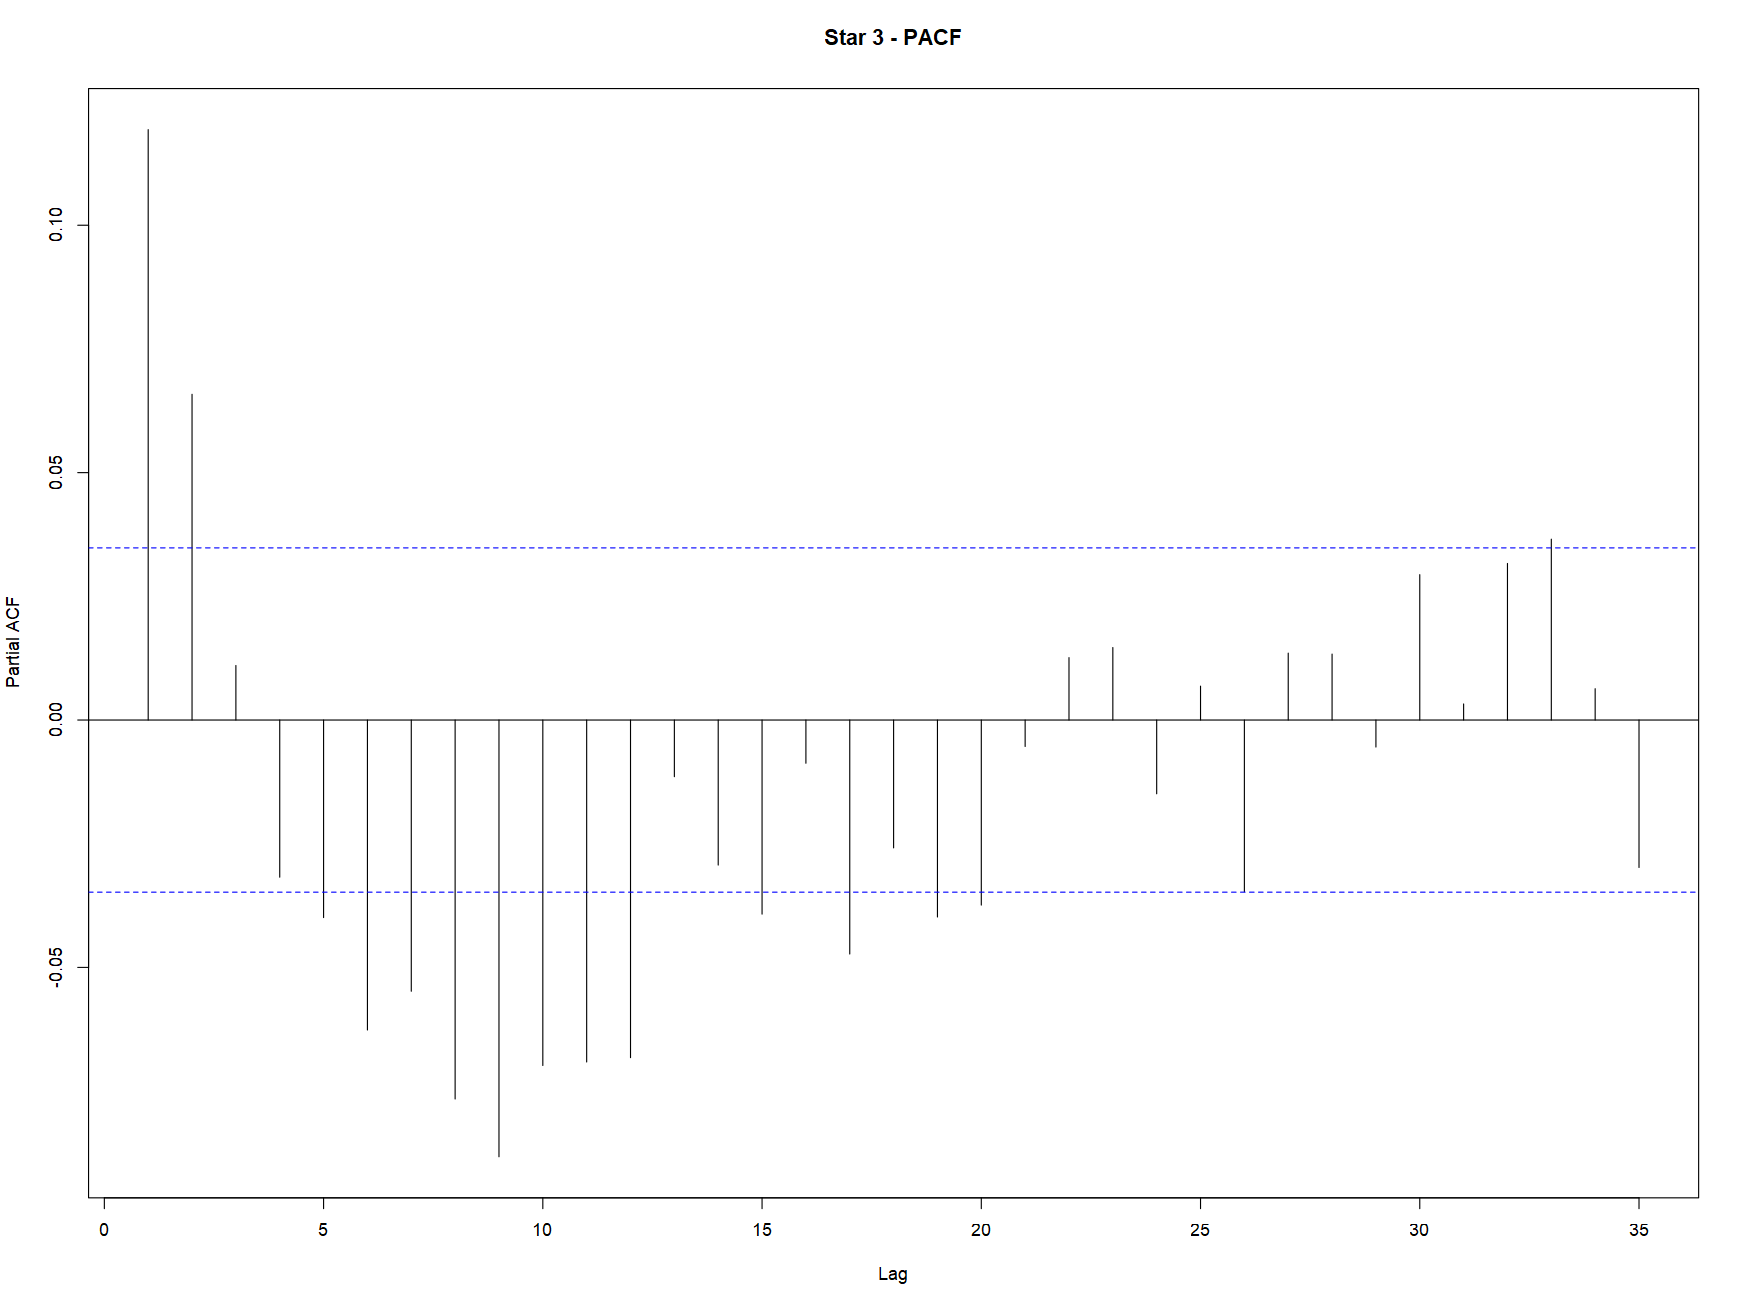

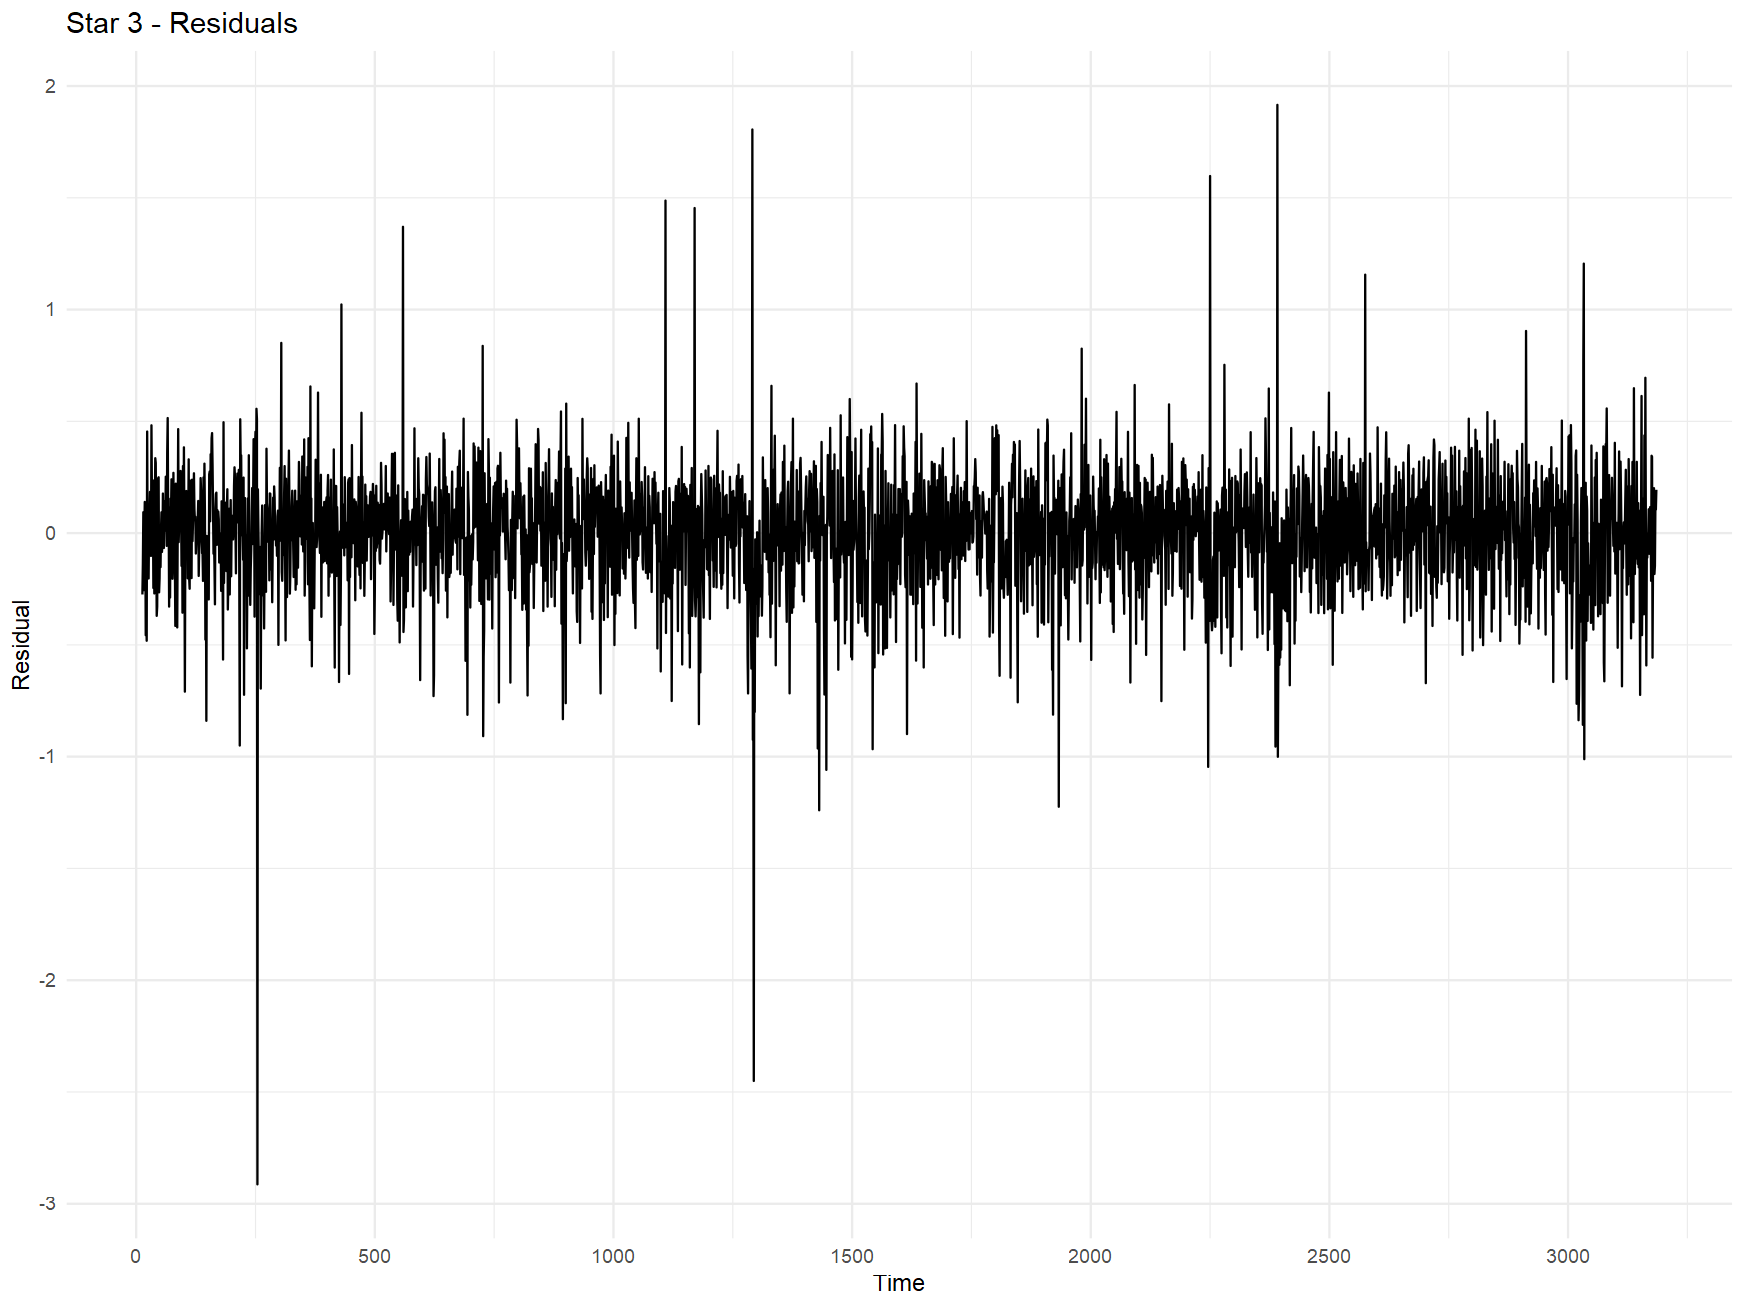

Ljung-Box p-value (lag 20, fitdf=4): 0.5052


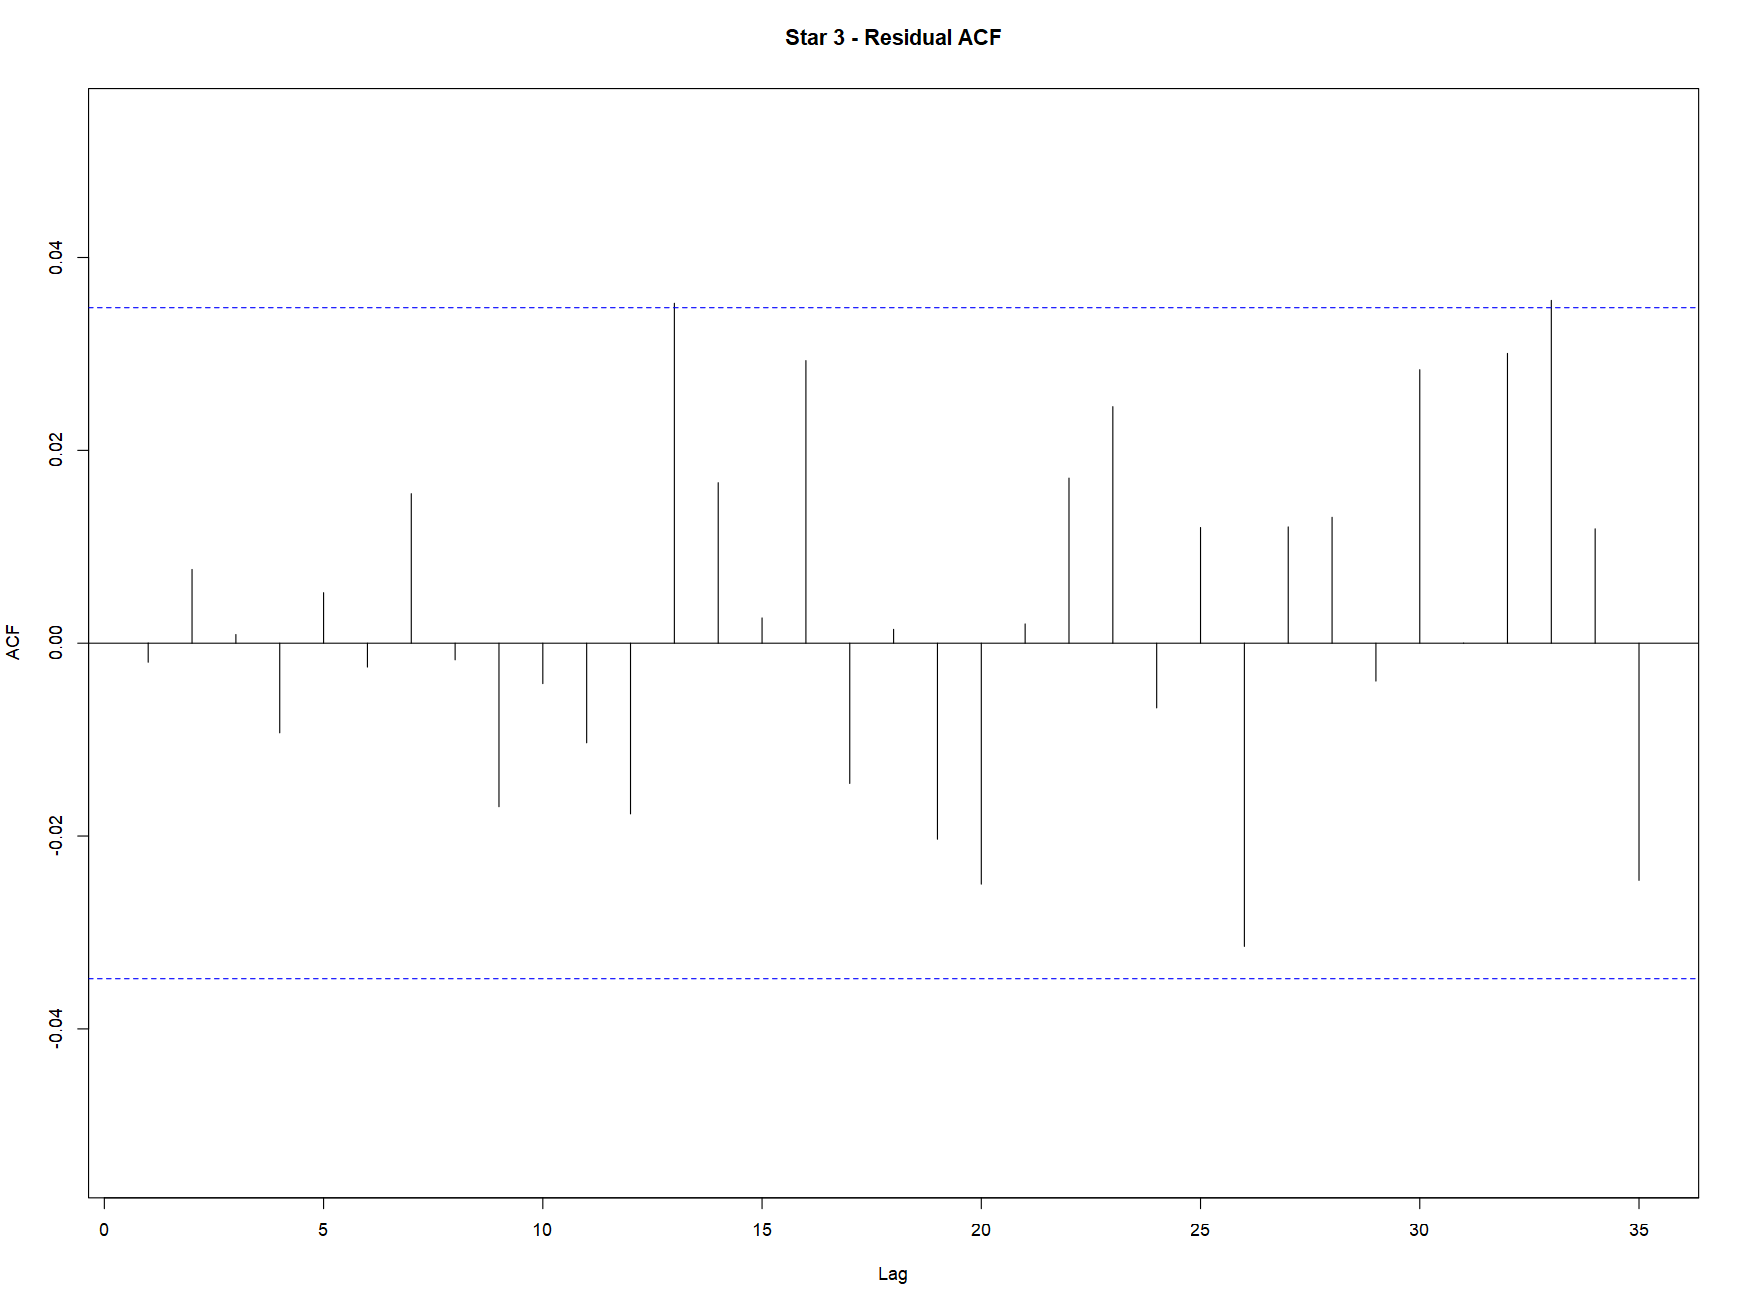

Flagged points: 0 | Events: 0 
Events after edge guard: 0 


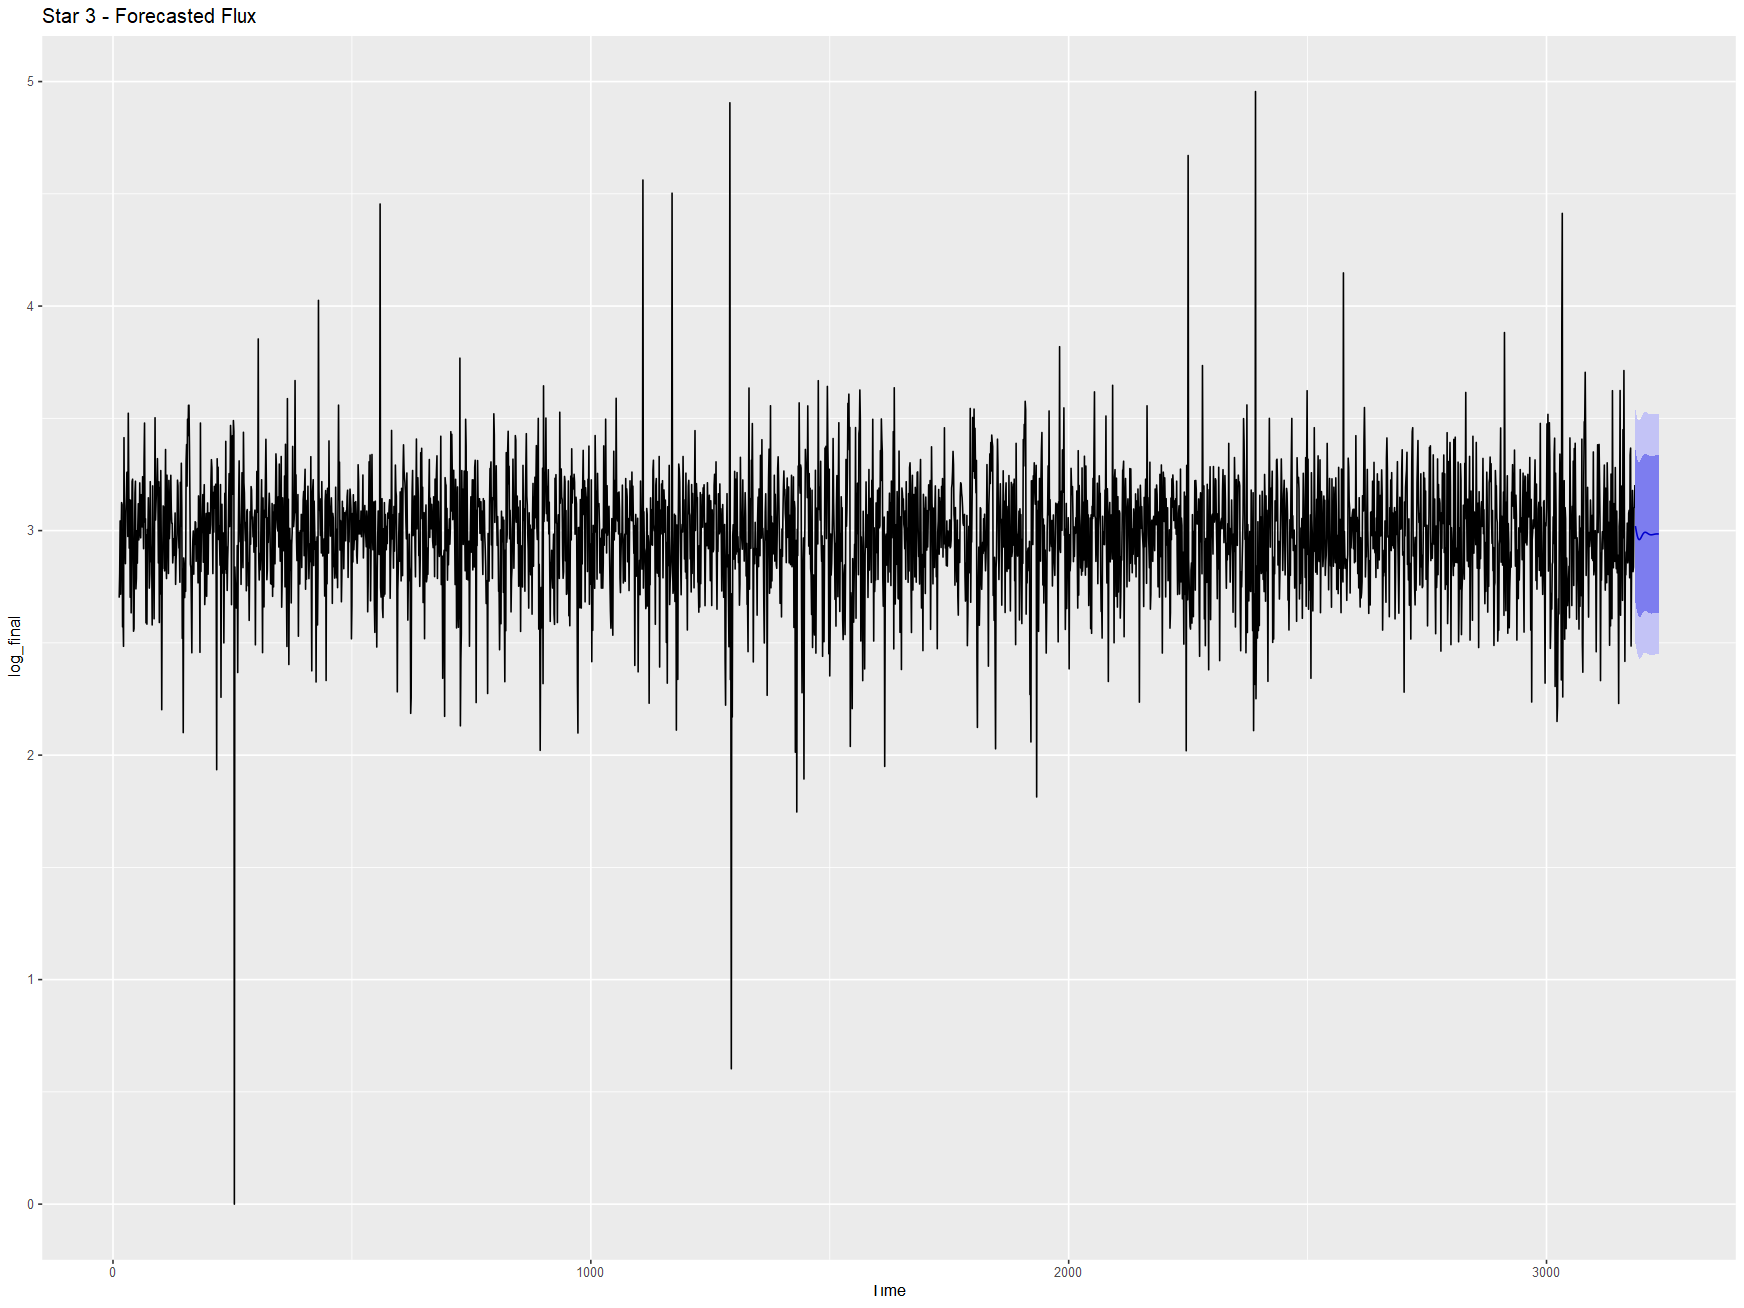

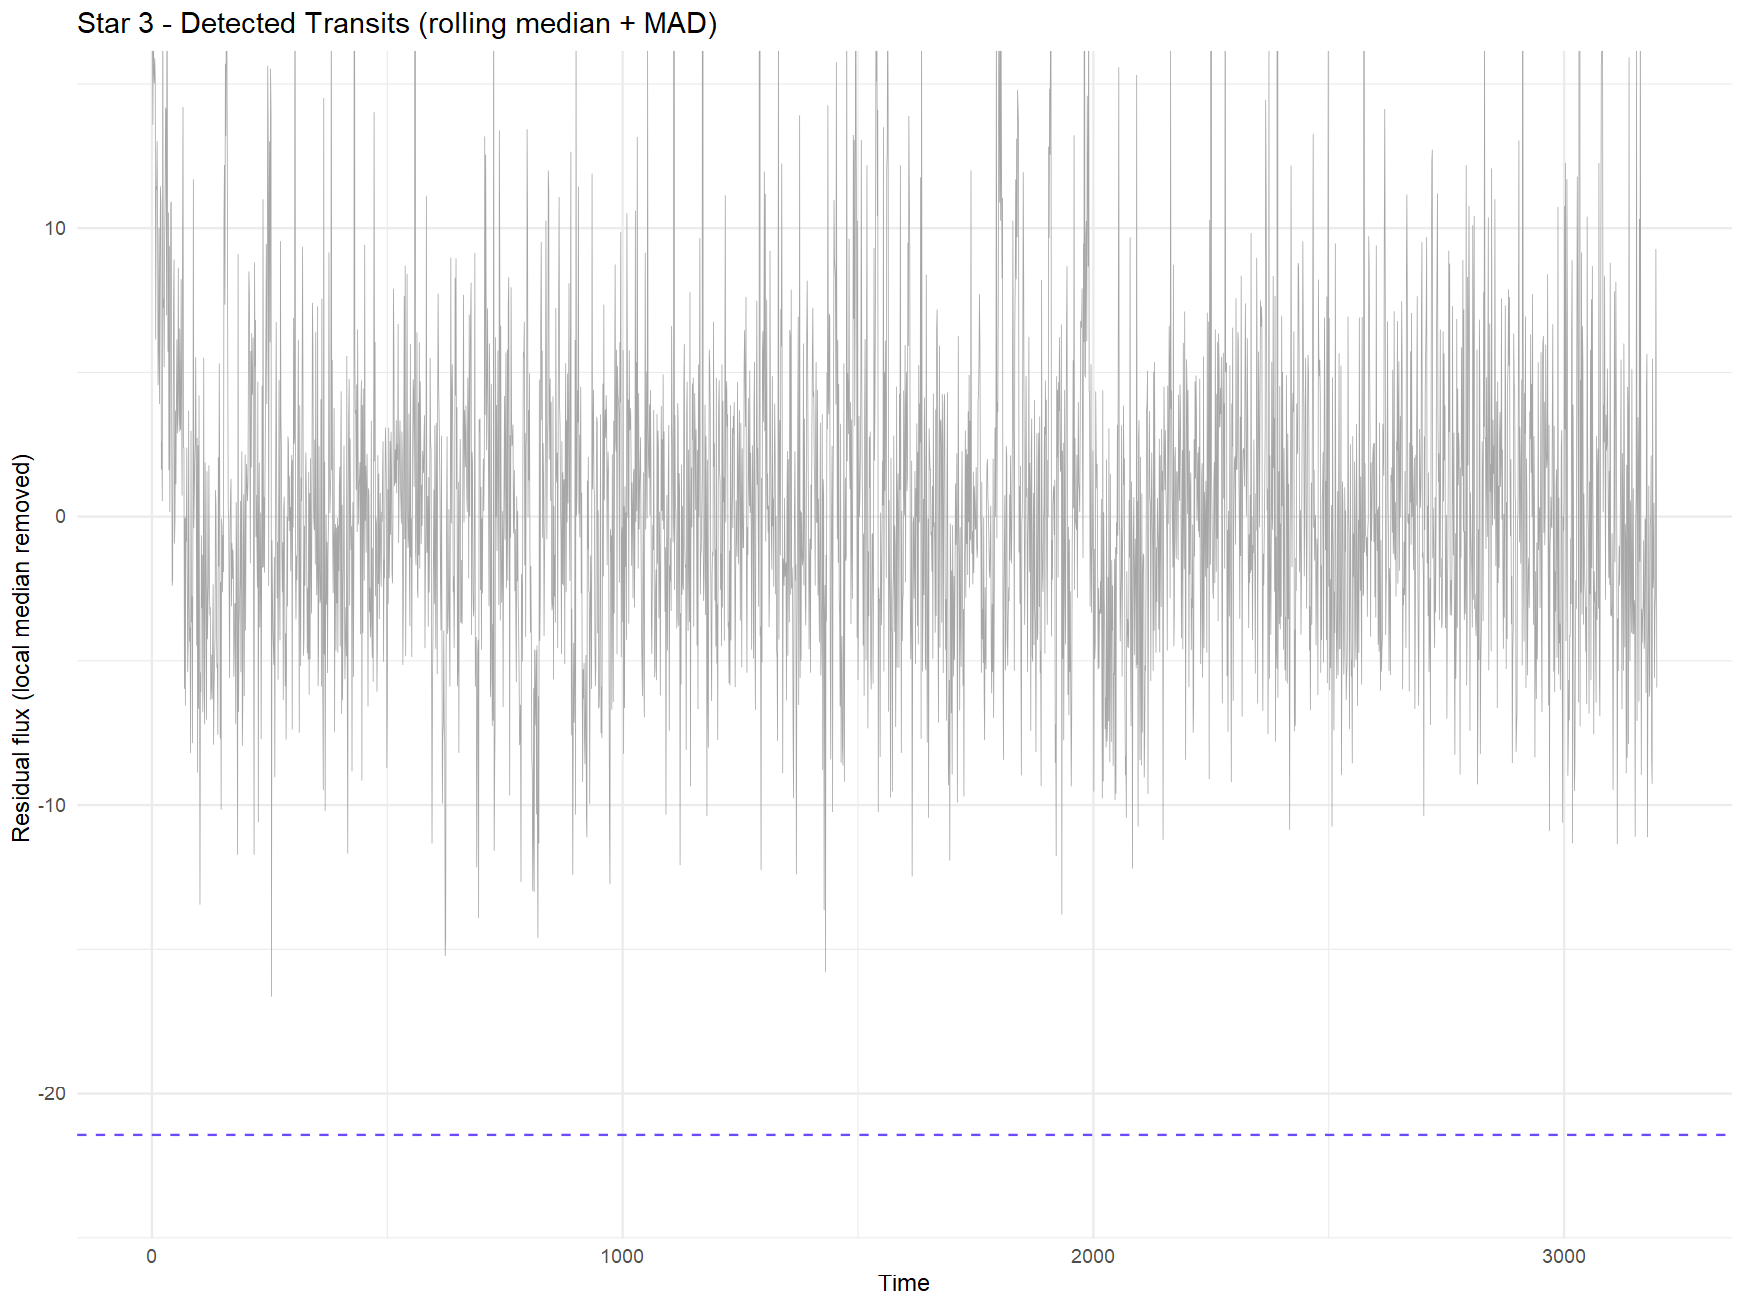


Fourier Analysis of Star 3  ( Row 6 )
Exoplanet Present: No 
AIC values by K: 9079.67 9083.04 9085.04 9088.5 9090.47 9090.83 
Estimated Period: 103.23  | Chosen Harmonics (K): 1 


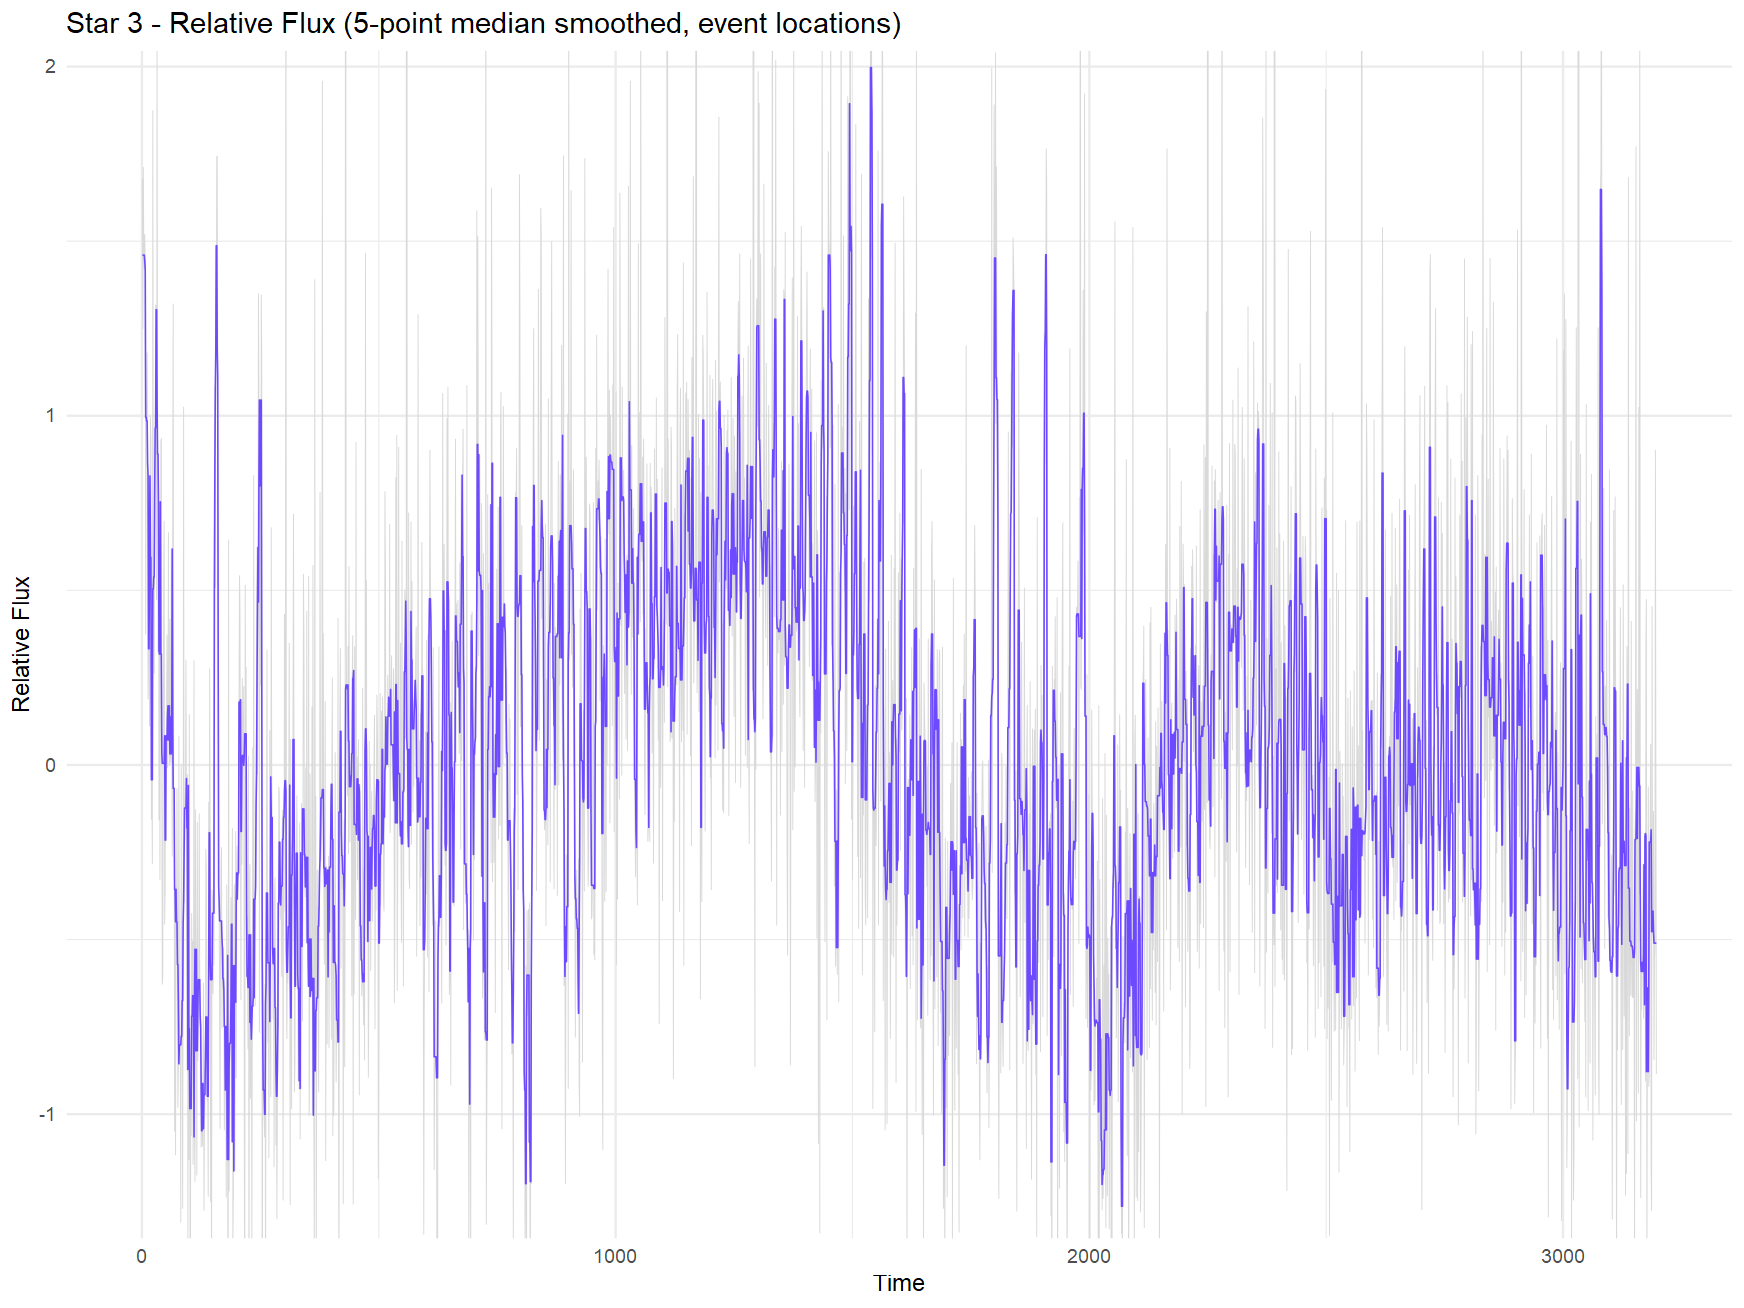

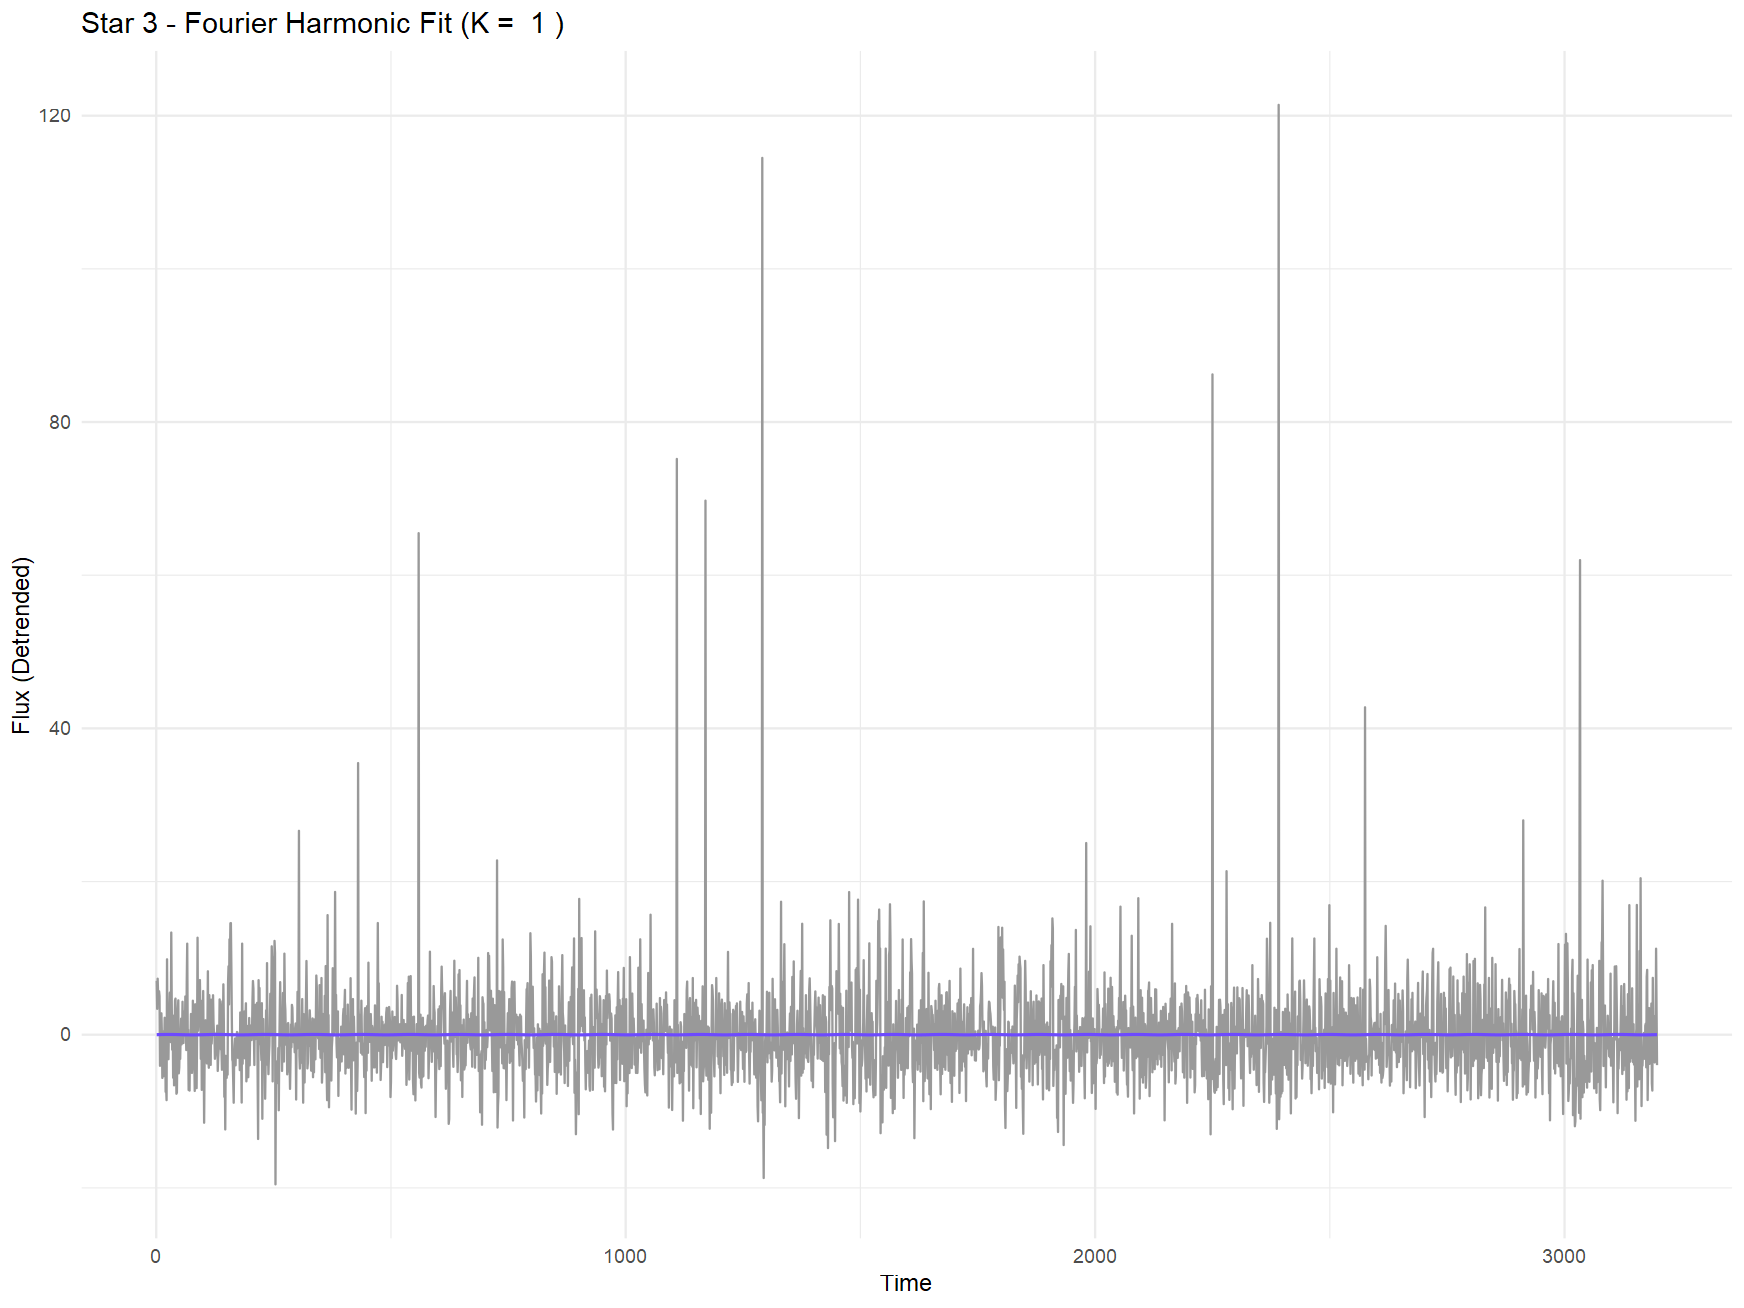

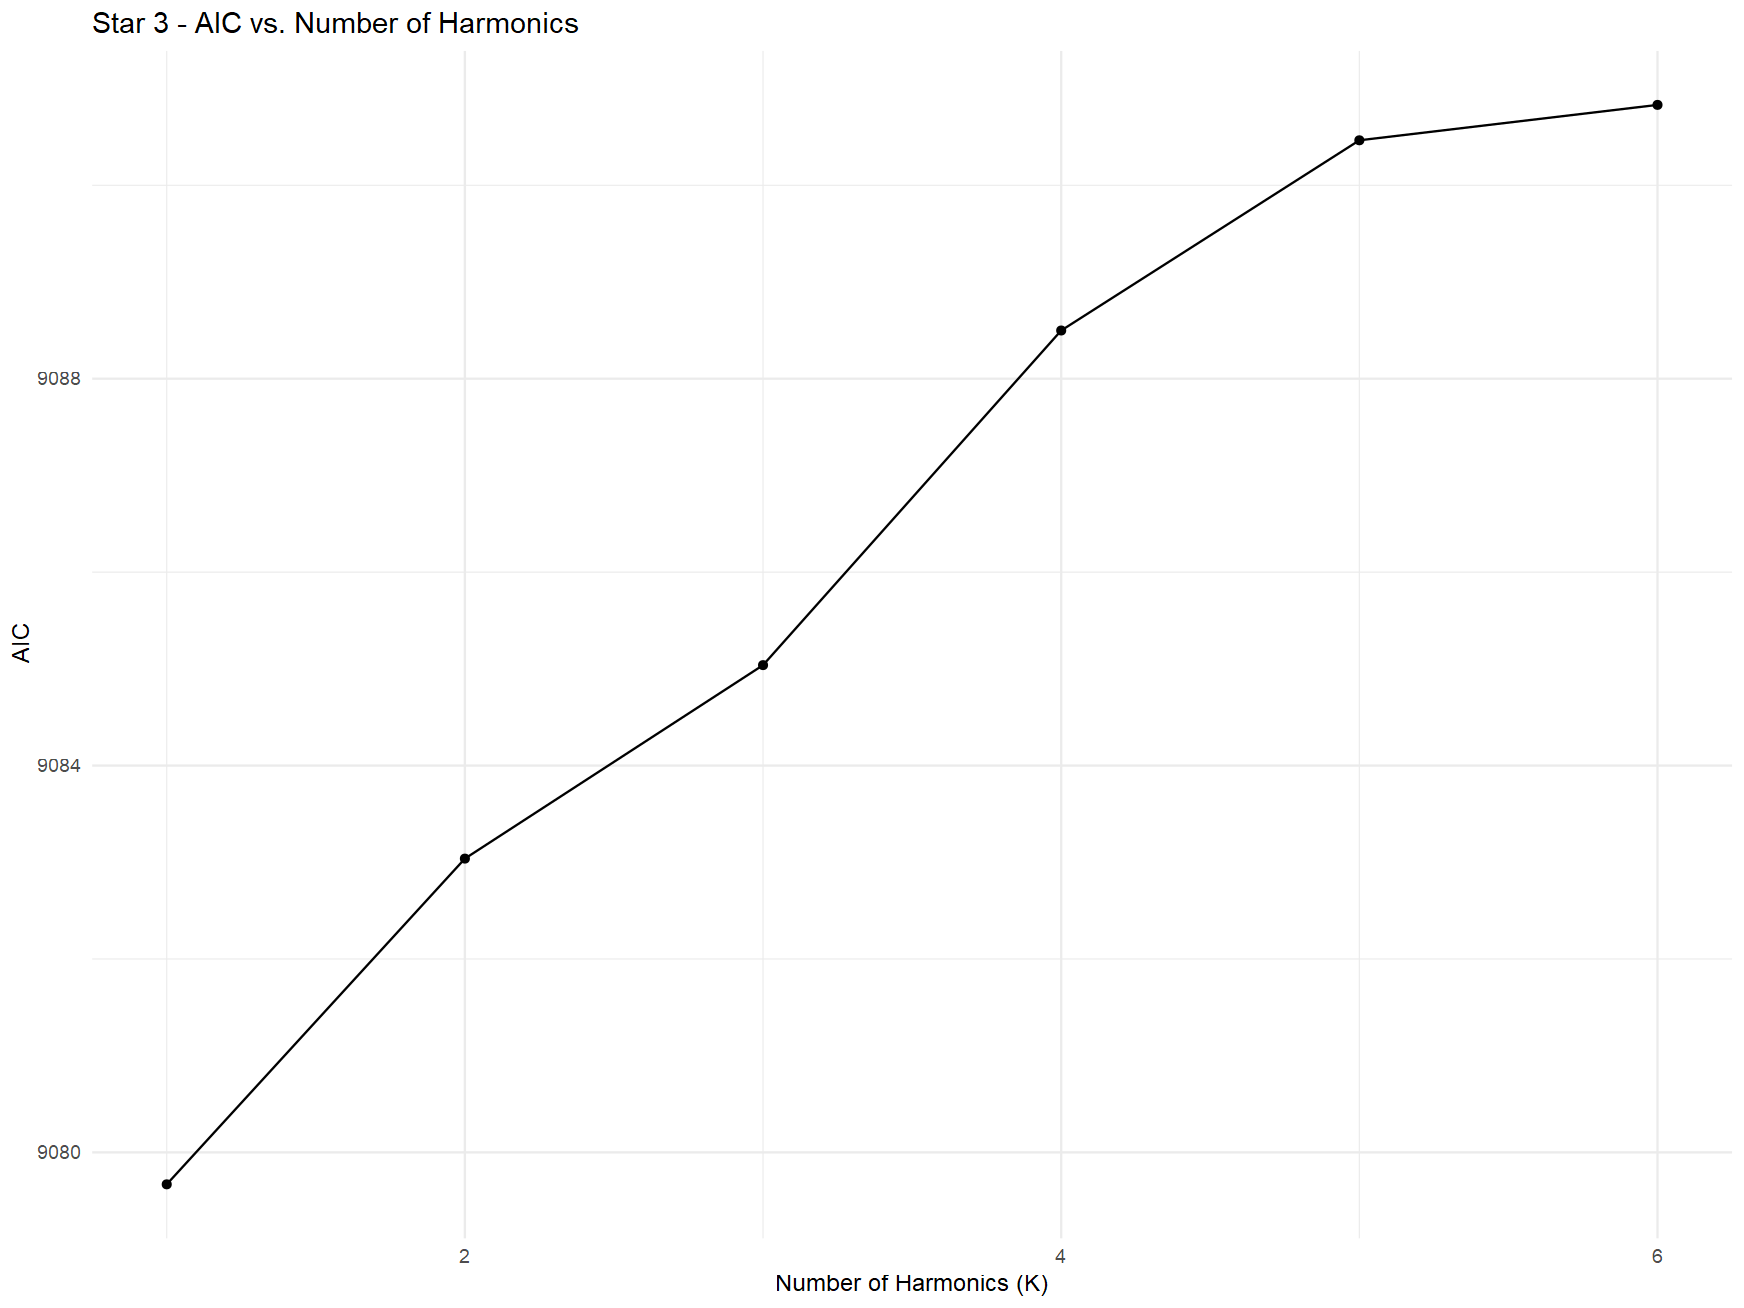

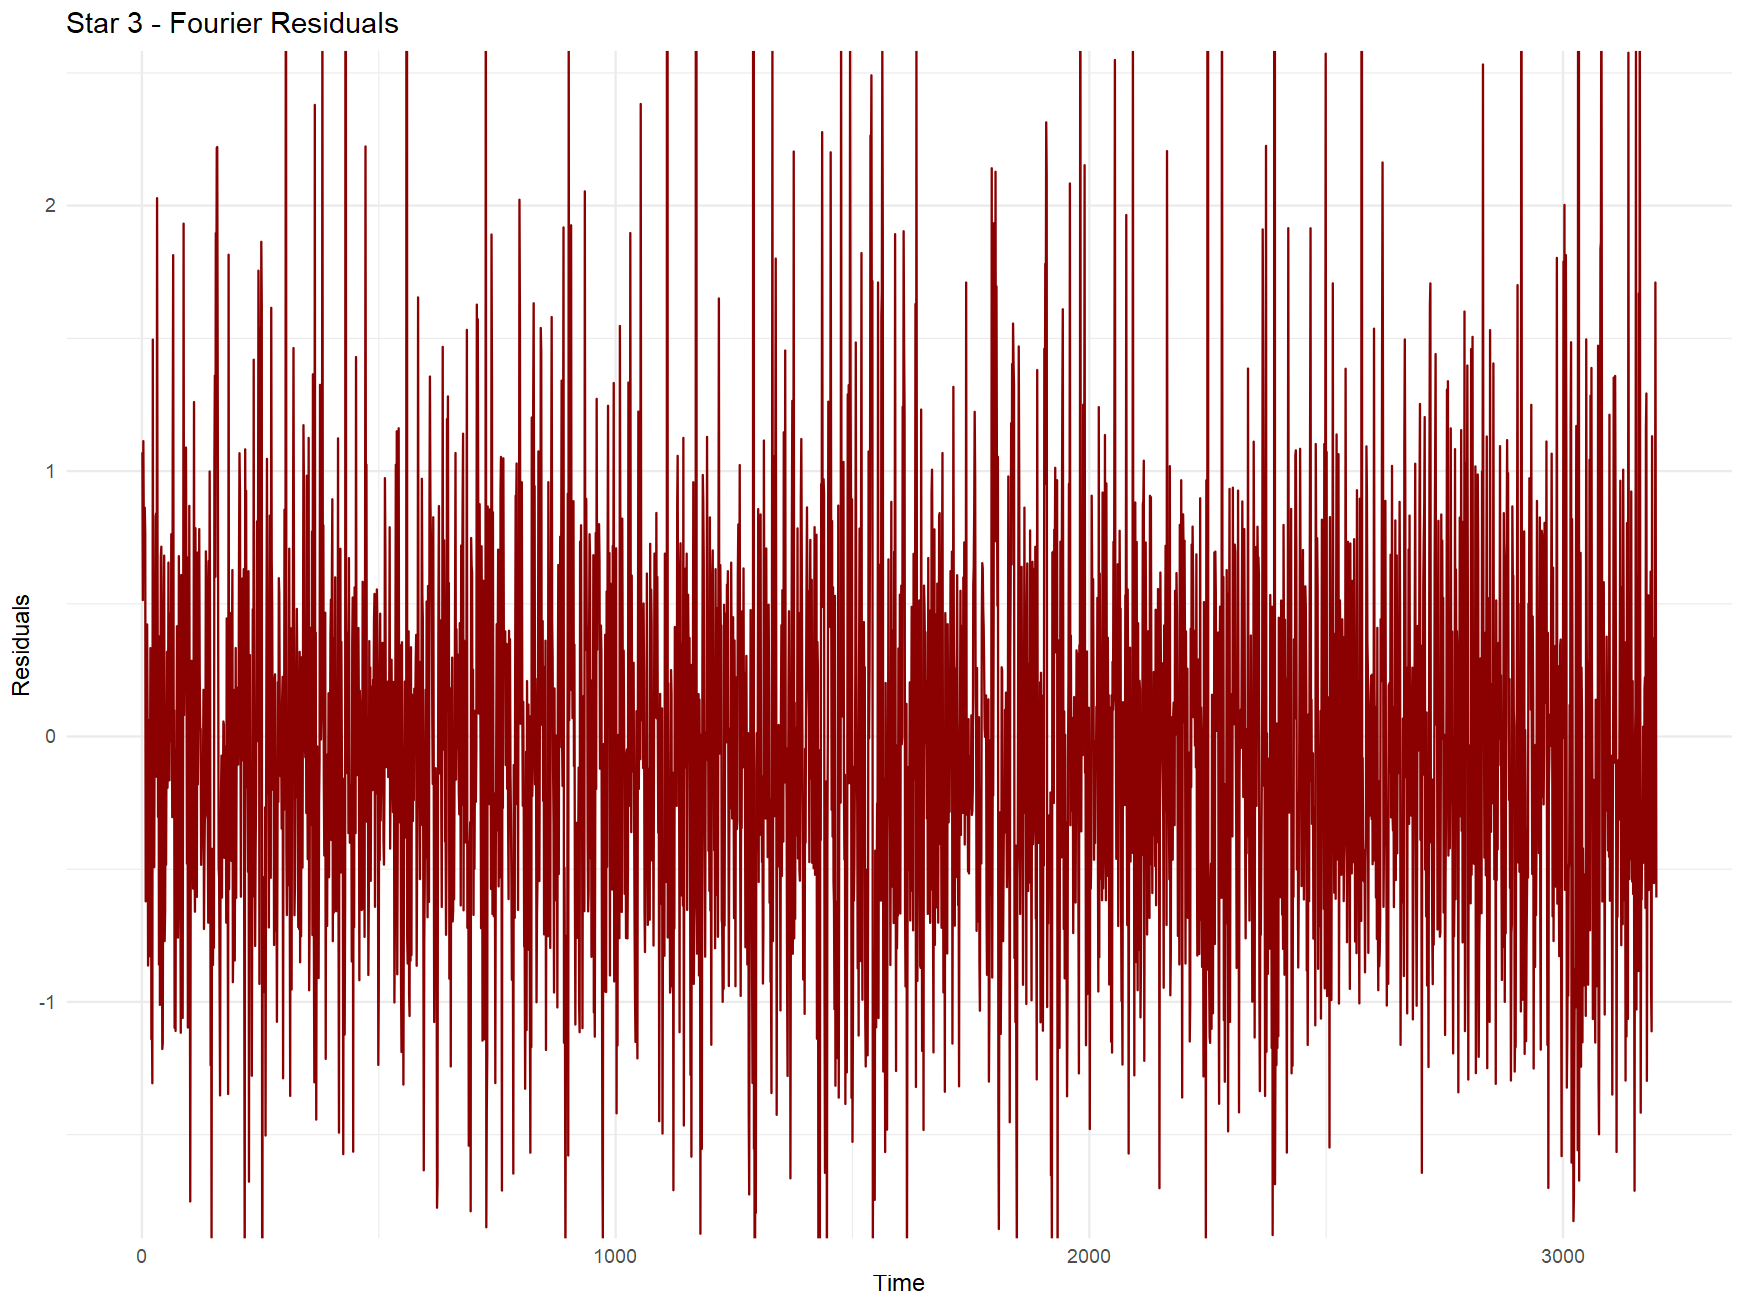

Warning messages:
1: In adfTest(log_ts, type = "ct") : p-value smaller than printed p-value
2: In kpss.test(log_ts, null = "Level") :
  p-value greater than printed p-value


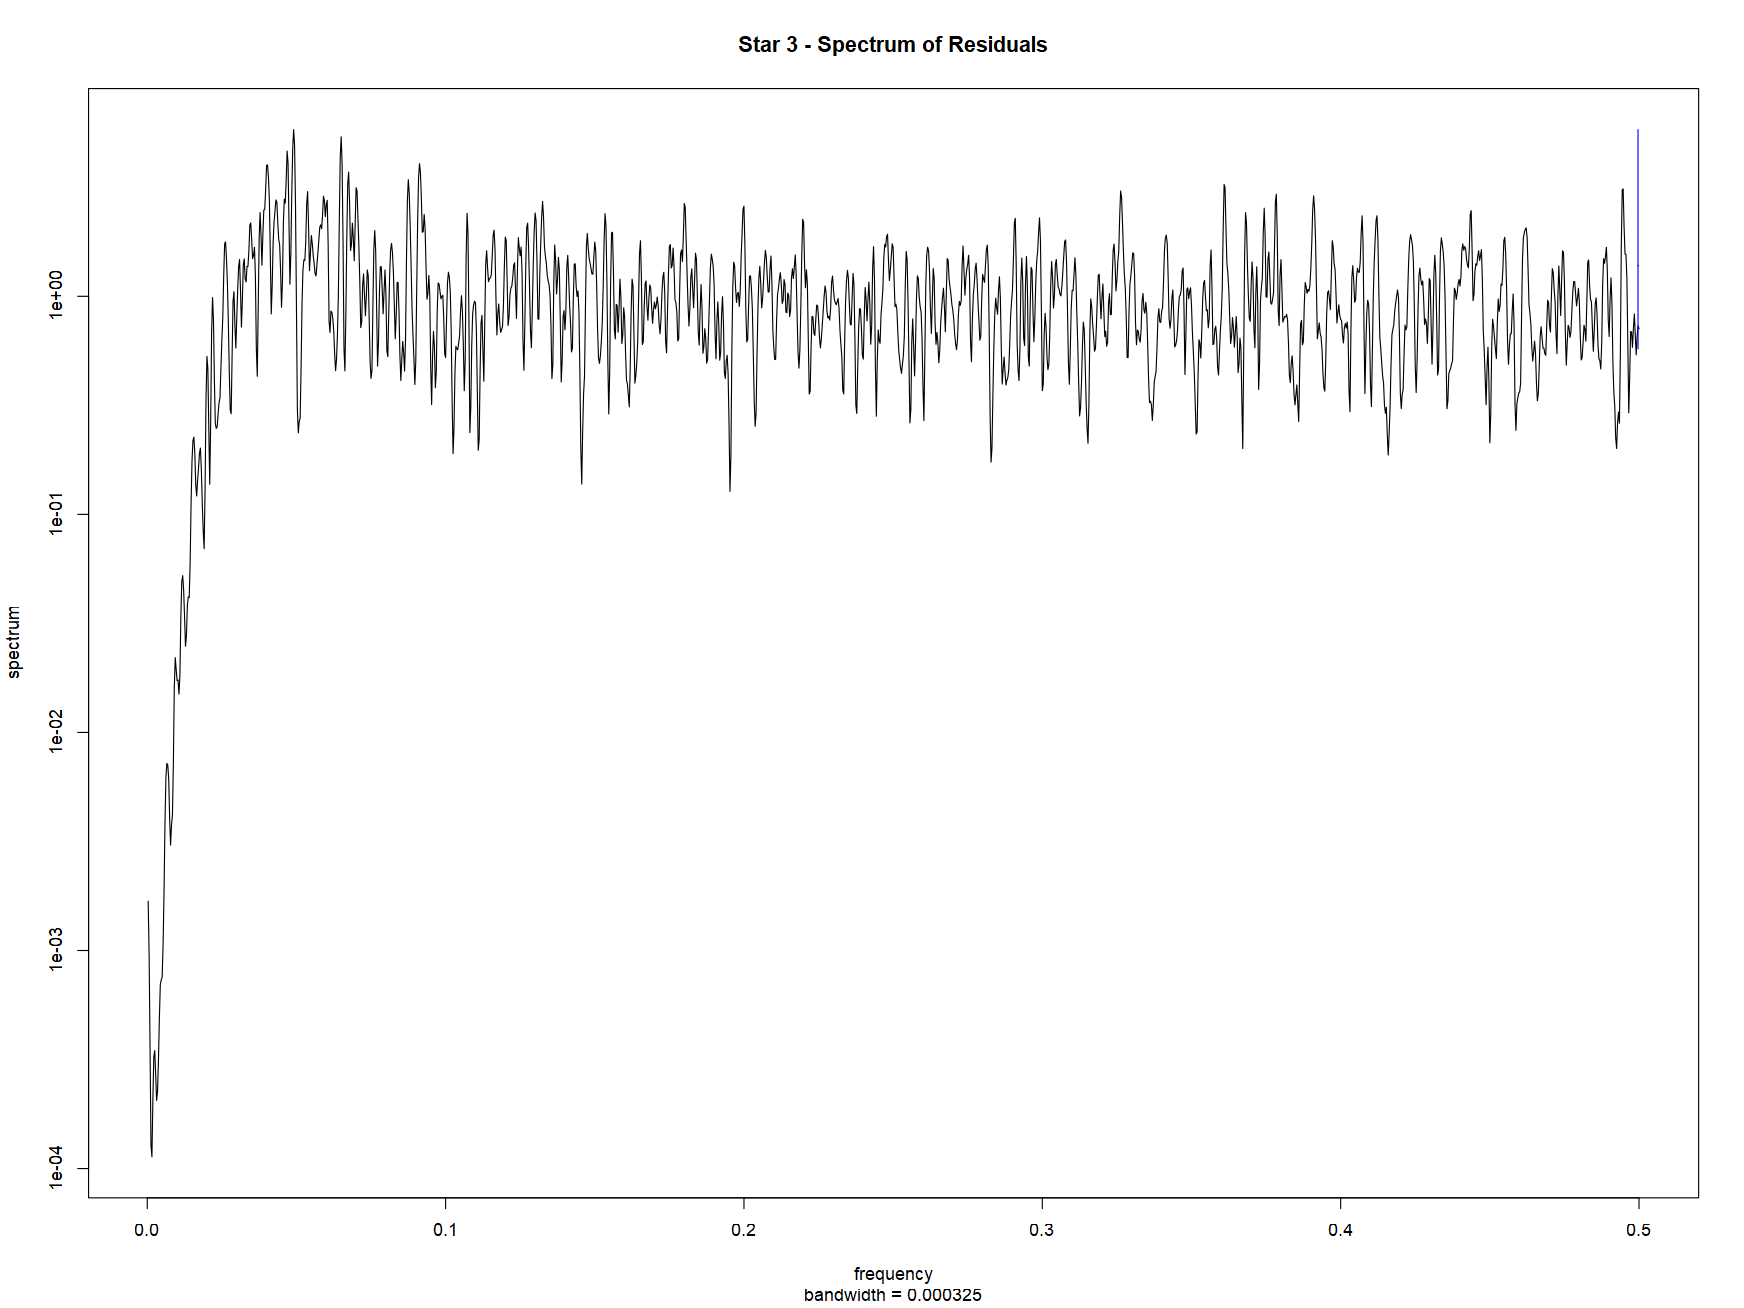

In [11]:
results[[3]] <- list(
  arima = analyze_star_arima(stars[[3]], "Star 3", "No", star_ids[3]),
  fourier = analyze_star_fourier(stars[[3]], "Star 3", star_ids[3], "No")
)


ARIMA Analysis for Star 4  ( Row 7 )
Exoplanet Present: No 
ADF p-value: 0.0100 | KPSS p-value: 0.1000
Differencing applied: FALSE 


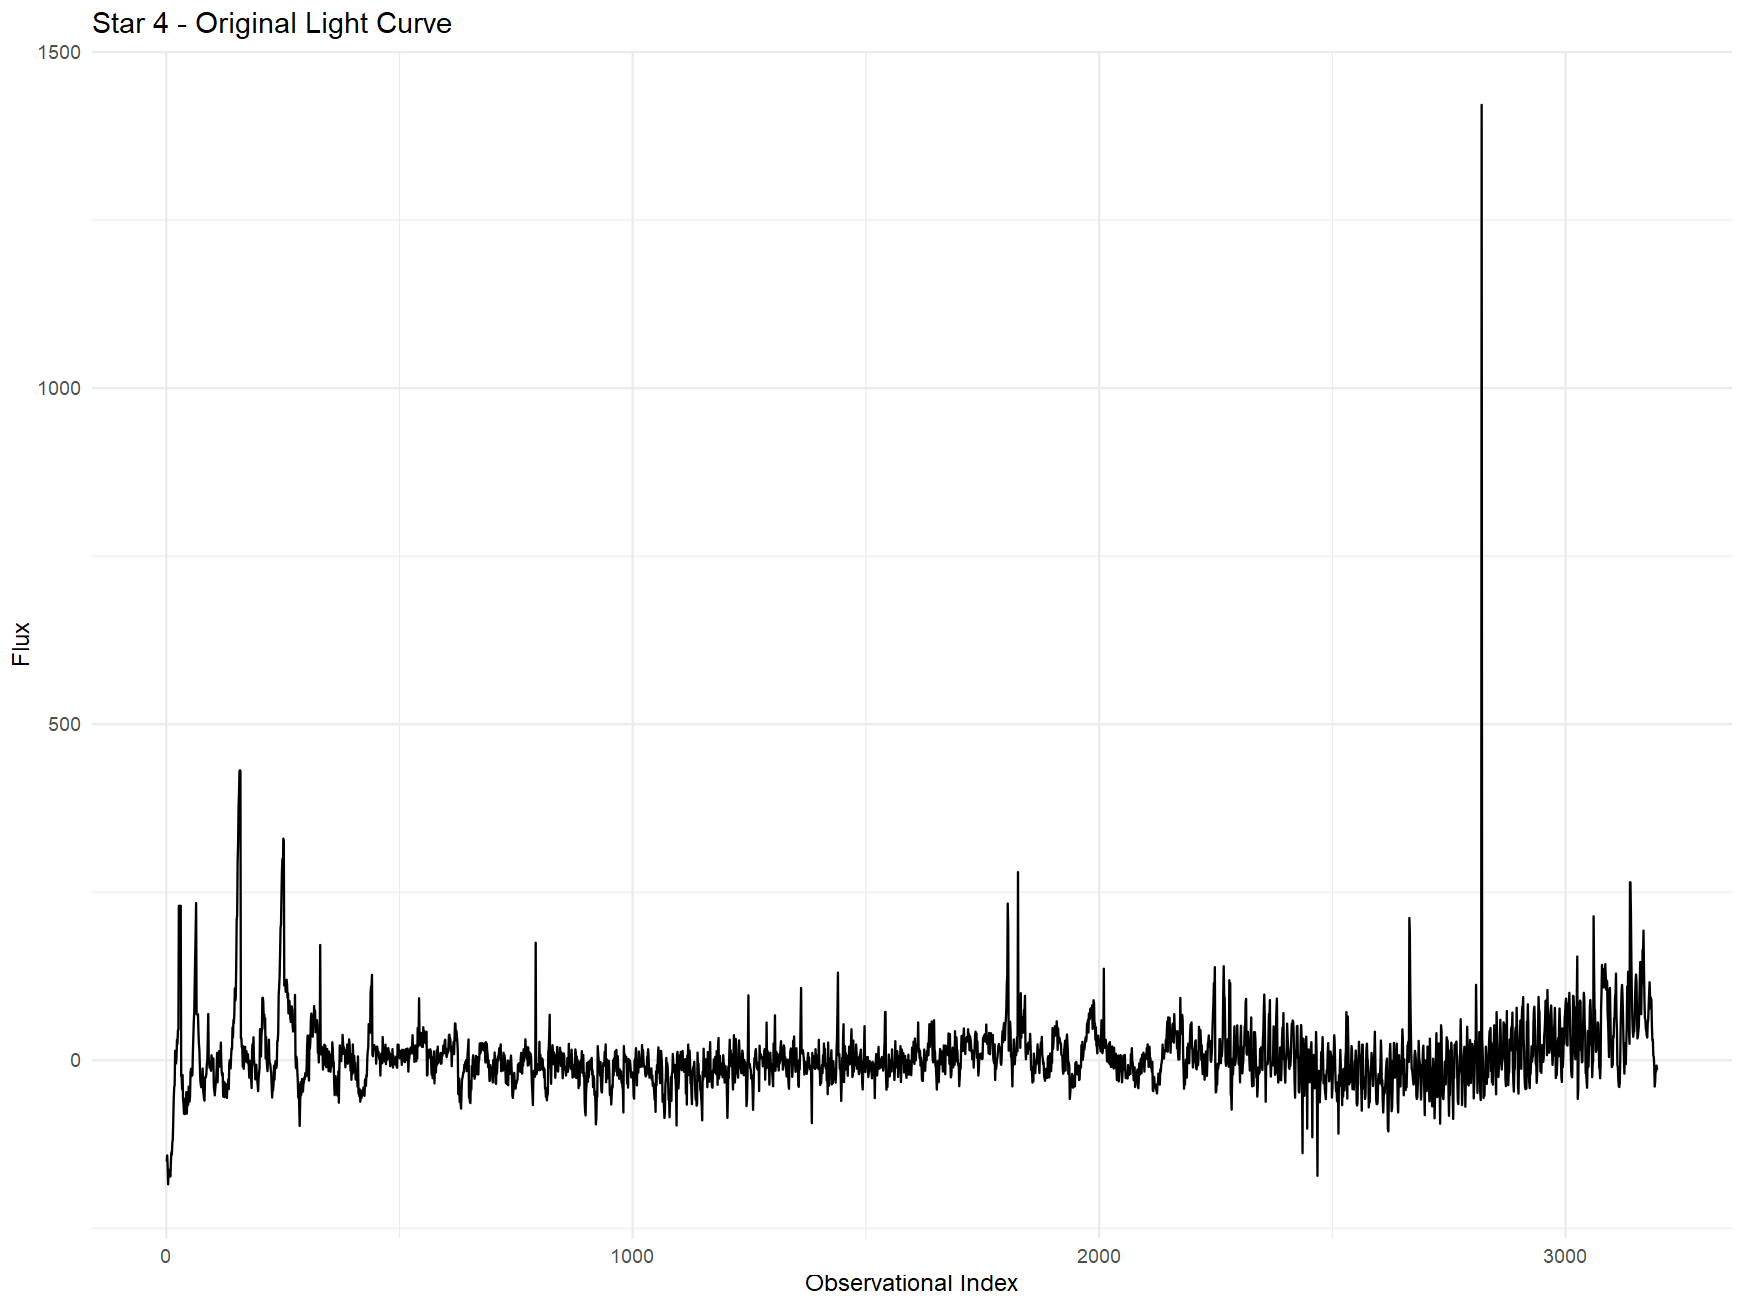

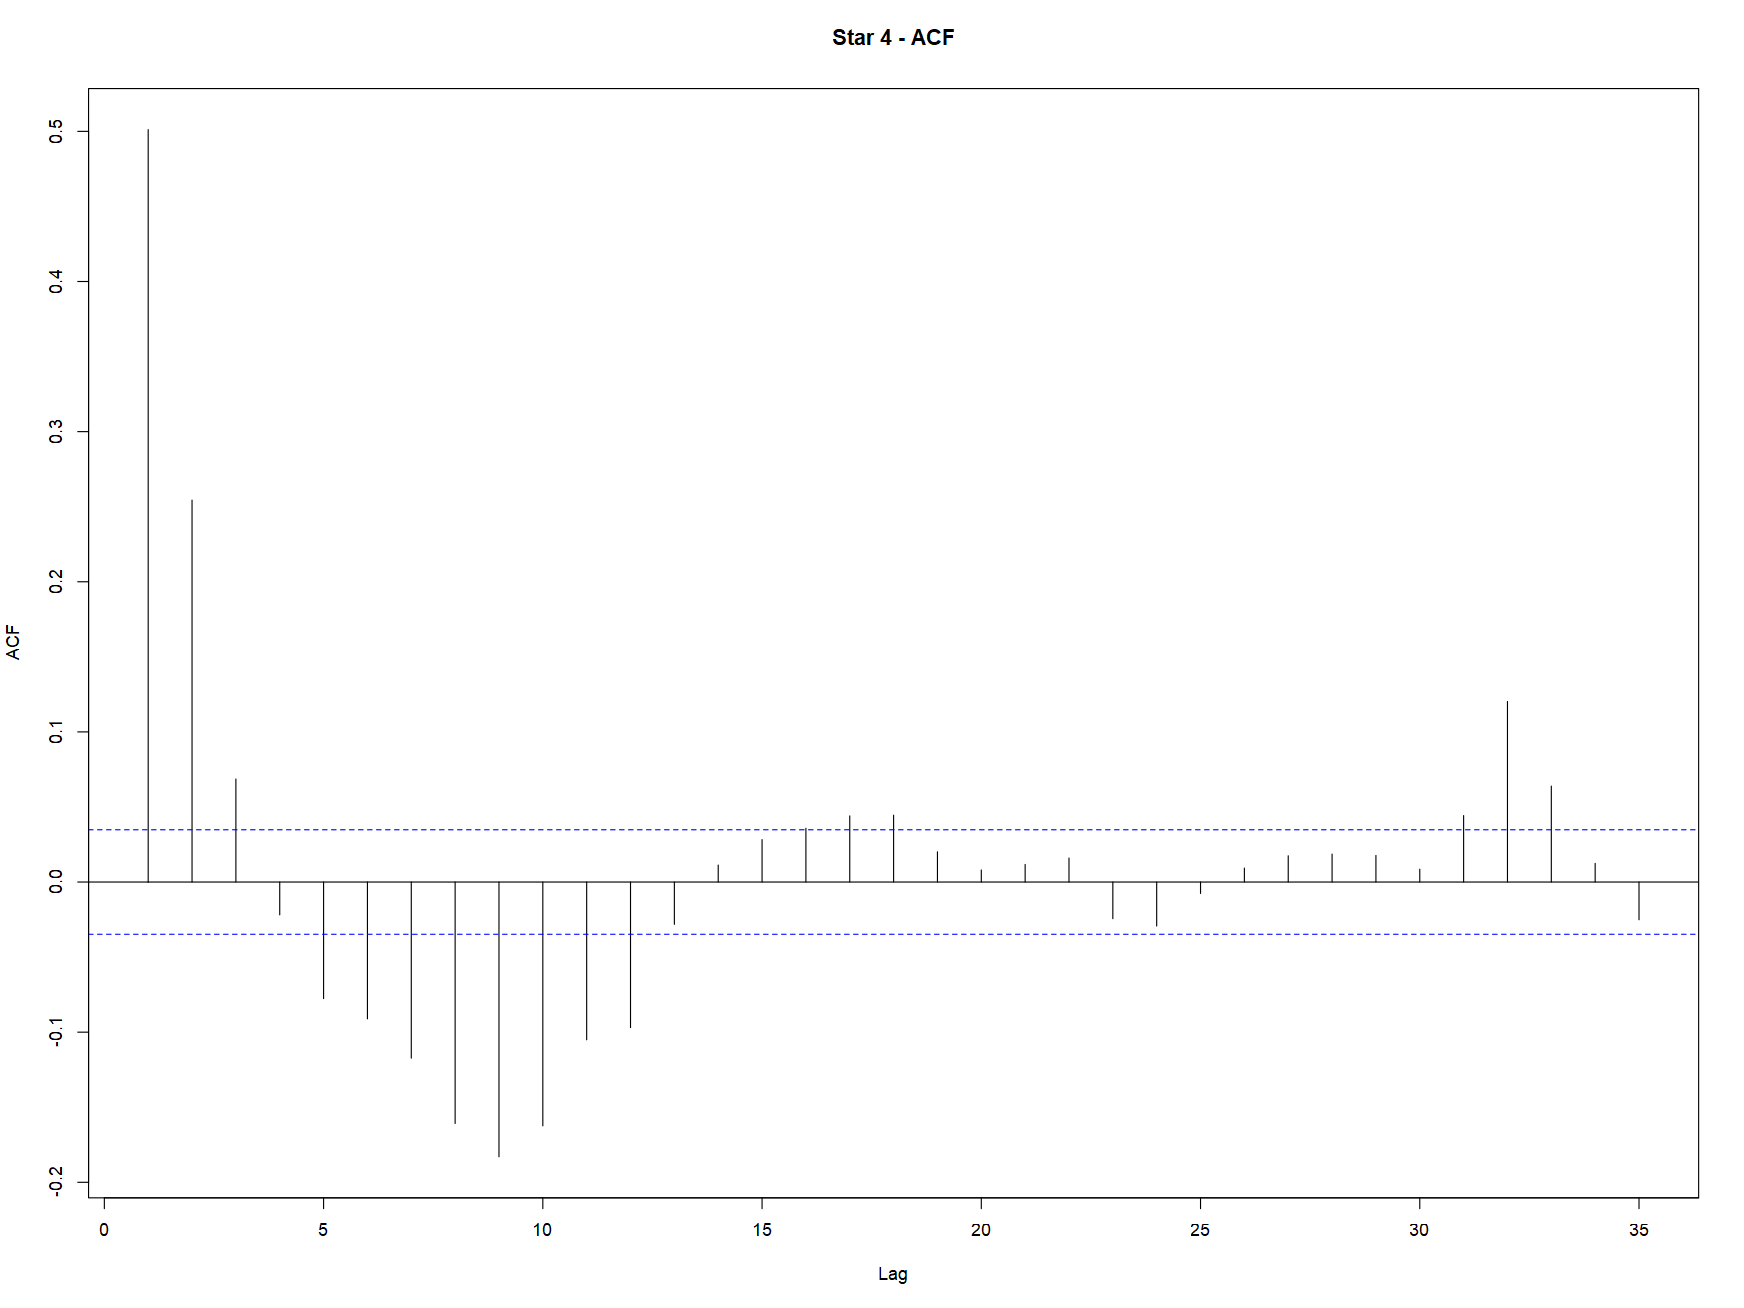

Select ARIMA: 3,0,1 

z test of coefficients:

            Estimate Std. Error   z value  Pr(>|z|)    
ar1        1.3532803  0.0268035   50.4889 < 2.2e-16 ***
ar2       -0.3826126  0.0317441  -12.0530 < 2.2e-16 ***
ar3       -0.0819979  0.0184917   -4.4343 9.237e-06 ***
ma1       -0.8752463  0.0206730  -42.3376 < 2.2e-16 ***
intercept  4.9994292  0.0042381 1179.6449 < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



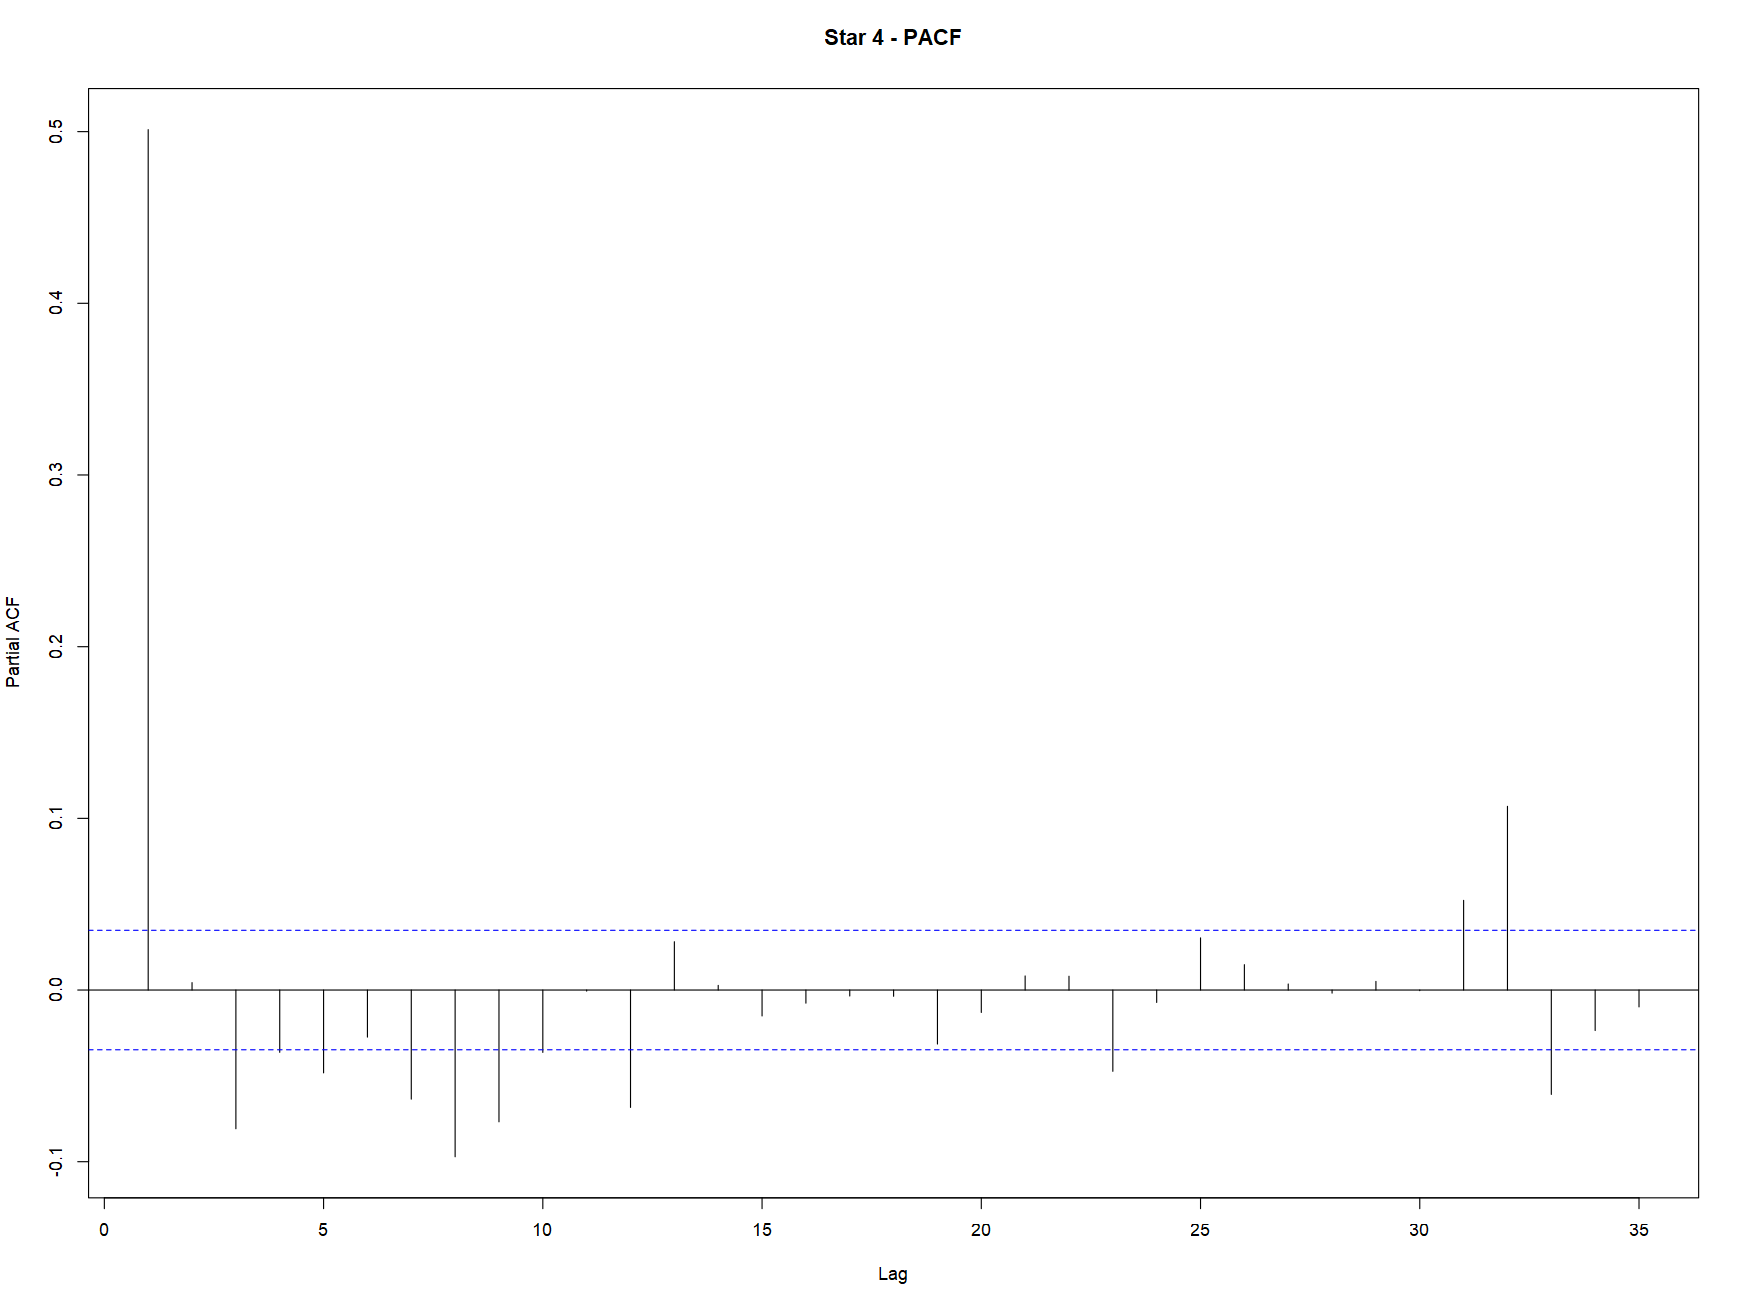

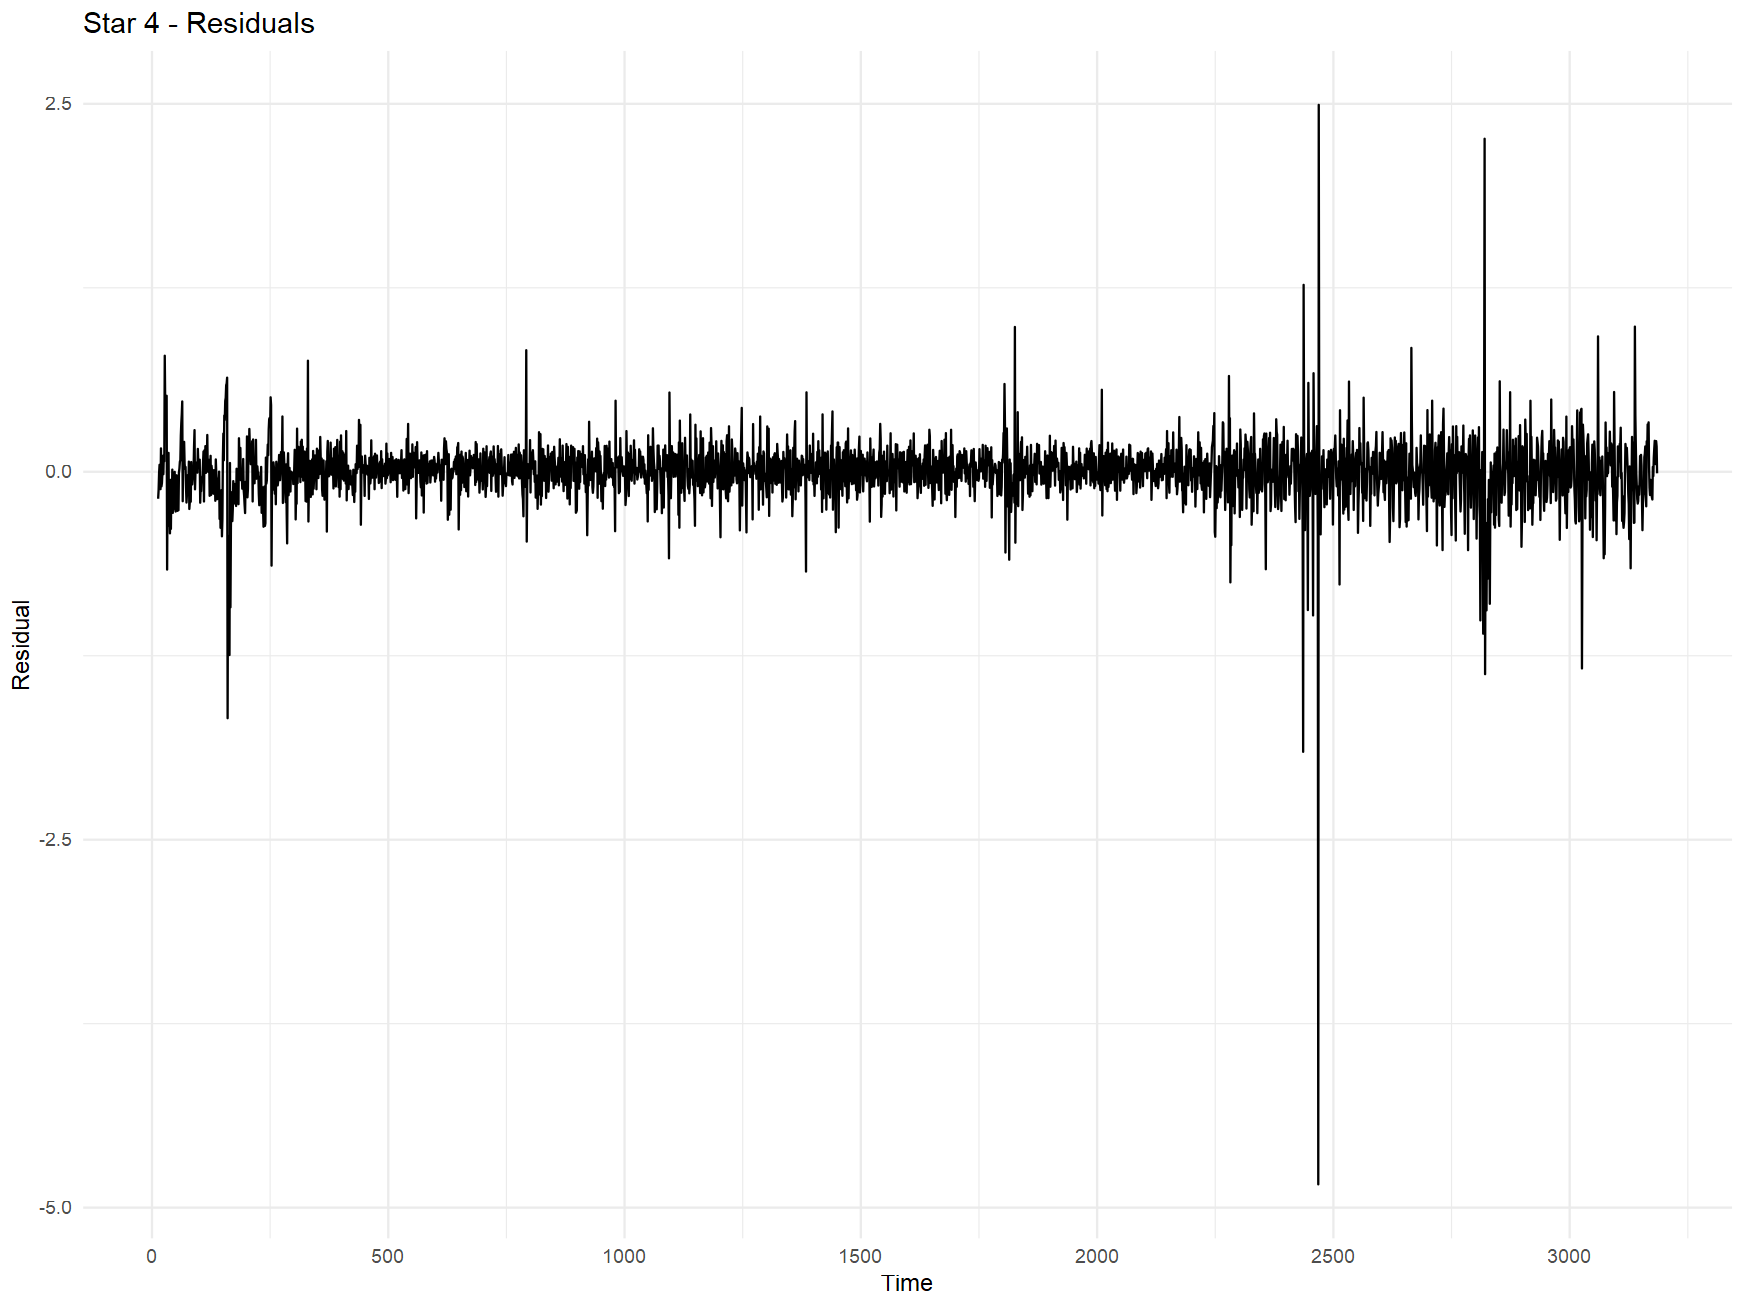

Ljung-Box p-value (lag 20, fitdf=4): 0.0002


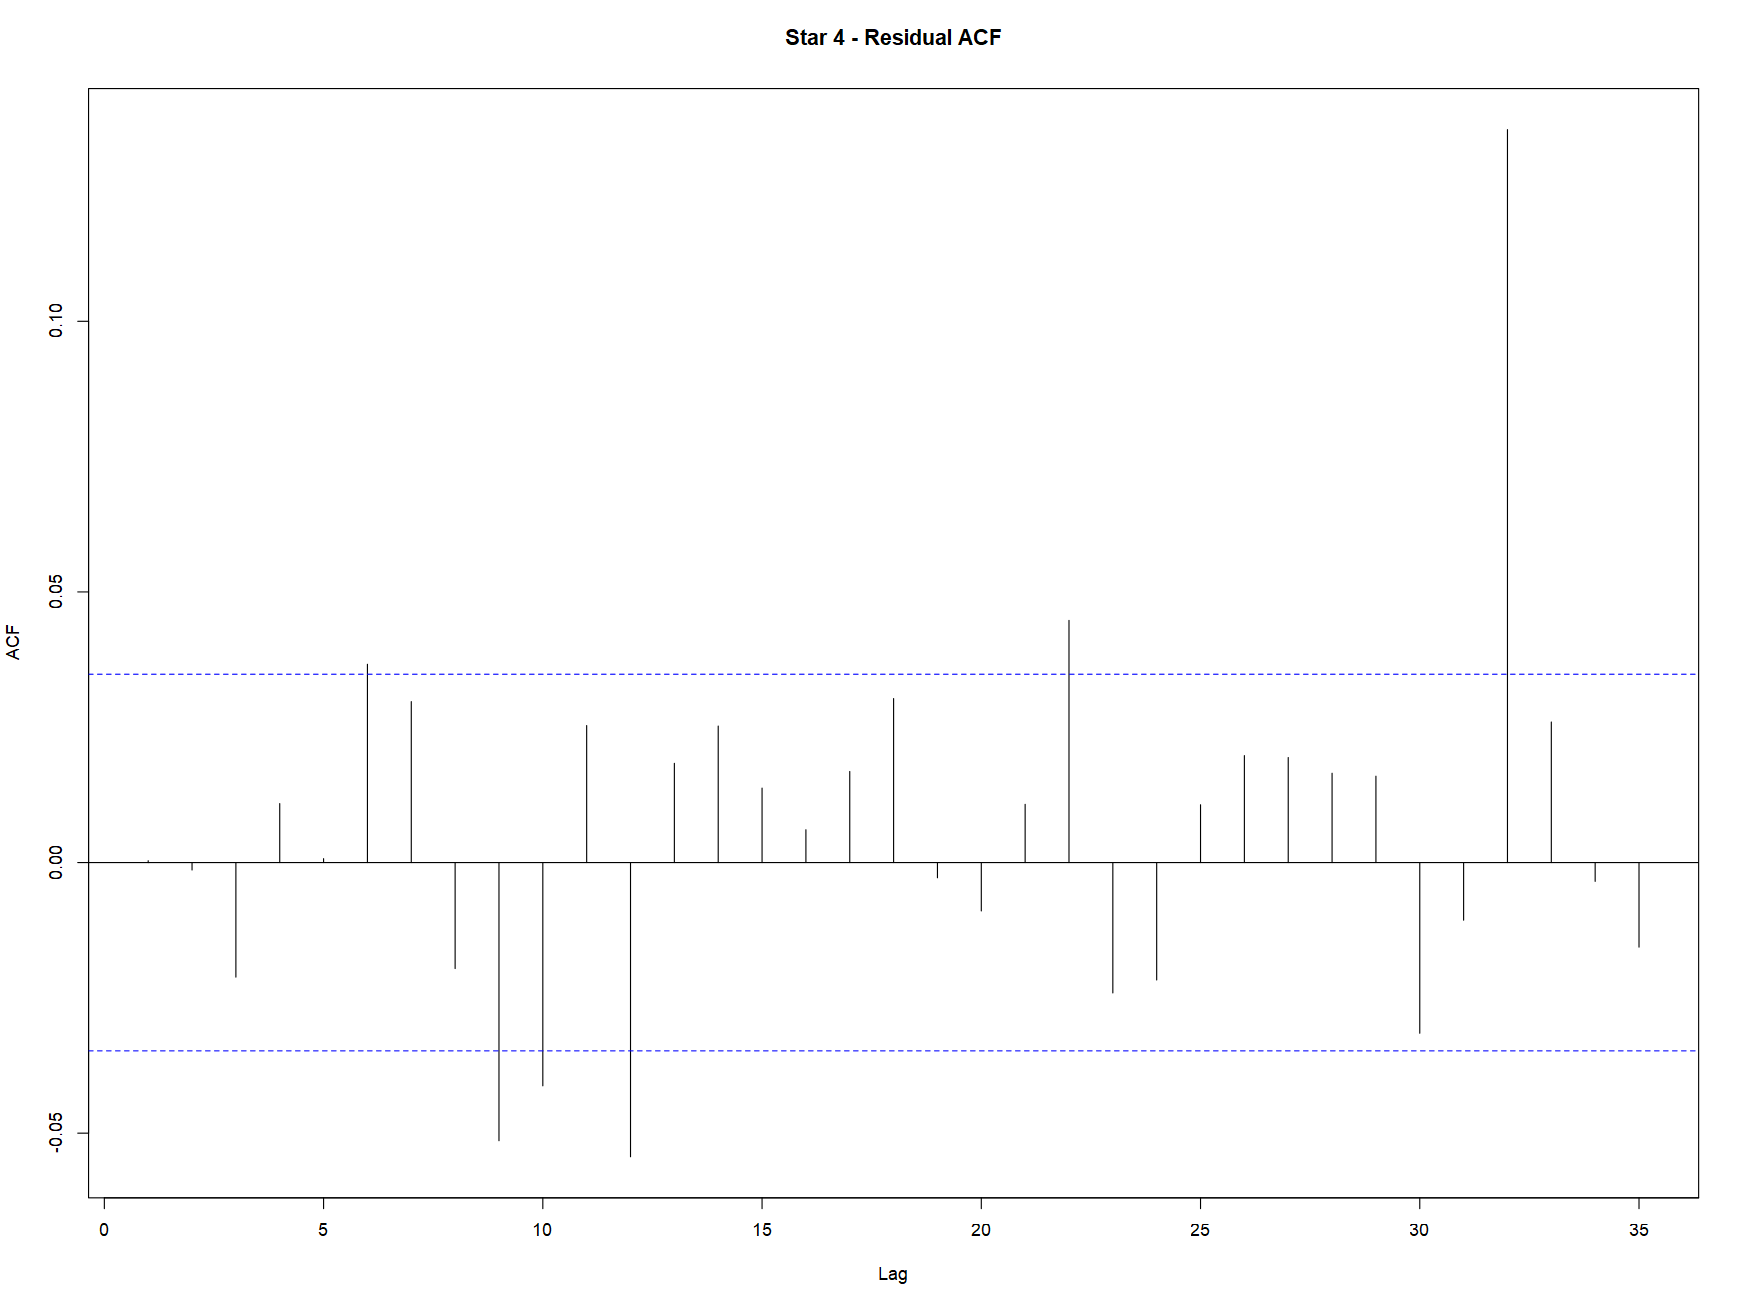

Flagged points: 12 | Events: 1 
Events after edge guard: 0 


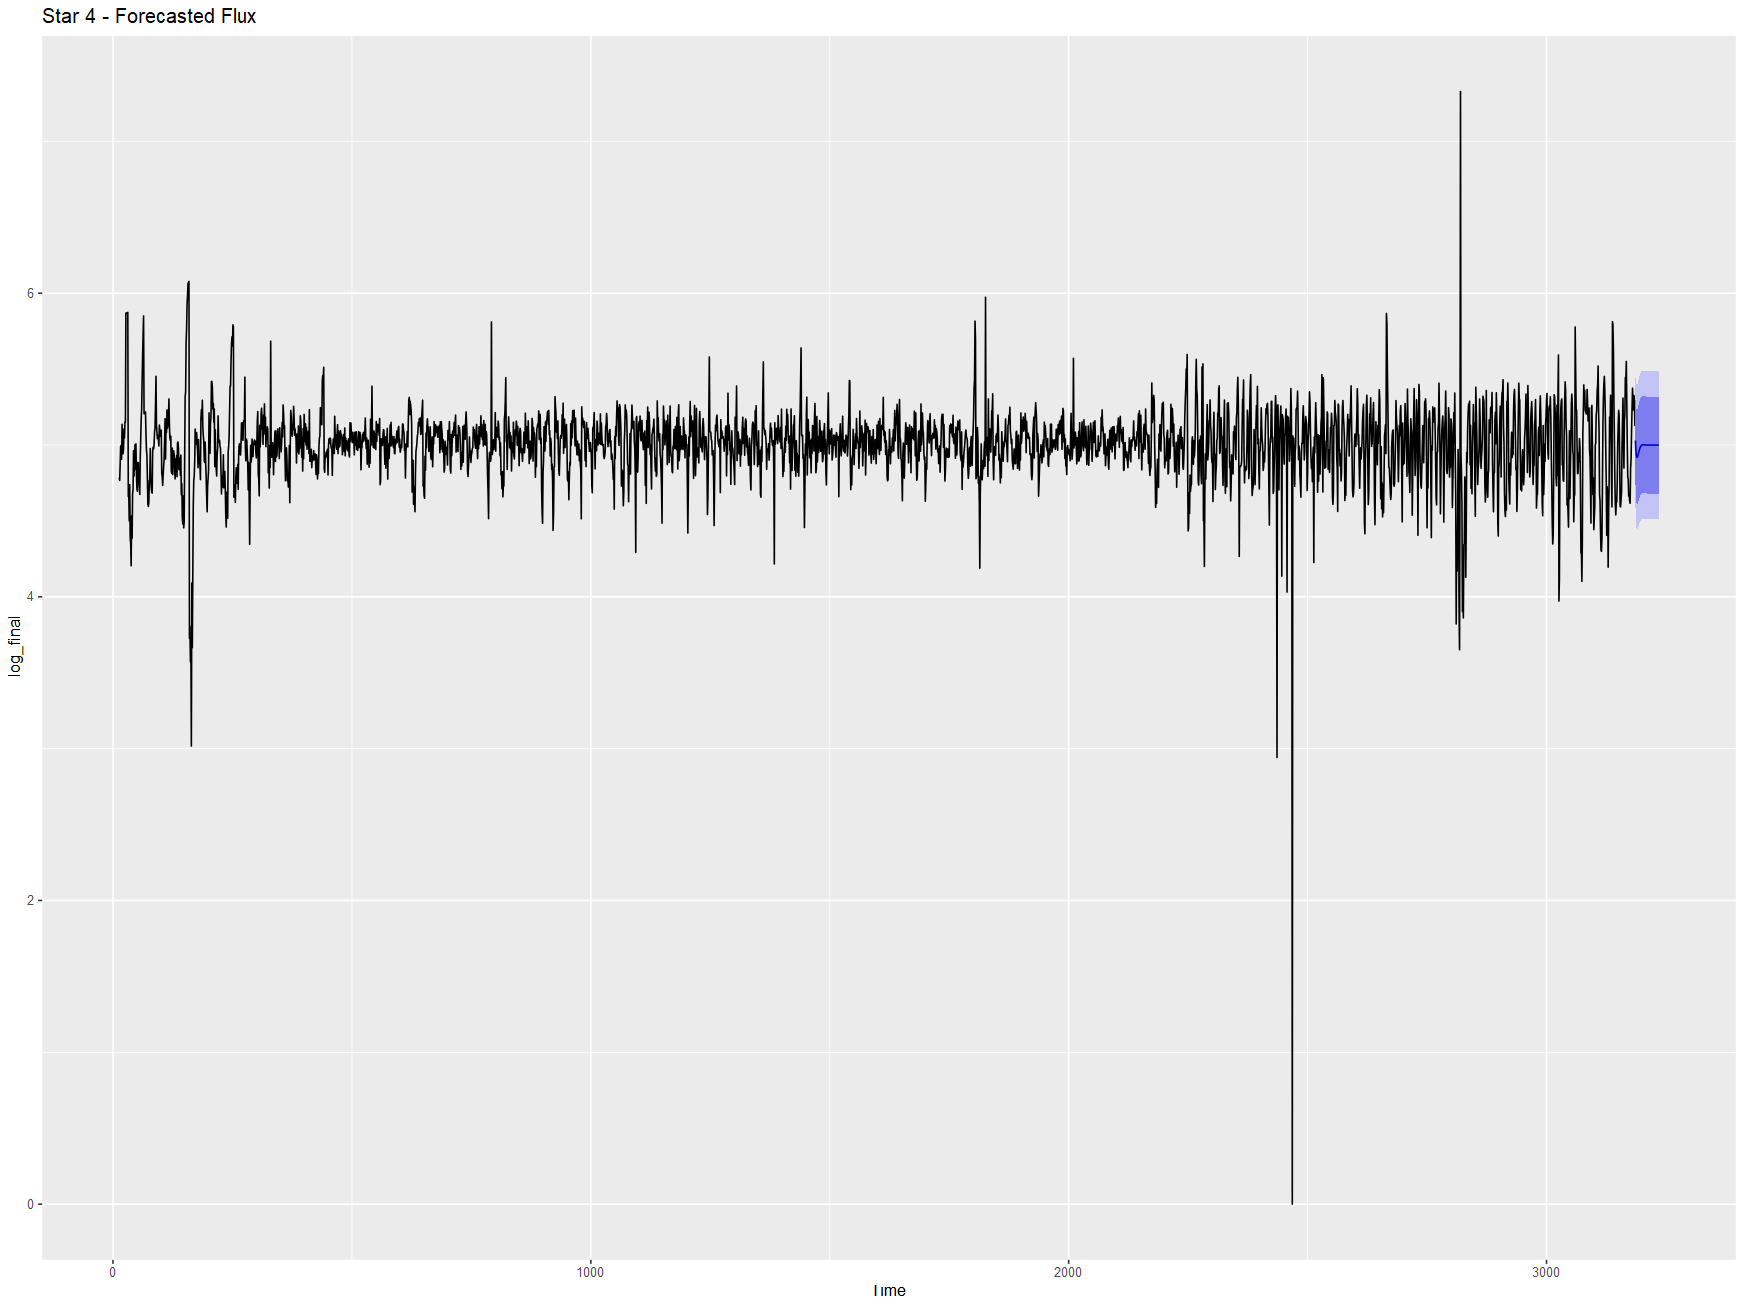

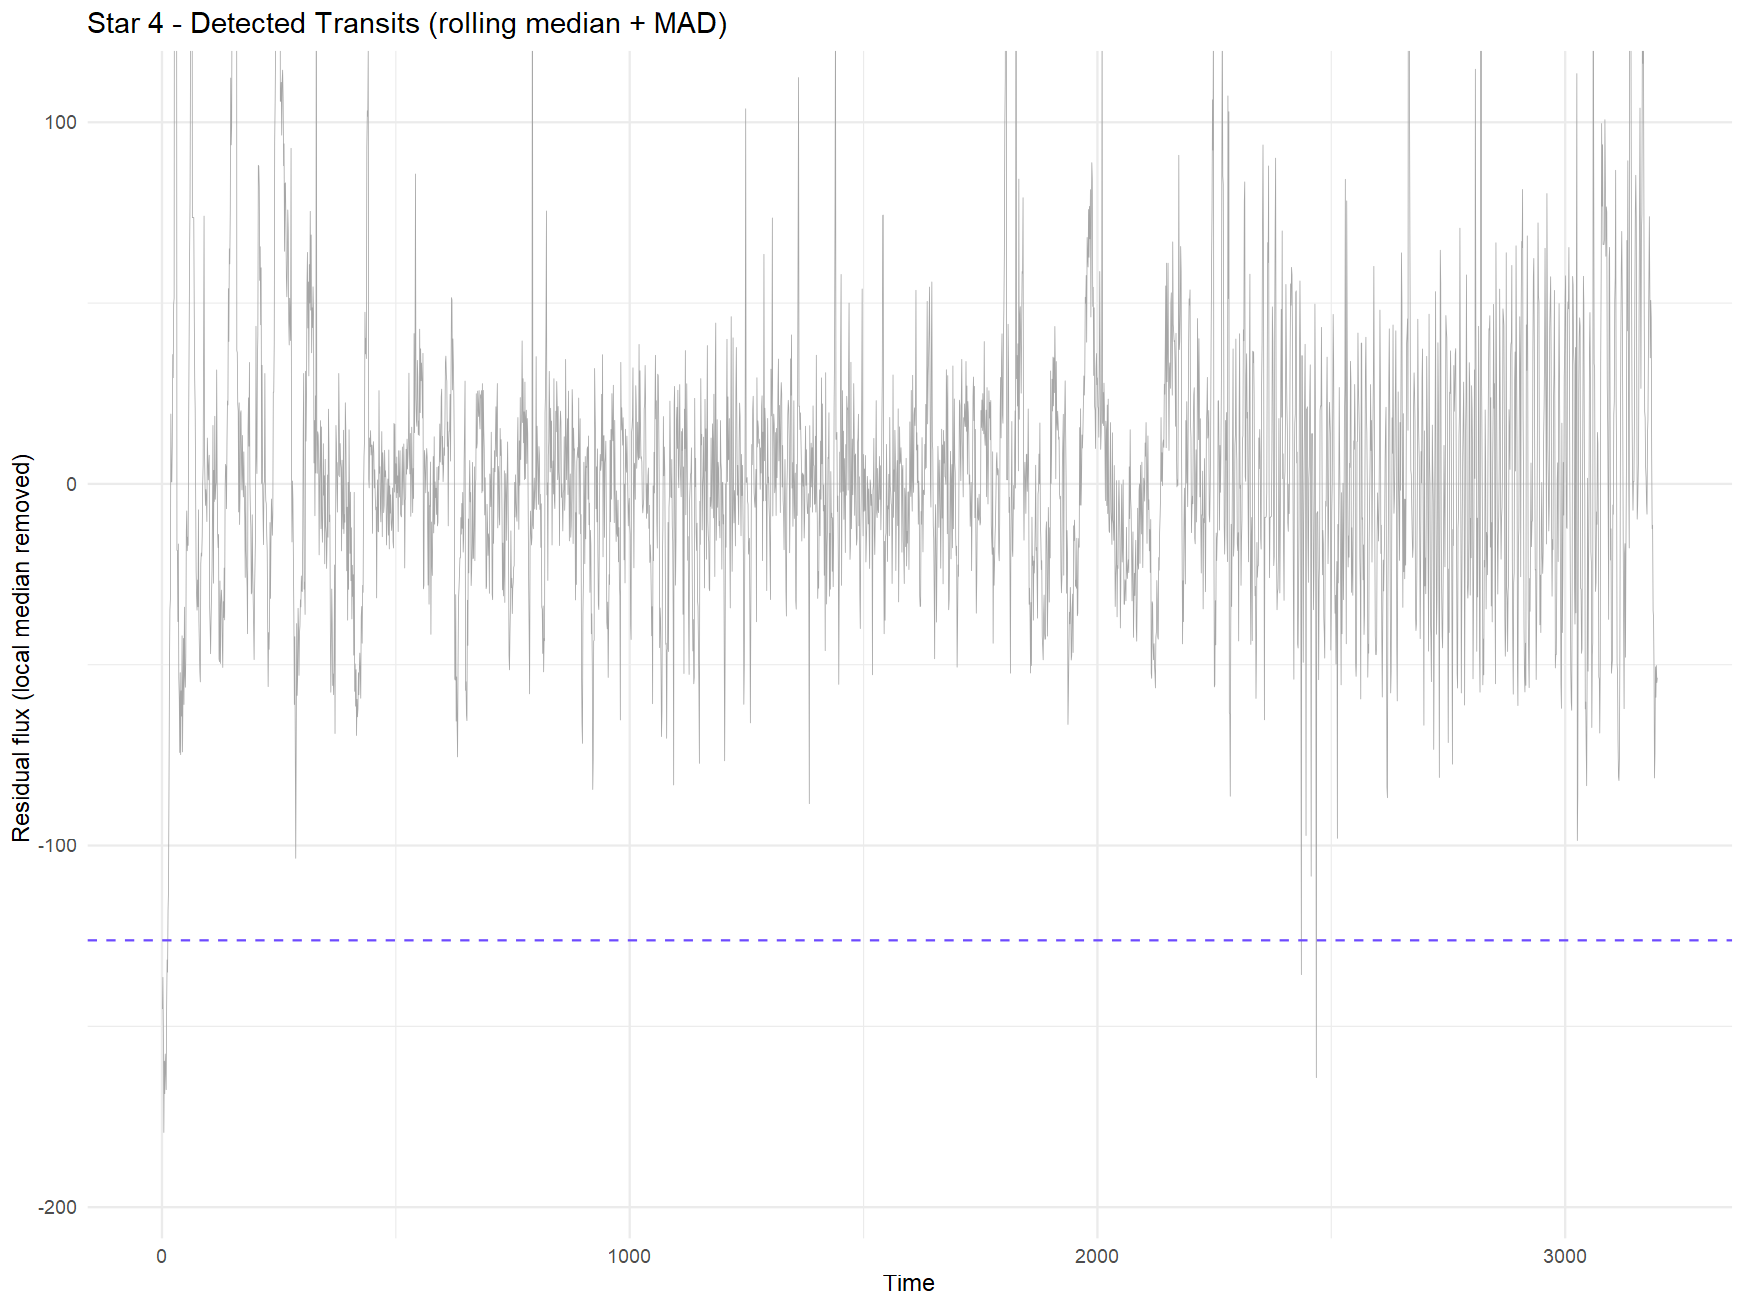


Fourier Analysis of Star 4  ( Row 7 )
Exoplanet Present: No 
AIC values by K: 9078.64 9080.92 9084.84 9087.02 9087.44 9089.37 
Estimated Period: 100  | Chosen Harmonics (K): 1 


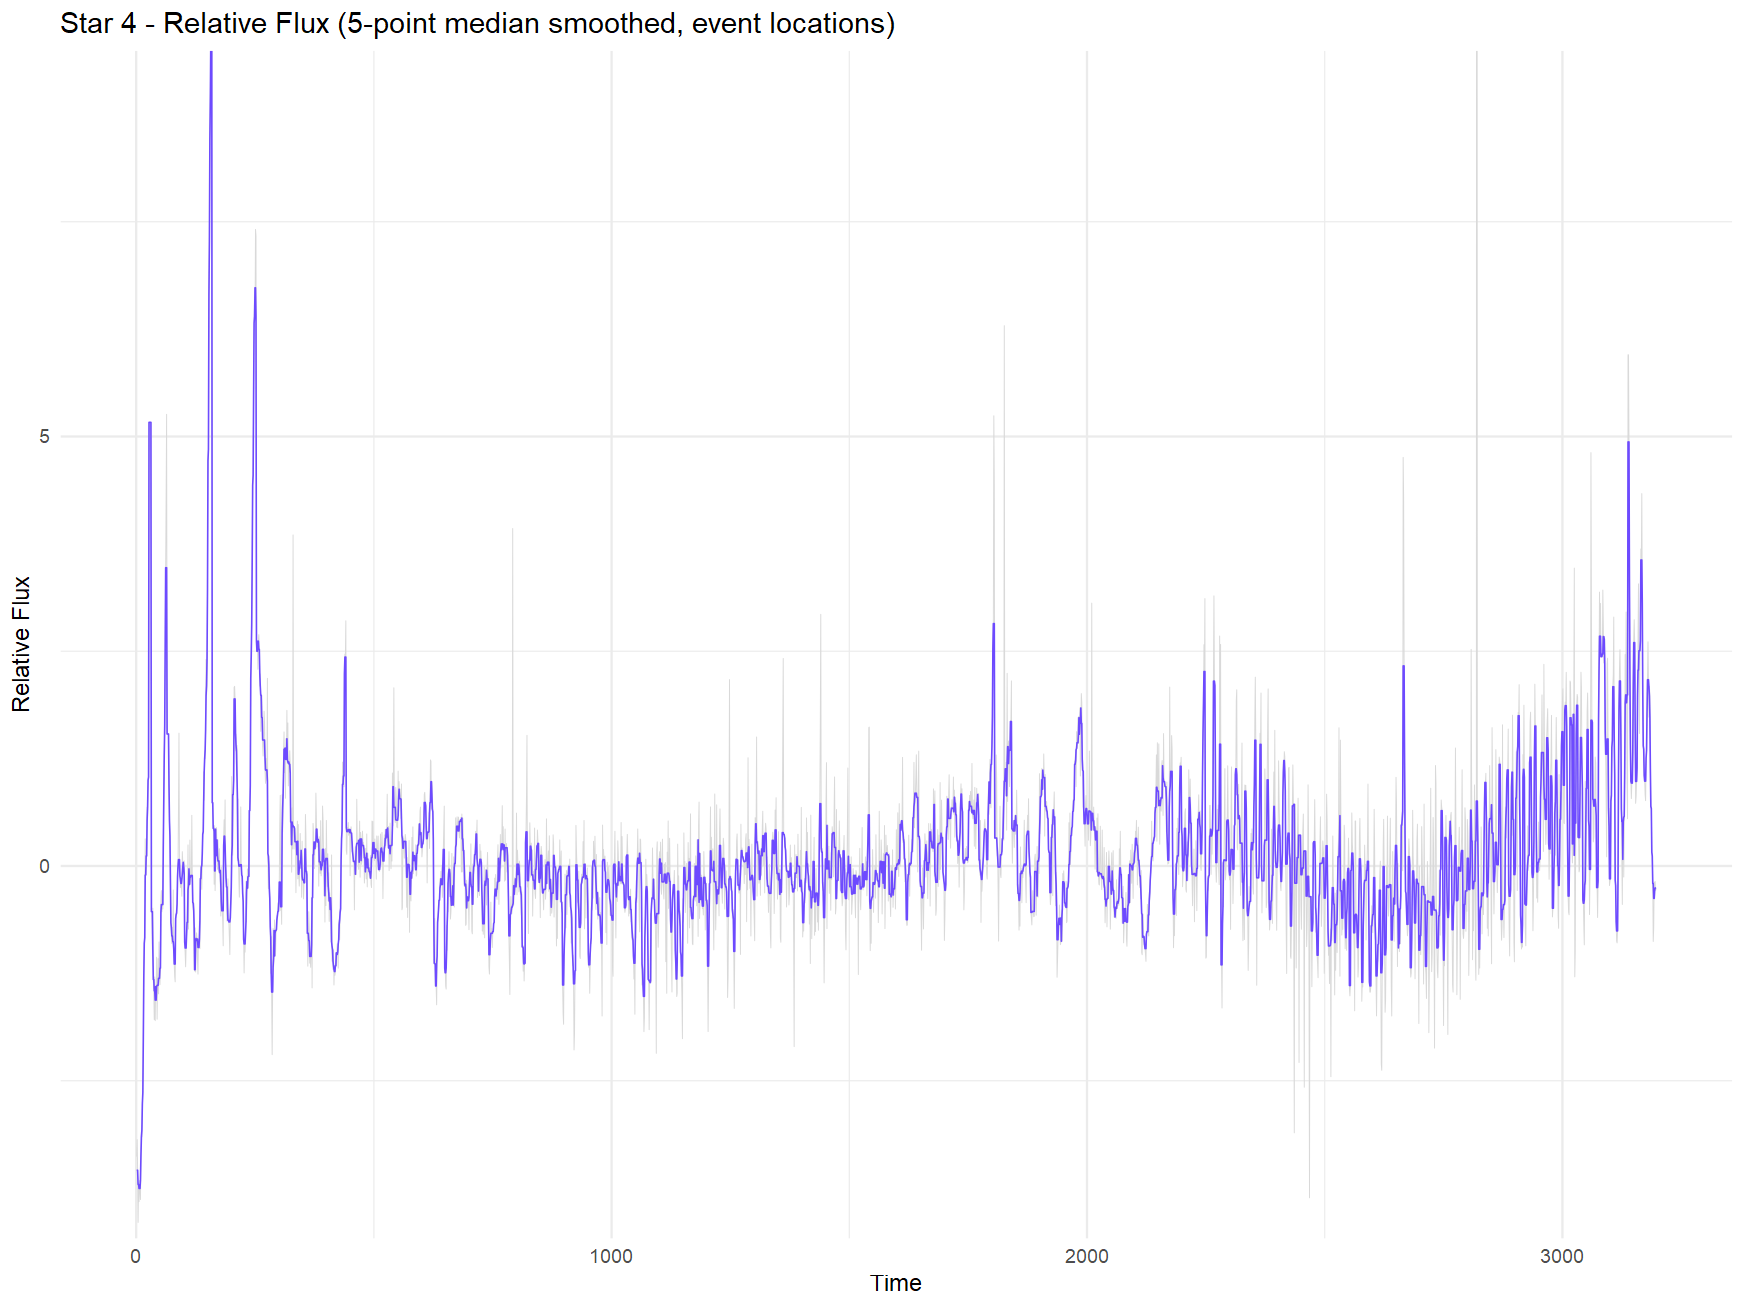

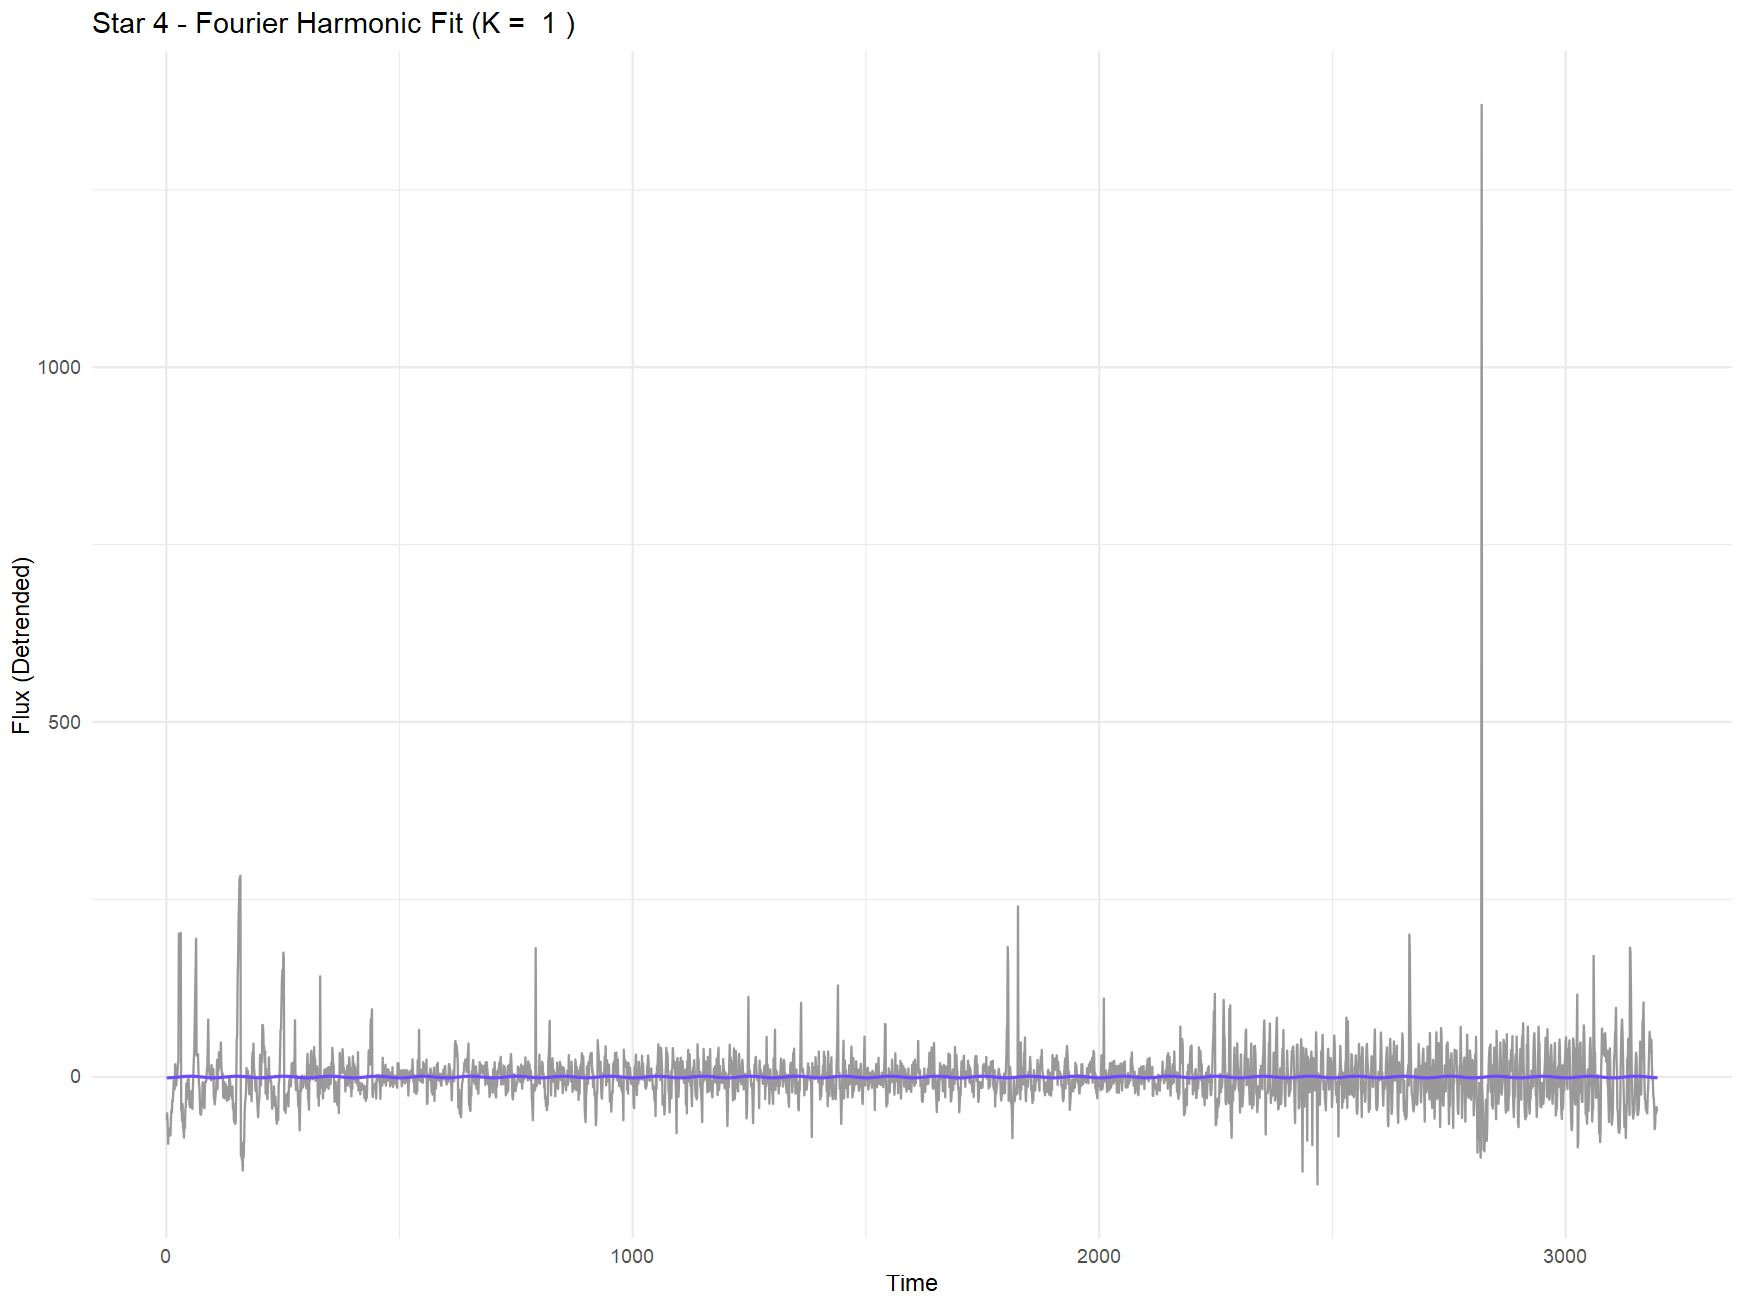

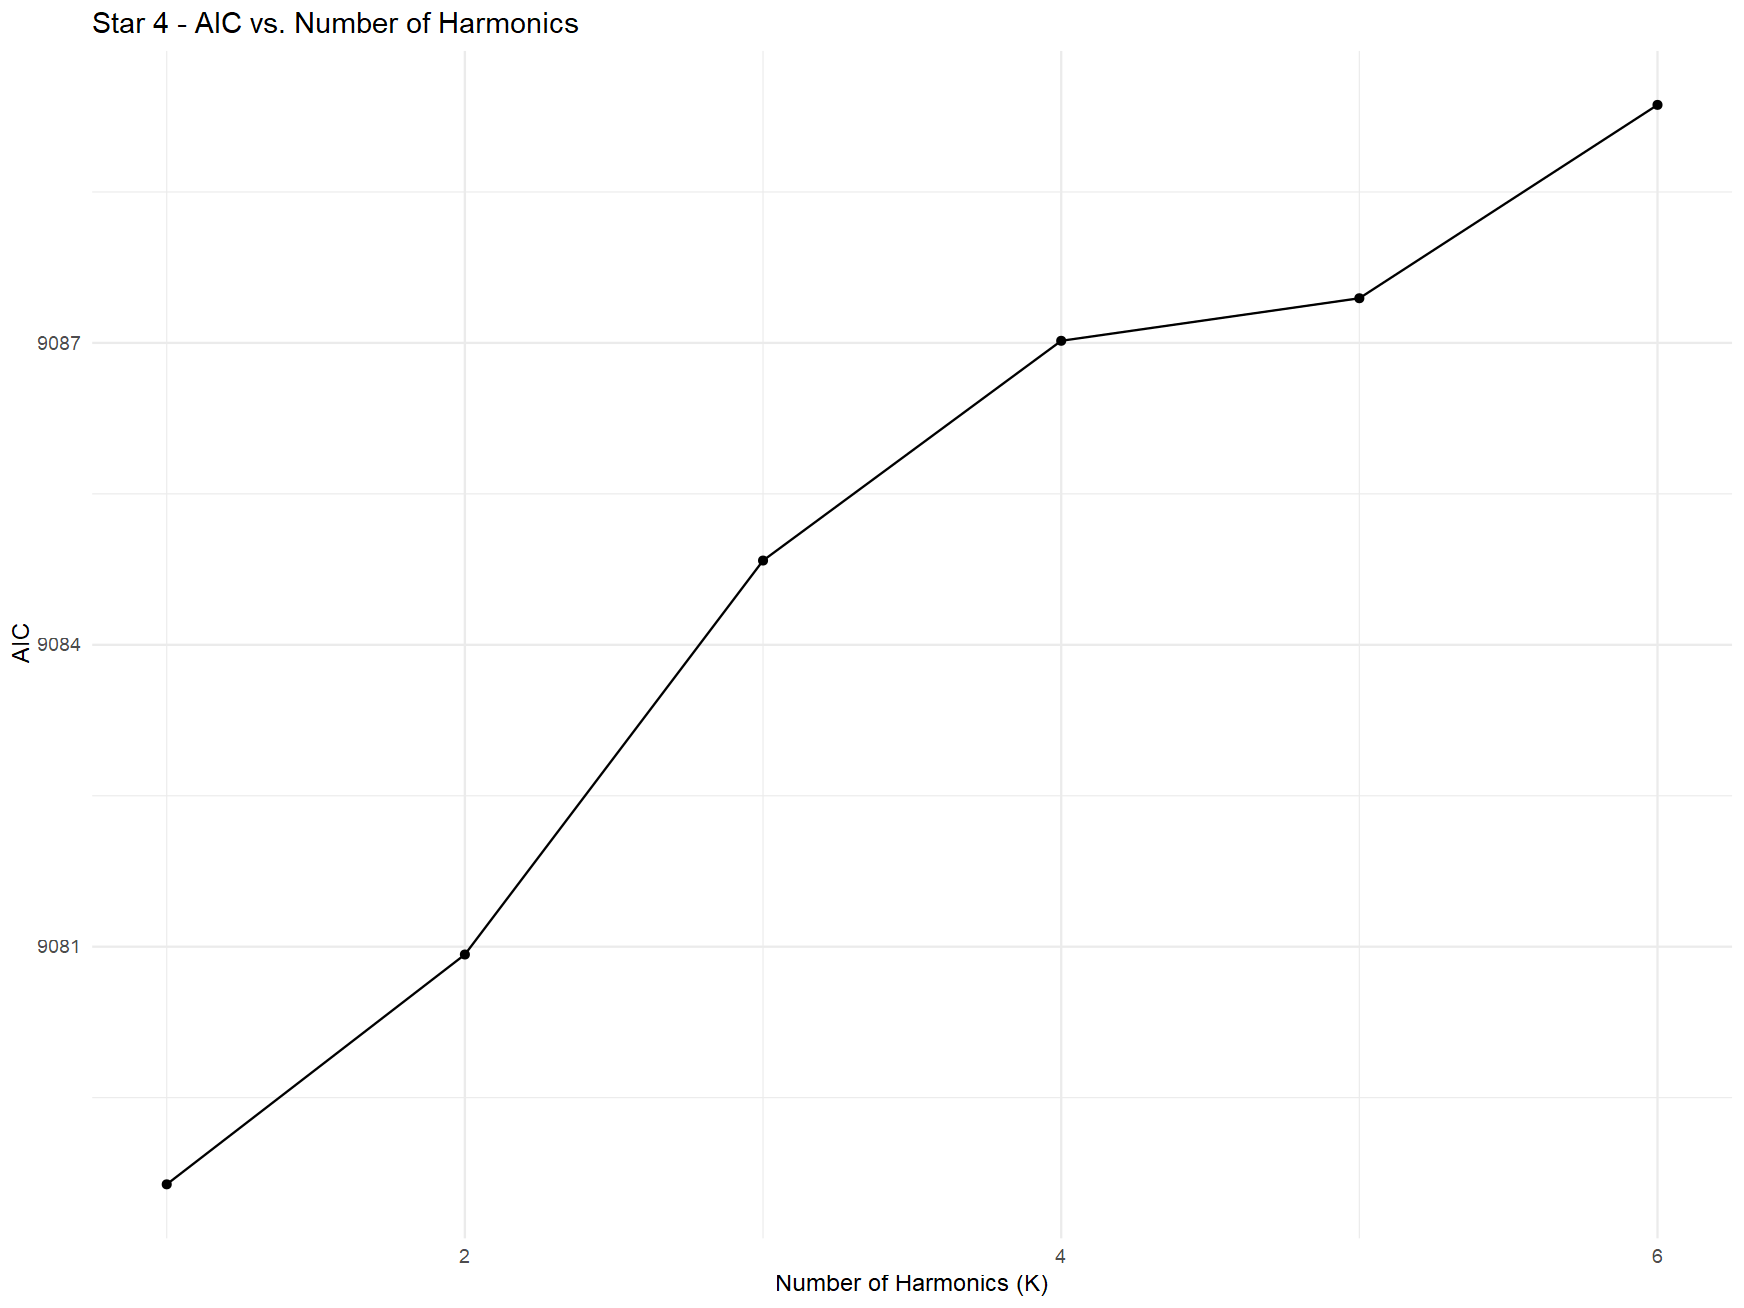

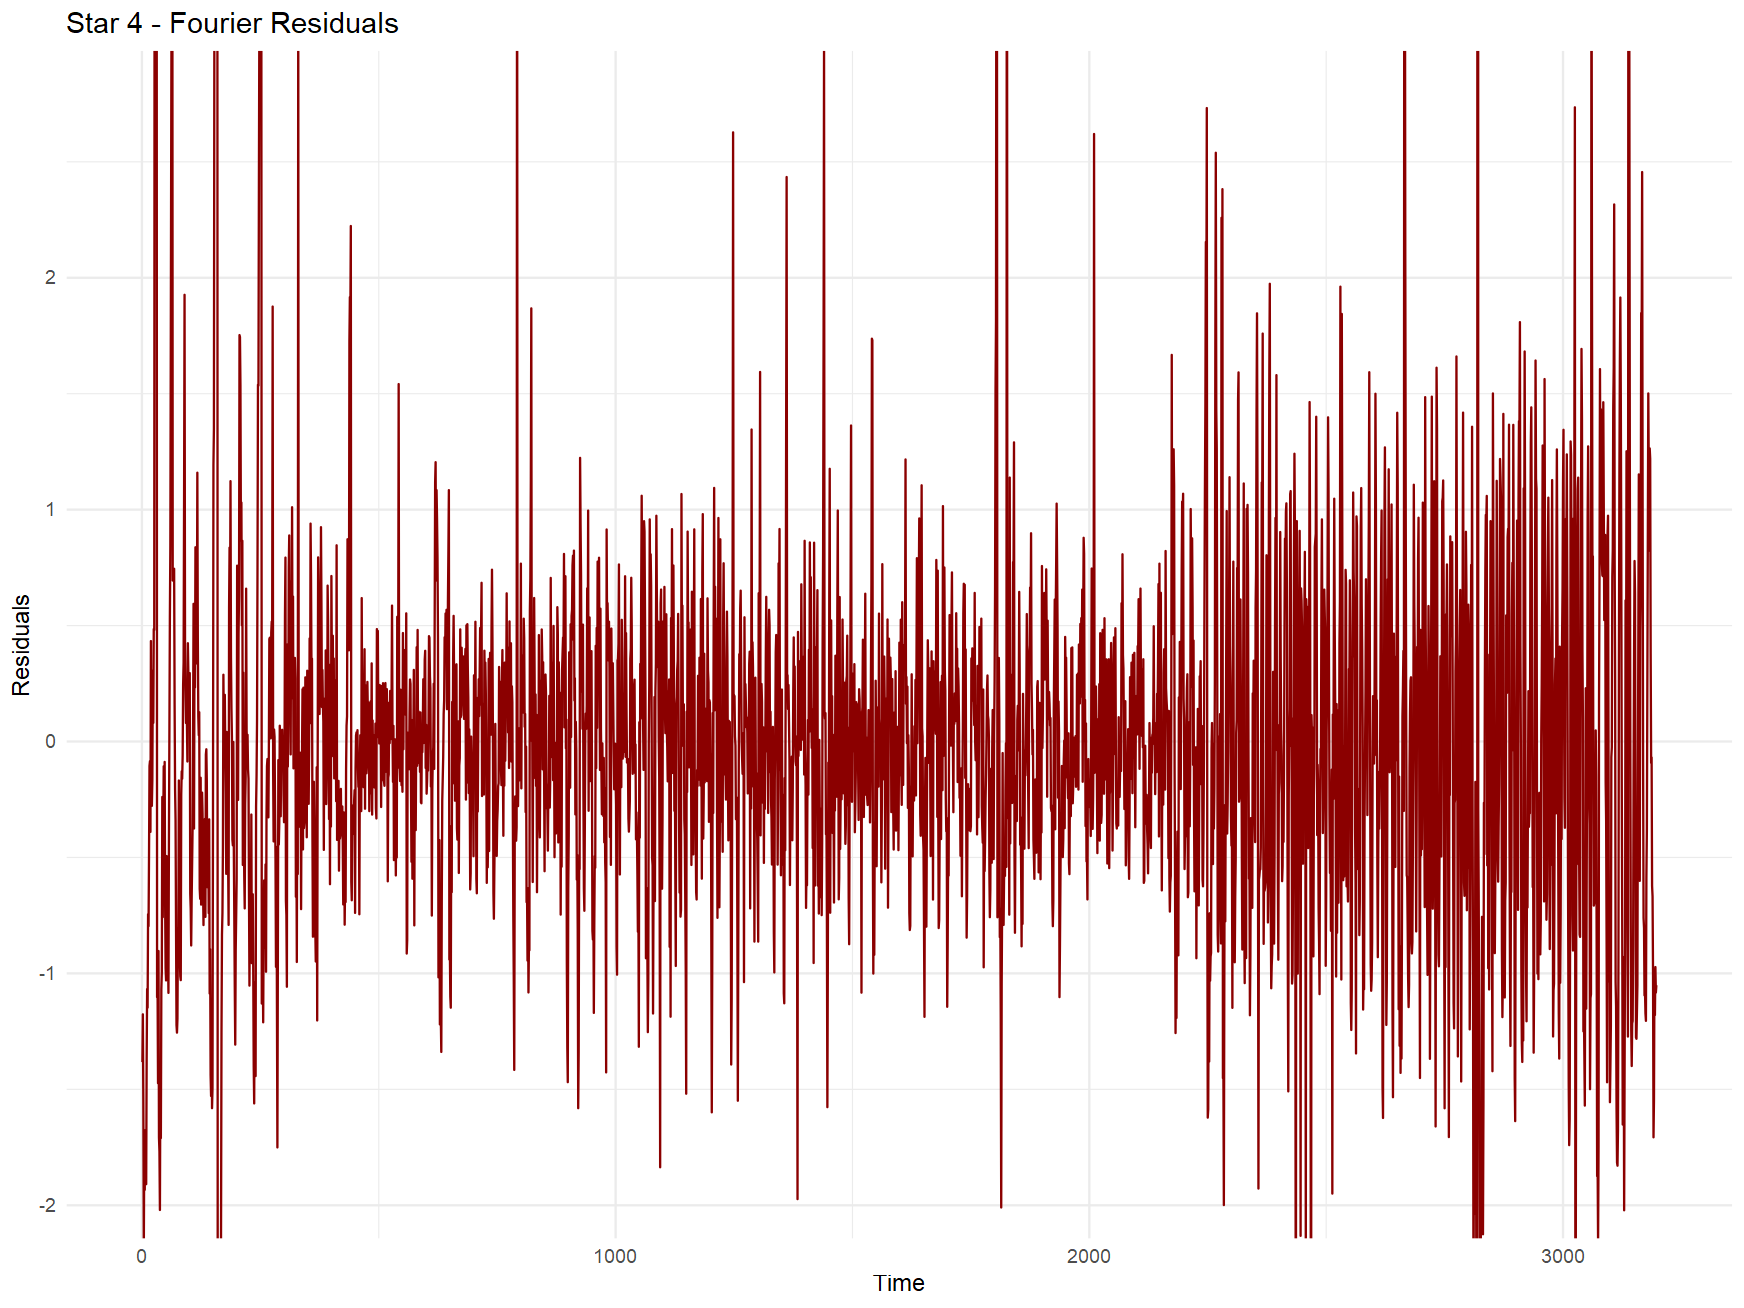

Warning messages:
1: In adfTest(log_ts, type = "ct") : p-value smaller than printed p-value
2: In kpss.test(log_ts, null = "Level") :
  p-value greater than printed p-value


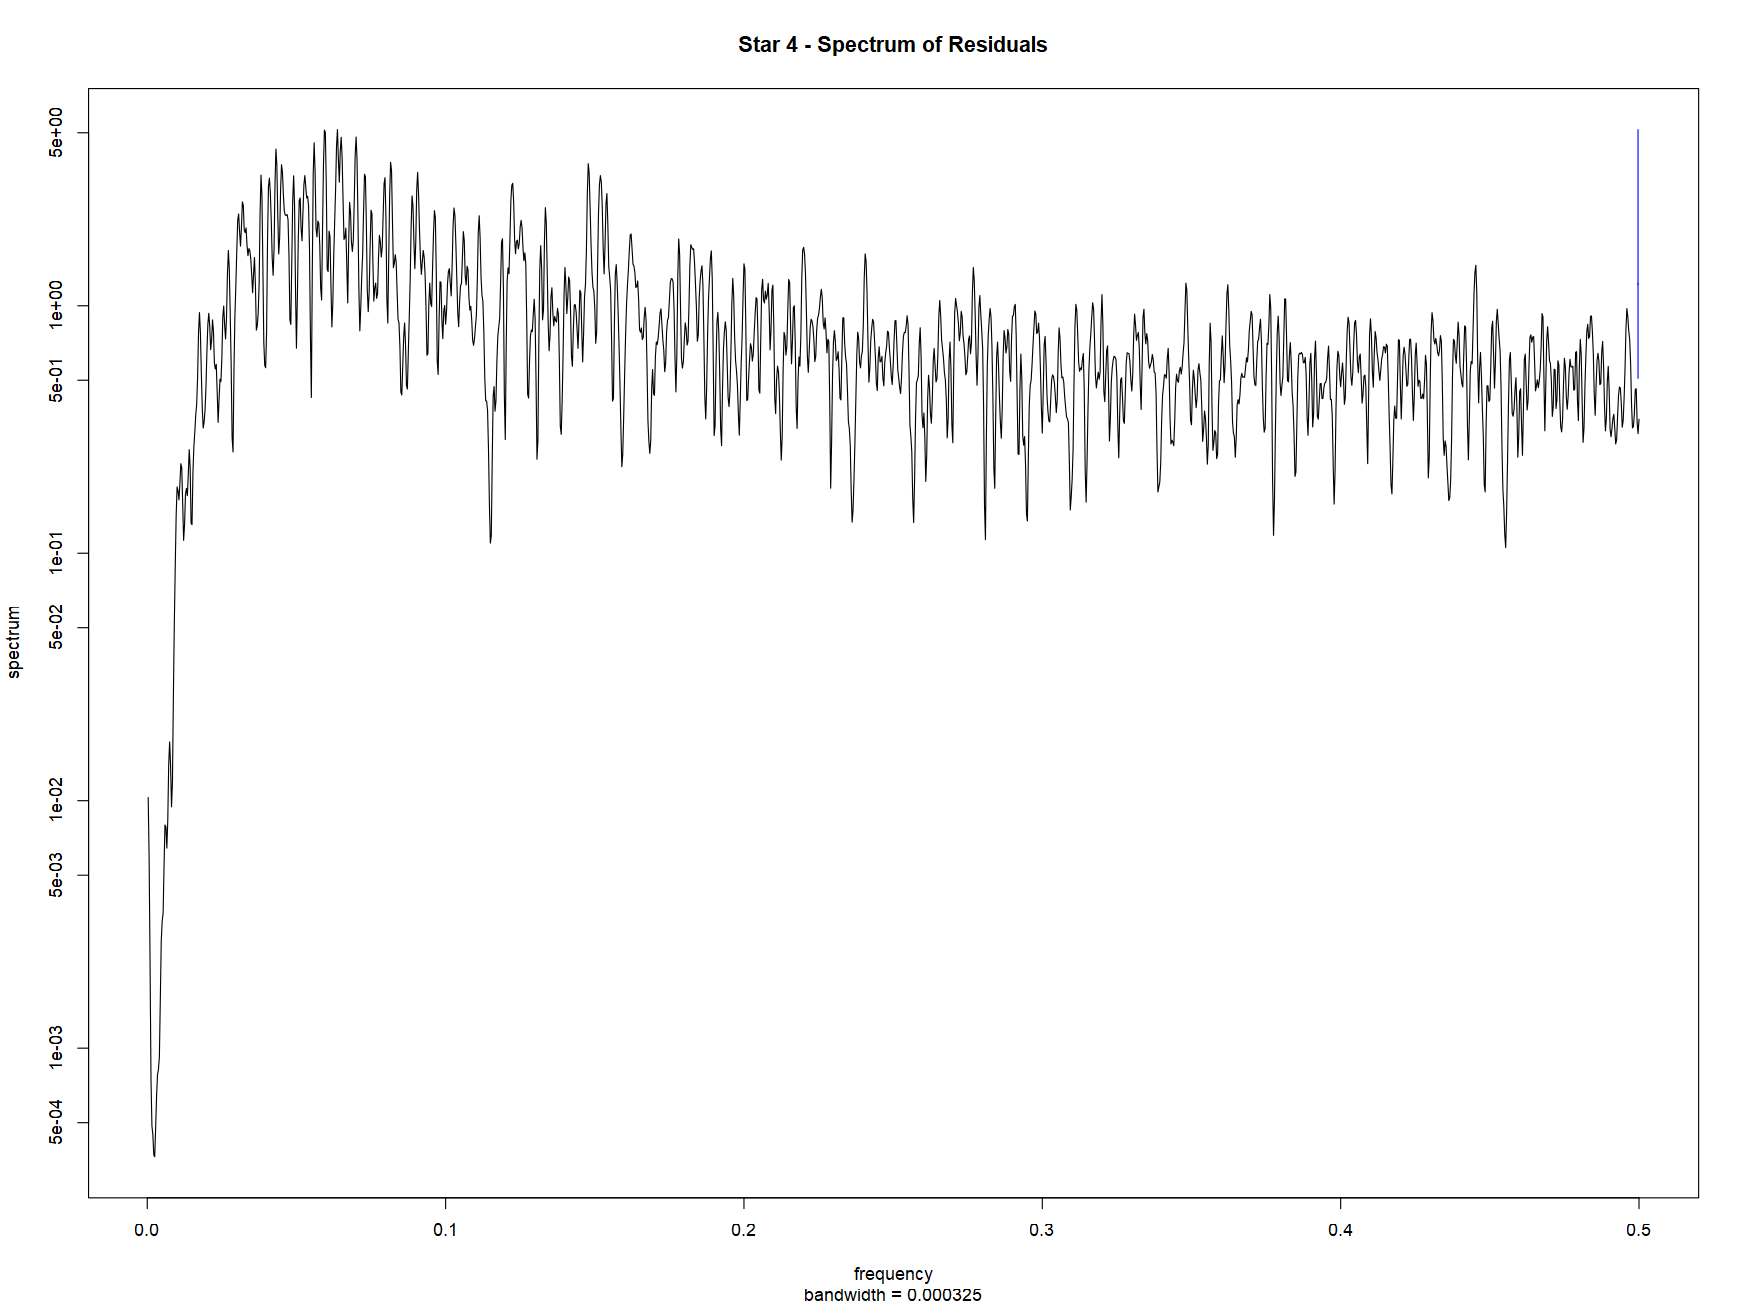

In [12]:
results[[4]] <- list(
  arima = analyze_star_arima(stars[[4]], "Star 4", "No", star_ids[4]),
  fourier = analyze_star_fourier(stars[[4]], "Star 4", star_ids[4], "No")
)

[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **6) Model Comparison Summary**

The table below aggregates the run outputs: robust dip counts from the ARIMA pipeline and estimated periods and selected harmonics from the Fourier pipeline. I report these as observations rather than significant claims with four stars; no formal hypothesis testing was performed.

In [13]:
summary_table <- data.frame(
  Star = paste("Star", 1:4),
  Row = star_ids,
  Exoplanet = c("Yes", "Yes", "No", "No"),
  Dip_Count = sapply(results, function(r) r$arima$dip_count),
  LjungBox_p = sapply(results, function(r) 
                      signif(r$arima$ljung_box_p, 3)),
  Period_Est = sapply(results, function(r) round(r$fourier$period, 1)),
  Harmonics_K = sapply(results, function(r) r$fourier$K)
)
print(summary_table, row.names = FALSE)

   Star Row Exoplanet Dip_Count LjungBox_p Period_Est Harmonics_K
 Star 1   1       Yes         1   2.35e-07      100.0           6
 Star 2   2       Yes         3   0.00e+00      100.0           5
 Star 3   6        No         0   5.05e-01      103.2           1
 Star 4   7        No         0   2.49e-04      100.0           1


#### **Key Takeaways**

- Stars 1 and 2, labeled exoplanet hosts, exhibit more robust flux dips than the non-hosting controls under the median with a 4.5·MAD threshold.<br>

- Fourier terms capture longer periodic oscillations, while ARIMA surfaces stochastic noise structure, as the pipelines are complementary rather than competing.<br>

- I treat the contrast in dip counts as suggestive, not confirmatory; the sample is four stars, and no significance testing is applied.<br>

[**⬆ Back to Table of Contents**](#table-of-contents)

<br>

---

### **7) Conclusion**

This project applied classical time series methods to exoplanet transit detection on Kepler light curves. I compared a matched set of stars with and without confirmed planets using two pipelines: ARIMA modeling of detrended, log-transformed flux with formal stationarity testing and Ljung-Box-corrected residual diagnostics, and Fourier harmonic regression with spectrally estimated periods and AIC-driven harmonic selection.

**Findings:** The exoplanet-hosting stars showed greater numbers of robust flux dips consistent with potential transits, using a dip threshold designed to resist contamination from the transits themselves. Estimated periods from spectral analysis aligned with plausible orbital timescales for the hosting stars, while control stars displayed fewer and weaker periodic signatures.

**Limitations:** The case-control design covers only four hand-selected stars, dip counts were not tested for statistical significance, and the 25-point detrending window trades noise suppression against potential attenuation of short transits. These limitations motivate the future work below.

#### **Future Work:**

- Scale to all labeled stars and build automated feature extraction (dip depth, duration, spacing) for supervised classification — turning this exploratory analysis into a predictive one.<br>

- Implement Box Least Squares (BLS) for phase-folded transit detection, which phase-folding with harmonic regression is not designed to match.<br>

- Cross-reference detected events against the NASA Exoplanet Archive for independent validation.

<br>

[**⬆ Back to Table of Contents**](#table-of-contents)